In [1]:
import os
import tarfile
import numpy as np
# import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import corner 
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


#Another option for plotting
# pip install scienceplots
import scienceplots 
plt.style.use('science')


# #Some colors that Pablo likes:
colors = [
    "#1f77b4", # Vivid blue
    "#ff7f0e", # Bright orange
    "#2ca02c", # Rich green
    "#d62728", # Strong red
    "#9467bd", # Deep purple
    "#8c564b", # Brownish-pink
    "#e377c2", # Pink
    "#7f7f7f", # Medium gray
    "#bcbd22", # Lime green
    "#17becf", # Cyan
    "#393b79", # Dark blue
    "#637939", # Olive green
    "#8c6d31", # Bronze
    "#843c39", # Dark red
    "#ad494a", # Reddish brown
    "#d6616b", # Soft red
    "#e7ba52", # Golden yellow
    "#7b4173", # Dark purple
    "#a55194", # Mauve
    "#ce6dbd", # Light purple
]

colors_sets = [
    "#ff7f0e",

    "#1f77b4",

    "#2ca02c",
    "#d62728",
    
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
    '#1f77b4',  # muted blue
    'r',  
] 

markers = [
    "o",  # Circle
    "^",  # Triangle up
    "s",  # Square
    "P",  # Plus (filled)
    "*",  # Star
    "X",  # X (filled)
    "D",  # Diamond
    "H",  # Hexagon
]


colors_models = colors


Selected_element=50
Selected_element_name="Sn"

color_train=colors_sets[9]
color_validation='orange'
color_test=colors_sets[3]

marker_train='s'
marker_validation='*'
marker_test='o'



size_train=30
size_validation=80
size_test=35

alpha_train=0.8
alpha_validation=0.9
alpha_test=0.4

models = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
new_models = [
    "collect.SV-min",
    "collect.SV-min-HFBcut5",
    "collect.UNEDF1-BCScut5-rho16",
    "collect.UNEDF1.HFB-rho16",
    "collect.Fystd",
    "collect.FyDr",
    "collect.FyDrHFB",
    "collect.FyIVP-stab05",
]
key_list = models_selected

heterogeneous_data_type = ['BE', 'ChRad', 'CPn', 'CPp', 'PEn', 'PEp', 'QDB2n', 'QDB2p', 'QDB4n', 'QDB4p', 'MRadN', 'MRadP']
num_properties = 2

In [2]:
a = pd.read_csv('data/charge_radii.csv')
a.rename(columns = {'z' : 'Z', 'n' : 'N'}, inplace = True)

In [3]:
with tarfile.open('data/radii-systematic.tgz', 'r:gz') as tar:
    tar.extractall(path=r"C:\Users\congn\OneDrive\Desktop\An Le Materials\ModelOrthogonalization\data")

In [4]:
# This extracts the csv of data models into a dataframe in python
FyIVP_stab05 = pd.read_csv(r"data\collect.FyIVP-stab05", sep = r'\s+', header=None)

# #This shifts the name of the column to make it match with their correspondings values
FyIVP_stab05.iloc[0, :-1] = FyIVP_stab05.iloc[0, 1:] 
# Delete the last column as it only contains NaN value
FyIVP_stab05 = FyIVP_stab05.iloc[:, :-1]
# Make the column name to be the first row (the is the Z, N, ...)
FyIVP_stab05.columns = FyIVP_stab05.iloc[0]
#Drop the first row as it is no to us anymore
FyIVP_stab05 = FyIVP_stab05.drop(0)
Data_cols = ['N', 'Z', 'E_B', 'r_C']
for col in Data_cols:
    FyIVP_stab05[col] = [float(num) for num in FyIVP_stab05[col].values]
#This step swaps the values in the 2 columns: 'N' and 'Z'
FyIVP_stab05[['N', 'Z']] =   FyIVP_stab05[['Z', 'N']]
#This steps extract the columns of the dataframe:
FyIVP_stab05_cols = list(FyIVP_stab05.columns)
FyIVP_stab05_cols[0], FyIVP_stab05_cols[1] = FyIVP_stab05_cols[1], FyIVP_stab05_cols[0]
FyIVP_stab05.columns = FyIVP_stab05_cols
FyIVP_stab05

,N,Z,r_C,E_B,"Epair,p",Epair_n,gap_p,gap_n,eferm_p,eferm_n
1,14.0,20.0,3.468429,-247.005,-20.703,-2.696,4.044,1.272,1.401,-19.296
2,16.0,20.0,3.450426,-283.245,-15.095,-1.004,3.319,0.721,-0.793,-16.356
3,18.0,20.0,3.479286,-313.813,-13.809,-2.659,3.099,1.159,-3.064,-14.403
4,20.0,20.0,3.479898,-341.863,-8.663,-0.137,2.334,0.286,-5.397,-12.475
5,22.0,20.0,3.508688,-362.986,-8.596,-6.132,2.295,1.773,-7.283,-9.827
...,...,...,...,...,...,...,...,...,...,...
151,212.0,82.0,6.151760,-1800.770,-13.638-118.638,1.243,3.509,-20.128,1.310,NaN
152,214.0,82.0,6.166172,-1798.860,-13.956-120.629,1.254,3.521,-20.379,1.376,NaN
153,216.0,82.0,6.180233,-1796.790,-14.207-122.199,1.261,3.526,-20.631,1.440,NaN
154,218.0,82.0,6.193951,-1794.590,-14.400-123.434,1.266,3.526,-20.882,1.502,NaN


In [5]:
models_data_sets = {}
for model in new_models[:-1]:
    file_path = rf'data\{model}'
    #This helps you to get rid of the first row
    Data_Values = pd.read_csv(file_path, skiprows=1, sep = r'\s+', header=None)
    # This rearrage your column name so that they match with their corresponding value
    Data_Values.iloc[0, :-1] = Data_Values.iloc[0, 1:] 
    # This helps you to get rid of the last column in which in only contains NaN value
    Data_Values = Data_Values.iloc[:, :-1]
    #This takes all the column to be renamed by the first row that you have
    Data_Values.columns = Data_Values.iloc[0]
    # This drops that row so you will get a full dataframe
    Data_Values = Data_Values.drop(0)
    
    #Only drop rows that has NaN value in charge radii and binding energy 
    Data_Values.dropna(subset = ['r_C', 'E_B'])
    
    #Columns that you are intersted in:
    Data_cols = ['N', 'Z', 'E_B', 'r_C']
    for col in Data_cols:
        Data_Values[col] = [float(num) for num in Data_Values[col].values]
    
    Data_Values[['N', 'Z']] =   Data_Values[['Z', 'N']]
    #This steps extract the columns of the dataframe:
    Data_Values_cols = list(Data_Values.columns)
    #This step rearranges the name of the column so that we can later switch the name of the column
    Data_Values_cols[0], Data_Values_cols[1] = Data_Values_cols[1], Data_Values_cols[0]
    
    Data_Values.columns = Data_Values_cols

    print(Data_Values.isna().any())
    
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : -Data_Values["E_B"], 'ChRad': Data_Values['r_C']}

models_data_sets["collect.FyIVP-stab05"] = {"N" : FyIVP_stab05["N"], "Z" : FyIVP_stab05["Z"], "BE" : -FyIVP_stab05["E_B"], 'ChRad': FyIVP_stab05['r_C']}


# This cell helps you to extract a dictionary that contains all the nuclei with BE and radius predictions of all the models we have
# models_data_sets = {}
for model in models:
    Data_Values = pd.read_hdf("./data./selected_data.h5", key = model)
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : Data_Values["BE"], 'ChRad': Data_Values['ChRad']}


filtered_NZ = np.array([models_data_sets[models_selected[0]]['N'].tolist(), models_data_sets[models_selected[0]]['Z'].tolist() ]).T
filtered_NZ

N          False
Z          False
r_C        False
E_B        False
Epair,p    False
Epair_n    False
gap_p      False
gap_n      False
eferm_p    False
eferm_n    False
dtype: bool
N          False
Z          False
r_C        False
E_B        False
Epair,p    False
Epair_n    False
gap_p      False
gap_n      False
eferm_p    False
eferm_n    False
dtype: bool
N          False
Z          False
r_C        False
E_B        False
Epair,p    False
Epair_n    False
gap_p      False
gap_n      False
eferm_p    False
eferm_n    False
dtype: bool
N          False
Z          False
r_C        False
E_B        False
Epair,p    False
Epair_n    False
gap_p      False
gap_n      False
eferm_p    False
eferm_n    False
dtype: bool
N          False
Z          False
r_C        False
E_B        False
Epair,p    False
Epair_n    False
gap_p      False
gap_n      False
eferm_p    False
eferm_n    False
dtype: bool
N          False
Z          False
r_C        False
E_B        False
Epair,p    False
Epair

array([[  2,   2],
       [  4,   2],
       [  6,   2],
       ...,
       [156, 108],
       [158, 108],
       [160, 110]])

In [6]:
df = pd.DataFrame(models_data_sets["ME2"])
df = df[df["N"] ==16]
df = df[df["Z"] == 20]
df

,N,Z,BE,ChRad
65,16,20,279.897,3.462


In [7]:
models_data_sets.keys()

dict_keys(['collect.SV-min', 'collect.SV-min-HFBcut5', 'collect.UNEDF1-BCScut5-rho16', 'collect.UNEDF1.HFB-rho16', 'collect.Fystd', 'collect.FyDr', 'collect.FyDrHFB', 'collect.FyIVP-stab05', 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1'])

## Necessary Functions

In [8]:
def separate_points_random(list1,random_chance):
    """
    Separates points in list1 into two groups randomly

    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]


    for i in range(len(list1)):
        point1=list1[i]
        val=np.random.rand()
        if val<=random_chance:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance(list1, list2, distance):
    """
    Separates points in list1 into two groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance_allSets(list1, list2, distance1, distance2):
    """
    Separates points in list1 into three groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    validation=[]
    test = []

    train_list_coordinates=[]
    validation_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance1:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            close2=False
            for point2 in list2:
                if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance2:
                    close2 = True
                    break
            if close2==True:
                validation.append(point1)
                validation_list_coordinates.append(i)
            else:
                test.append(point1)
                test_list_coordinates.append(i)                

    return np.array(train),np.array(validation), np.array(test), np.array(train_list_coordinates),  np.array(validation_list_coordinates),np.array(test_list_coordinates)

In [9]:
def LDM_extended(params, x): 
    #x = (n,z)
    #params= parameters (volume, surface, curv, sym, ssym, sym_2, Coulomb)
    
    n=x[0]
    z=x[1]
    A = n + z
    I = (n-z)/(n+z)


    return A*params[0] + params[1] * A ** (2/3) + params[2] * A ** (1/3)  +  params[3] * I ** 2*A + \
                + params[4] * (I ** 2) * A ** (2/3) + params[5] * (I ** 4)*A + params[6]*((z**2)/((A)**(1/3))) 

def isospin_radii_model(A, N, Z, r_a, b ,c):
    return r_a * A** (1/3) * (1 - b * (N - Z)/A + c/A)

def filtered_NZ_extraction(filtered_NZ):
    #We want to create a function that takes only even-even nuclei with N,Z >= 8
    filtered_NZ_new = []
    for isotope in filtered_NZ:
        if ((isotope[0] >= 8) & (isotope[1] >=8)) & ((isotope[0]%2 == 0) & (isotope[1]%2 == 0)): # Sort the even-even isotope with proton and neutron number 8 or above
            filtered_NZ_new.append(isotope)
    filtered_NZ_new  = np.array(filtered_NZ_new)
    return filtered_NZ_new

def unified_NZ_extraction(models_data_sets, models_selected, filtered_NZ):
    #We want to create a function that extracts nuclei that exist in every models
    for model in models_selected:
        filtered_NZ_new = []
        for isotope in filtered_NZ:
            if ( (isotope[0] == models_data_sets[model]['N']) & (isotope[1] == models_data_sets[model]['Z']) ).any(): # Choose nuclei that are contained in each model
                filtered_NZ_new.append(isotope)
        filtered_NZ = np.array(filtered_NZ_new) #update our new list of isotope and repeat this for every model
    filtered_NZ_df = pd.DataFrame({'N' : filtered_NZ.T[0], 'Z' : filtered_NZ.T[1]})
    return filtered_NZ_new, filtered_NZ_df

def selected_models_data_sets_extraction(models_data_sets, models_selected, filtered_NZ_df, property):
    #We want to create dataframe that contains all the model predictions of a property of interest
    selected_models_data_sets = pd.DataFrame(filtered_NZ_df.copy()) #Initiate the dataframe by the proton and neutron number
    for model in models_selected:
        # Convert the model's dataset to a dataframe (if not already)
        model_df = pd.DataFrame(models_data_sets[model])

        # Merge with selected_models_data_sets to keep only matching isotopes
        merged_df = pd.merge(selected_models_data_sets, model_df, on=['N', 'Z'], how='inner')

        # Update selected_models_data_sets to include only the common isotopes
        selected_models_data_sets = merged_df[['N', 'Z'] + [col for col in selected_models_data_sets.columns if col not in ['N', 'Z']]]

        # Add the model's predictions for the property
        selected_models_data_sets[model] = merged_df[property]

    return selected_models_data_sets

def models_output_extraction(selected_models_data_sets, train_coordinates, validation_coordinates, test_coordinates):
    #Technically rearrange the columns of the selected_models_data_sets and separate into intrapolation and extrapolation part
    models_output = selected_models_data_sets.copy()
    models_output['A'] = models_output['N'] + models_output['Z'] # Put the mass number in our dataframe
    cols = list(models_output.columns)
    cols[2], cols[-1] = cols[-1], cols[2] # Rearranging columns 
    models_output = models_output[cols]

    models_output_train = models_output.iloc[train_coordinates] # Training regions
    models_output_validation = models_output.iloc[validation_coordinates] # Validation regions
    models_output_test = models_output.iloc[test_coordinates] # Test regions
    return [models_output, models_output_train, models_output_validation, models_output_test]

def filtered_models_output_extraction(Selected_element, models_output, train_coordinates, validation_coordinates, test_coordinates):
    # Extract models output dataframe for a specific isotope and separate them into training, validation, and testing regions
    Z_range = (Selected_element, Selected_element) # Choose element we want to analyze
    N_range = (0,300)
    filtered_models_output = models_output[(models_output['Z'] >= Z_range[0]) & (models_output['Z'] <= Z_range[1]) & 
                         (models_output['N'] >= N_range[0]) & (models_output['N'] <= N_range[1])]  
    
    filtered_models_output_train = models_output.iloc[train_coordinates][(models_output.iloc[train_coordinates]['Z'] >= Z_range[0]) & (models_output.iloc[train_coordinates]['Z'] <= Z_range[1]) & 
                         (models_output.iloc[train_coordinates]['N'] >= N_range[0]) & (models_output.iloc[train_coordinates]['N'] <= N_range[1])]
    
    filtered_models_output_validation = models_output.iloc[validation_coordinates][(models_output.iloc[validation_coordinates]['Z'] >= Z_range[0]) & (models_output.iloc[validation_coordinates]['Z'] <= Z_range[1]) & 
                         (models_output.iloc[validation_coordinates]['N'] >= N_range[0]) & (models_output.iloc[validation_coordinates]['N'] <= N_range[1])]
    
    filtered_models_output_test = models_output.iloc[test_coordinates][(models_output.iloc[test_coordinates]['Z'] >= Z_range[0]) & (models_output.iloc[test_coordinates]['Z'] <= Z_range[1]) & 
                         (models_output.iloc[test_coordinates]['N'] >= N_range[0]) & (models_output.iloc[test_coordinates]['N'] <= N_range[1])]

    return [filtered_models_output, filtered_models_output_train, filtered_models_output_validation, filtered_models_output_test]

def filtered_models_output_stable_extraction(Selected_element, models_output, stable_coordinates):
    # Extract models output dataframe for stable isotope for a specific element
    Z_range = (Selected_element, Selected_element) # Choose element we want to analyze
    N_range = (0,300)
    stable_isotopes = []
    for isotope in stable_coordinates:
        if isotope[1] == Selected_element: #Choose isotope that has the same proton number
            stable_isotopes.append(isotope)
    stable_isotopes = np.array(stable_isotopes)
    
    filtered_models_output_stable = models_output[(models_output['Z'] >= Z_range[0]) & (models_output['Z'] <= Z_range[1])\
                                                 & (models_output['N'] >= N_range[0]) & (models_output['N'] <= N_range[1]) & models_output['N'].isin(stable_isotopes.T[0])]
    return filtered_models_output_stable

def filtered_models_output_dict_extraction(Selected_elements, key_name, models_output, train_coordinates, validation_coordinates, test_coordinates, stable_coordinates):
    # This functions helps me to create the filtered models output for different isotopes at the same time and store them in a dictionary
    filtered_models_output_dict = {} # Initiate dictionary
    for j in Selected_elements:
        key = f"{key_name}" + f"{int(j)}" # name is the key-value pair in the dictionary
        # The line below store the list of filtered models output for a specific element in the dictionary
        filtered_models_output_dict[key] = filtered_models_output_extraction(int(j), models_output, train_coordinates, validation_coordinates, test_coordinates)
        # The line below add to the list we have above the stable isotopes into our list
        filtered_models_output_dict[key].append(filtered_models_output_stable_extraction(int(j), models_output, stable_coordinates))
    filtered_models_output_dict.keys() # This is just to check if I had the right name for the list
    return filtered_models_output_dict

def models_PC_output(Vt_hat, model_predictions, predictions_mean, models_output):
    # This fucntions returns the dataframe of 
    models_PC = {}
    models_PC['N'] = models_output['N']
    models_PC['Z'] = models_output['Z']
    models_PC['A'] = models_output['N'] + models_output['Z']
    models_PC['PC_0'] = predictions_mean

    for i in range(len(Vt_hat)):
        models_PC['PC_' + str(i+1)] = Vt_hat[i].dot(model_predictions.T)
    model_PC = pd.DataFrame(models_PC)
    return model_PC

# Right now there are some more functions that we need for the statistical interference but we did not write it here yet
def USVt_hat_extraction(U,S,Vt, components_kept):
    U_hat = np.array([U.T[i] for i in range(components_kept)]).T
    S_hat = S[:components_kept]
    Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
    return U_hat, S_hat, Vt_hat

def super_params(X,y):
    X_T_X = X.T.dot(X)
    X_T_X_inv = np.linalg.inv(X_T_X)
    super_param = X_T_X_inv.dot(X.T).dot(y) 
    return super_param

def weights_params_translation(super_params, Vt_hat):
    model_weights = np.dot(super_params, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
    model_weights = np.array(model_weights)
    return model_weights

def residuals_calculator(model_weights, model_predictions_list, models_output_list):
    #Note that we for every models output list we put all nuclei first, and then train, validation, test region
    supermodel_full = model_weights.dot(model_predictions_list[0].T)
    supermodel_train = model_weights.dot(model_predictions_list[1].T)
    supermodel_validation = model_weights.dot(model_predictions_list[2].T)
    supermodel_test = model_weights.dot(model_predictions_list[3].T)

    supermodel_residuals_full = supermodel_full-models_output_list[0]['truth'].tolist()
    supermodel_residuals_train=supermodel_train-models_output_list[1]['truth'].tolist()
    supermodel_residuals_validation= supermodel_validation-models_output_list[2]['truth'].tolist()
    supermodel_residuals_test = supermodel_test-models_output_list[3]['truth'].tolist()

    return supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test

def supermodel_residuals_calculator(components_kept, model_predictions, predictions_mean, models_output, models_output_list, model_predictions_list, U, S, Vt):
    U_hat, S_hat, Vt_hat = USVt_hat_extraction(U,S,Vt, components_kept) # This gives you the approximation matrix
    # Note that we for any list that we create, we will put full dataset first, and then train, validation, test respectively
    # models_PC_train = models_PC_output(Vt_hat, model_predictions_list[1], predictions_mean) # This gives you the matrix of the PCs
    
    # key_list_PCs=list(models_PC_train.keys()) # columns' names of the PCs matrix

    models_PC_train = models_PC_output(Vt_hat, model_predictions, predictions_mean, models_output)
    X = models_PC_train.values[:,4:]# This is the matrix of the PCs
    # print(X.shape)
    y = models_output['truth'] - predictions_mean
    beta = super_params(X,y) #Calculate the best OLS beta
    model_weights = weights_params_translation(beta, Vt_hat) #Translate from the PCs' params to models' weights
    print(model_weights)

    supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test = residuals_calculator(model_weights,\
                                                                                                            model_predictions_list, models_output_list)

    return [supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test]

def PC_RMSE_calculator(components_kept, model_predictions, predictions_mean, models_output, models_output_list, model_predictions_list, U, S, Vt):
    # model_predictions and predictions_mean are variables that related to PCA decomposition, and models_output part are related to
    # the part where we want to calculate RMSE
    supermodel_residuals_full, supermodel_residuals_train, supermodel_residuals_validation, supermodel_residuals_test = supermodel_residuals_calculator(\
                                                            components_kept, model_predictions, predictions_mean, models_output, models_output_list, model_predictions_list, U, S, Vt)
    sigma_train=np.sqrt(np.sum(supermodel_residuals_train**2) / len(supermodel_residuals_train) )
    sigma_validation=np.sqrt(np.sum(supermodel_residuals_validation**2) / len(supermodel_residuals_validation) )
    sigma_test=np.sqrt(np.sum(supermodel_residuals_test**2) / len(supermodel_residuals_test) )
    sigma_full=np.sqrt(np.sum(supermodel_residuals_full**2) / len(supermodel_residuals_full) )
    print(sigma_train)

    return [sigma_full,sigma_train,sigma_validation,sigma_test]

def rndm_m_radius_calculator(model_weights, filtered_model_predictions, samples):
    rndm_m_radius = []
    for i in range(len(model_weights)):
        if centering_data:
            yvals_rand_radius= filtered_model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_radius.append(yvals_rand_radius +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_radius)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_radius),1.0 * samples[i][-1]**2 ) )))  
        
    lower_radius = np.percentile(rndm_m_radius, 2.5, axis = 0)
    median_radius = np.percentile(rndm_m_radius, 50, axis = 0)
    upper_radius = np.percentile(rndm_m_radius, 97.5, axis = 0)

    return [lower_radius, median_radius, upper_radius]

In [10]:
def plot_model_predictions(filtered_models_output_list, filtered_models_output_stable, models_selected, Selected_element_name):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    # plt.rcParams['text.usetex'] = False
    # plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    # filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    i = 0
    for model in models_selected:
        plt.plot(filtered_models_output['N'], filtered_models_output[model],label = model, color=colors[i], alpha = 0.9,linewidth=5, zorder = 1)
        i+=1
    ax.scatter(x = filtered_models_output_train["N"], y = filtered_models_output_train['truth'], label = "Truth-Train",  alpha = 1,color=color_train,s=200,marker=marker_train,zorder=2)

    ax.scatter(x = filtered_models_output_validation["N"], y = filtered_models_output_validation['truth'], label = "Truth-Validation", alpha = 1,color=color_validation,s=350,marker=marker_validation,zorder=2)
    
    ax.scatter(x = filtered_models_output_test["N"], y = filtered_models_output_test['truth'], label = "Truth-Test", alpha = 1,color=color_test,s=350,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = filtered_models_output_stable['truth'], label = "Truth-Stable", alpha = 1,color='k',s=80,marker="s",zorder=2)
    
    
    
    plt.xlabel("N",fontsize=35)
    plt.ylabel(Selected_element_name+" R(fm)",fontsize=35)
    # plt.legend(fontsize=18,markerscale=1 )
    plt.legend(fontsize=15,markerscale=1,ncol=2  )
    # plt.savefig(f'{savefig}')
    # plt.show()

def plot_filtered_naive_supermodel(filtered_naive_supermodel_list, filtered_models_output_list, filtered_models_output_stable, Z, unit, property, Constraint, title):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    # filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    
    plt.plot(filtered_naive_supermodel_list[0]["N"], filtered_naive_supermodel_list[0]['naive supermodel'], color="darkkhaki", label=f'$f^\dagger$({Constraint})',linewidth=3)
    
    color_local= "khaki"
    
    
    # plt.plot(filtered_models_output["N"], -median_simplex_local/filtered_models_output['A'], color='purple', label='$f^\dagger$(Simplex Local)',linewidth=3)
    
    # # plt.plot(filtered_models_output["N"], lower, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    # # plt.plot(filtered_models_output["N"], upper, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    
    
    # plt.plot(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    # plt.plot(filtered_models_output["N"], -upper_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    
    # plt.fill_between(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], -upper_simplex_local/filtered_models_output['A'], color='purple',alpha=0.3)
    
    ax.scatter(x = filtered_models_output_train["N"], y = filtered_models_output_train['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    
    ax.scatter(x = filtered_models_output_validation["N"], y = filtered_models_output_validation['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)

    ax.scatter(x = filtered_models_output_test["N"], y = filtered_models_output_test['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = filtered_models_output_stable['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    
    
    
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Z}) $ {{\\cal {property}}}$ [{unit}]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
     
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)

    plt.title(f'Naive Radius Calibration with {title} component(s)', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    # plt.show()

def plot_filtered_real_data_dict(Selected_elements_list, element_name, filtered_models_output_dict):
    # Selected_element_list are the name of the elements, Selected_element is the number of proton that element has.
    i = Selected_elements_list.index(element_name)# This gives you the index of the element you want to graph
    dict_keys = list(filtered_models_output_dict.keys()) # This gives you all the keys in the dictionary that we input

    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)
    
    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    # This gives you the mean predictions of the isotope that we choose

    # color_local= "khaki"

    # This gives you training experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][1]["N"], y = filtered_models_output_dict[dict_keys[i]][1]['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    # This gives you validation experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][2]["N"], y = filtered_models_output_dict[dict_keys[i]][2]['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)
    # This gives you testing experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][3]["N"], y = filtered_models_output_dict[dict_keys[i]][3]['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    # This gives you stable experimental data for these isotope
    ax.scatter(x = filtered_models_output_dict[dict_keys[i]][4]["N"], y = filtered_models_output_dict[dict_keys[i]][4]['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)

def plot_filtered_something_else_dict(Selected_elements_list, element_name, Selected_element, filtered_models_output_dict, filtered_models_something_else_dict, what_you_want_to_graph):
    # plot_filtered_real_data_dict(Selected_elements_list, element_name, filtered_models_output_dict) # This plots all the experimental data
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    index = Selected_elements_list.index(element_name) #Again, this gives you the index of the element you are trying to graph
    dict_keys = list(filtered_models_something_else_dict.keys()) # This gives you all the key of the dictionary that we want to create
    filtered_models_something_else = filtered_models_something_else_dict[dict_keys[index]][0][what_you_want_to_graph] #This is the dataframe that we want to graph from
    for i in range(len(filtered_models_something_else.columns)):
        column = list(filtered_models_something_else.columns)[i]
        plt.plot(filtered_models_something_else_dict[dict_keys[index]][0]['N'], filtered_models_something_else[column], color= colors[i], label= column,linewidth=5)

    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Selected_element}) $ {{\\cal R}}$ [fm]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
         
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    
    # plt.title(f'{title}', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    # plt.show()
# Let'steal this from Pablo like we always do
def plot_heatmap(xvals, yvals, zvals, quantity_of_interest, model):
    # Create scatter plot
    plt.rc("xtick", labelsize=10)
    plt.rc("ytick", labelsize=10)
    fig, ax = plt.subplots(figsize = (4,3), dpi = 200)
    
    sc = ax.scatter(xvals, yvals, c=zvals, s=0.5, cmap='plasma', marker = 's')
    # plt.colorbar(sc, label='Z-Value')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f'{quantity_of_interest}', fontsize=10) 
    cbar.ax.tick_params(labelsize=10) 
    
    plt.xlabel('Neutrons',fontsize=10)
    plt.ylabel('Protons',fontsize=10)

    ax.grid(True)
    ax.axis('equal')
    plt.title(f'{model}')
    plt.tight_layout()
    # plt.savefig(f'{savefig}')
    plt.show()

def plot_heatmap_3D(xvals, yvals, zvals, title, elev=30, azim=-60):
    # Create figure and 3D axes
    fig, ax_3d = plt.subplots(figsize=(4, 3), dpi=200, subplot_kw={'projection': '3d'})
    
    # Normalize z values
    # z_normalized = (zvals - zvals.min()) / (zvals.max() - zvals.min())
    z_normalized = zvals # This is when we want to see the actual components of the PCs
    # Define the size of the bars
    dx = dy = 1.5  # Width of the bars in the x and y directions
    dz = z_normalized  # Height of the bars (z values)

    # Create 3D bar plot
    ax_3d.bar3d(xvals, yvals, np.zeros_like(z_normalized), dx, dy, dz, color=plt.cm.plasma((zvals - zvals.min()) / (zvals.max() - zvals.min())))
    ax_3d.set_zlim(np.minimum(0, zvals.min()), zvals.max())
    # Set view angle
    ax_3d.view_init(elev=elev, azim=azim) 
    
    ax_3d.tick_params(axis='both', labelsize=8)  # Smaller font size for major ticks
    ax_3d.tick_params(axis='z', labelsize=8)
    
    # Set labels and title
    ax_3d.set_xlabel('Neutrons', fontsize = 5)
    ax_3d.set_ylabel('Protons', fontsize = 5)
    ax_3d.set_zlabel('Scaled Z', fontsize = 5)
    ax_3d.set_title(title)

    # Create a colorbar based on the plasma colormap and the normalization
    mappable = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=zvals.min(), vmax=zvals.max()))
    mappable.set_array(zvals)
    
    # Add the colorbar to the plot
    cbar = plt.colorbar(mappable, ax=ax_3d, shrink=0.5, aspect=10, location='right', pad=0.2)
    cbar.set_label(title, fontsize=5)
    cbar.ax.tick_params(labelsize=5)

    # Show plot
    # plt.show()

def plot_filtered_supermodel(supermodel_predictions_range, filtered_models_output_list, filtered_models_output_stable, Z, unit, property, Constraint, title):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    lower, median, upper = supermodel_predictions_range

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    # filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    
    plt.plot(filtered_models_output["N"], median, color="darkkhaki", label=f'$f^\dagger$({Constraint})',linewidth=3)
    
    plt.plot(filtered_models_output["N"], lower, color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    plt.plot(filtered_models_output["N"], upper, color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    
    plt.fill_between(filtered_models_output["N"], lower, upper, color="darkkhaki",alpha=0.3)
    
    color_local= "khaki"
    
    
    # plt.plot(filtered_models_output["N"], -median_simplex_local/filtered_models_output['A'], color='purple', label='$f^\dagger$(Simplex Local)',linewidth=3)
    
    # # plt.plot(filtered_models_output["N"], lower, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    # # plt.plot(filtered_models_output["N"], upper, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    
    
    # plt.plot(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    # plt.plot(filtered_models_output["N"], -upper_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    
    # plt.fill_between(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], -upper_simplex_local/filtered_models_output['A'], color='purple',alpha=0.3)
    
    ax.scatter(x = filtered_models_output_train["N"], y = filtered_models_output_train['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    
    ax.scatter(x = filtered_models_output_validation["N"], y = filtered_models_output_validation['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)

    ax.scatter(x = filtered_models_output_test["N"], y = filtered_models_output_test['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = filtered_models_output_stable['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    
    
    
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Z}) $ {{\\cal {property}}}$ [{unit}]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
     
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)

    plt.title(f'Radius Calibration with {title} component(s)', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    # plt.show()

<>:51: SyntaxWarning: invalid escape sequence '\d'
<>:67: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:106: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:110: SyntaxWarning: invalid escape sequence '\m'
<>:211: SyntaxWarning: invalid escape sequence '\d'
<>:232: SyntaxWarning: invalid escape sequence '\m'
<>:234: SyntaxWarning: invalid escape sequence '\m'
<>:236: SyntaxWarning: invalid escape sequence '\m'
<>:51: SyntaxWarning: invalid escape sequence '\d'
<>:67: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:71: SyntaxWarning: invalid escape sequence '\m'
<>:106: SyntaxWarning: invalid escape sequence '\m'
<>:108: SyntaxWarning: invalid escape sequence '\m'
<>:110: SyntaxWarning: invalid escape sequence '\m'
<>:211: SyntaxWarning: invalid escape sequence '\d'
<>:232: SyntaxWarnin

In [11]:
def Plotter2D_single(xvals, yvals, zvals, validation_set,quantity_of_interest, model):
    # xvals,yvals,zvals = data
    #A plotter to see principal components in 2D
    plt.rc("xtick", labelsize=25)
    plt.rc("ytick", labelsize=25)
    
    fig, ax = plt.subplots(figsize=(12, 8), dpi=200)

    # Create scatter plot
    sc = ax.scatter(xvals, yvals, c=zvals, s=25, cmap='plasma',marker='s')
    # plt.colorbar(sc, label='Z-Value')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f'{quantity_of_interest}', fontsize=25)
    ax.scatter(validation_set.T[0], validation_set.T[1], color = 'black', alpha = 1, marker = 'o', s = 35)
    cbar.ax.tick_params(labelsize=20) 
    plt.xlabel('Neutrons',fontsize=25)
    plt.ylabel('Protons',fontsize=25)

    ax.grid(True)
    # ax.axis('equal')
    plt.title(f'{model}', fontsize = 25)
    # plt.show()

def Plotter3D_single(xvals, yvals, zvals, title, elev=30, azim=-60):
    # xvals,yvals,zvals = data
    #A plotter to see principal components in 3D
    plt.rc("xtick", labelsize=15)
    plt.rc("ytick", labelsize=15)

    z_min = zvals.min()
    z_max = zvals.max()
    z_normalized = zvals

    # Create figure for 3D plot
    fig = plt.figure(figsize=(8, 6), dpi=200)
    ax = fig.add_subplot(111, projection='3d')



    # Define the size of the bars
    dx = dy = 1.5  # Width of the bars in the x and y direction
    dz = z_normalized        # Height of the bars (z values)

    # Create 3D bar plot
    ax.bar3d(xvals, yvals, np.zeros_like(zvals), dx, dy, dz, color=plt.cm.plasma((zvals - zvals.min()) / (zvals.max() - zvals.min())))
    ax.set_zlim(np.minimum(0, zvals.min()), zvals.max())
    ax.view_init(elev=elev, azim=azim) 

    # Setting labels and title
    ax.set_xlabel('Neutrons')
    ax.set_ylabel('Protons')
    ax.set_zlabel('Z value')
    ax.set_title(title)

    mappable = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=zvals.min(), vmax=zvals.max()))
    mappable.set_array(zvals)

    # Add the colorbar to the plot
    cbar = plt.colorbar(mappable, ax=ax, shrink=0.5, aspect=10, location='right', pad=0.2)
    cbar.set_label(title, fontsize=20)
    cbar.ax.tick_params(labelsize=20)
    
    # plt.show()



def Plotter2D(ax, xvals, yvals, zvals, validation_set, quantity_of_interest, model):
    #A plotter to see principal components in 2D, part of the big plotter


    # Create scatter plot
    sc = ax.scatter(xvals, yvals, c=zvals, s=25, cmap='plasma',marker='s')
    # plt.colorbar(sc, label='Z-Value')
    cbar = plt.colorbar(sc, ax=ax)
    ax.scatter(validation_set.T[0], validation_set.T[1], color = 'black', alpha = 1, marker = 'o', s = 35)
    cbar.set_label(f'{quantity_of_interest}', fontsize=25) 
    cbar.ax.tick_params(labelsize=20) 




    plt.xlabel('Neutrons',fontsize=25)
    plt.ylabel('Protons',fontsize=25)

    plt.title(f'{model}', fontsize = 25)
    ax.grid(True)
    ax.axis('equal')

    # plt.show()

def Plotter3D(ax,xvals,yvals,zvals,elev=30,azim=-60):
    #A plotter to see principal components in 3D, part of the big plotter
    z_min = zvals.min()
    z_max = zvals.max()
    z_normalized = zvals

    # Create figure for 3D plot
    # fig = plt.figure(figsize=(8, 6), dpi=200)
    # ax = fig.add_subplot(111, projection='3d')



    # Define the size of the bars
    dx = dy = 1.5  # Width of the bars in the x and y direction
    dz = z_normalized        # Height of the bars (z values)

    # Create 3D bar plot
    ax.bar3d(xvals, yvals, np.zeros_like(zvals), dx, dy, dz, color=plt.cm.plasma((zvals - zvals.min()) / (zvals.max() - zvals.min())))
    ax.set_zlim(np.minimum(0, zvals.min()), zvals.max())
    ax.view_init(elev=elev, azim=azim) 

    # Setting labels and title
    ax.set_xlabel('Neutrons')
    ax.set_ylabel('Protons')
    ax.set_zlabel('Scaled Z')


    # plt.show()    



def PlotMultiple(xvals, yvals, zvals, validation_set, quantity_of_interest, model, angles_sheet=None):
    # Determine the number of rows needed for the plots
    # n_rows = len(data_sets)
    # Each data_sets element should look like [x,y,z]

    # Create a figure with subplots
    fig = plt.figure(figsize=(20, 8), dpi=200)


    # 2D plot
    ax_2d = fig.add_subplot(1, 2, 1)
    Plotter2D(ax_2d, xvals, yvals, zvals, validation_set, quantity_of_interest, model)

    # 3D plot
    ax_3d = fig.add_subplot(1, 2, 2, projection='3d')
    if angles_sheet == None:
        Plotter3D(ax_3d, xvals, yvals, zvals)
    else:
        Plotter3D(ax_3d, xvals, yvals, zvals,elev=angles_sheet[0],azim=angles_sheet[1])

    plt.tight_layout()
    # plt.show()


In [12]:
stable_coordinates_full=np.loadtxt("Stable-Isotopes.txt")
stable_coordinates = filtered_NZ_extraction(stable_coordinates_full) # Make sure that nuclei we analyze have proton and neutron number of 8 or above

In [13]:
filtered_NZ = filtered_NZ_extraction(filtered_NZ) # This one will choose even-even isotope with N,Z >= 8
filtered_NZ, filtered_NZ_df = unified_NZ_extraction(models_data_sets, models_selected, filtered_NZ)

In [14]:
filtered_NZ_df

,N,Z
0,8,8
1,10,8
2,12,8
3,14,8
4,16,8
...,...,...
624,154,106
625,156,106
626,156,108
627,158,108


In [15]:
models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
key_list = models_selected + new_models

In [16]:
key_list

['ME2',
 'MEdelta',
 'PC1',
 'NL3S',
 'SKMS',
 'SKP',
 'SLY4',
 'SV',
 'UNEDF0',
 'UNEDF1',
 'collect.SV-min',
 'collect.SV-min-HFBcut5',
 'collect.UNEDF1-BCScut5-rho16',
 'collect.UNEDF1.HFB-rho16',
 'collect.Fystd',
 'collect.FyDr',
 'collect.FyDrHFB',
 'collect.FyIVP-stab05']

In [17]:
models_selected + new_models

['ME2',
 'MEdelta',
 'PC1',
 'NL3S',
 'SKMS',
 'SKP',
 'SLY4',
 'SV',
 'UNEDF0',
 'UNEDF1',
 'collect.SV-min',
 'collect.SV-min-HFBcut5',
 'collect.UNEDF1-BCScut5-rho16',
 'collect.UNEDF1.HFB-rho16',
 'collect.Fystd',
 'collect.FyDr',
 'collect.FyDrHFB',
 'collect.FyIVP-stab05']

In [18]:
filtered_NZ_df

,N,Z
0,8,8
1,10,8
2,12,8
3,14,8
4,16,8
...,...,...
624,154,106
625,156,106
626,156,108
627,158,108


In [19]:
pd.DataFrame(models_data_sets['ME2'])

,N,Z,BE,ChRad
0,2,2,21.670,2.145
1,4,2,27.393,2.128
2,6,2,28.549,2.142
3,2,4,24.198,2.869
4,4,4,49.397,2.552
...,...,...,...,...
649,154,106,1910.765,6.097
650,156,106,1925.019,6.109
651,156,108,1928.415,6.123
652,158,108,1943.010,6.136


In [20]:
#Let's create a dataframe that contains all the model predictions
selected_models_data_sets_mass = selected_models_data_sets_extraction(models_data_sets, models_selected + new_models, filtered_NZ_df, 'BE')
selected_models_data_sets_radius = selected_models_data_sets_extraction(models_data_sets, models_selected + new_models, filtered_NZ_df, 'ChRad')

selected_models_data_sets_radius.dropna(inplace = True)
selected_models_data_sets_mass.dropna(inplace = True)

# This dataset does not yet contain the real data, let's now merge this dataset with the real data
truth_BE = pd.read_hdf("./data./selected_data.h5", key = 'AME2020')
truth_BE_df = pd.DataFrame(truth_BE)
selected_models_data_sets_mass = pd.merge(selected_models_data_sets_mass, truth_BE[['N', 'Z', 'BE']], on = ['N', 'Z'], how = 'inner') #Add real data to the dataframe
selected_models_data_sets_mass.rename(columns = {'BE' : 'truth'}, inplace = True) #Rename our truth column
cols_mass = list(selected_models_data_sets_mass.keys())
cols_mass.remove('truth')
cols_mass.insert(2, 'truth') # These 2 lines rearrange the order fo the column
selected_models_data_sets_mass = selected_models_data_sets_mass[cols_mass]

# This is for the radius data
truth_CR_df = a
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, truth_CR_df[['N', 'Z',  'radius_val']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius.rename(columns = {'radius_val' : 'truth'}, inplace = True)
cols_radius = list(selected_models_data_sets_radius.keys())
# The next 2 lines help you to transition the truth column to the start of the dataframe
cols_radius.remove('truth')
cols_radius.insert(2, 'truth')
selected_models_data_sets_radius = selected_models_data_sets_radius[cols_radius]
selected_models_data_sets_radius = selected_models_data_sets_radius.copy().dropna().reset_index(drop = True)

selected_models_data_sets_mass

C:\Users\congn\AppData\Local\Temp\ipykernel_17232\3217213010.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_models_data_sets[model] = merged_df[property]
C:\Users\congn\AppData\Local\Temp\ipykernel_17232\3217213010.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_models_data_sets[model] = merged_df[property]
C:\Users\congn\AppData\Local\Temp\ipykernel_17232\3217213010.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,...,UNEDF0,UNEDF1,collect.SV-min,collect.SV-min-HFBcut5,collect.UNEDF1-BCScut5-rho16,collect.UNEDF1.HFB-rho16,collect.Fystd,collect.FyDr,collect.FyDrHFB,collect.FyIVP-stab05
0,16,20,281.404000,279.897,281.456,282.548,280.472,286.600887,286.614230,286.426880,...,285.519728,281.407897,282.983,282.951,281.431,281.456,281.207,280.923,282.246,283.245
1,18,20,313.121649,312.247,314.489,315.127,312.507,315.667657,317.371430,317.417985,...,315.040292,313.110294,313.758,313.411,312.926,312.854,311.815,311.510,312.959,313.813
2,20,20,342.052184,342.042,344.827,344.360,341.582,341.801024,344.150941,344.940100,...,341.289562,341.108618,341.243,341.272,341.102,341.128,339.388,339.961,340.357,341.863
3,22,20,361.895713,362.607,365.429,365.611,362.320,363.646617,365.624452,366.054844,...,362.800711,362.240464,362.844,362.838,363.212,363.157,360.832,361.376,362.701,362.986
4,24,20,380.959784,381.417,383.736,384.340,381.176,383.839547,384.717908,384.981642,...,382.042484,381.127313,382.125,382.044,382.194,382.201,380.037,380.976,382.159,381.815
5,26,20,398.773301,398.676,400.714,401.887,398.410,403.143493,402.254295,402.821288,...,399.631766,398.488181,399.514,399.312,398.840,398.864,397.401,398.041,399.459,399.238
6,28,20,416.001197,414.565,416.283,417.819,413.670,420.594191,417.964986,418.536033,...,415.231645,413.749291,414.893,414.803,413.428,413.382,412.898,413.778,415.614,415.926
7,30,20,427.508195,425.385,426.608,429.139,425.579,434.311050,431.687837,430.538255,...,428.582915,426.402980,427.623,427.526,425.842,425.825,425.195,425.387,426.664,426.969
8,32,20,438.327869,434.934,435.954,438.864,435.957,445.657535,442.871040,440.314645,...,439.188581,436.484853,438.286,438.286,436.097,436.109,435.120,435.366,435.194,436.331
9,34,20,445.364822,443.156,444.475,447.391,445.132,453.481568,451.008684,447.586417,...,446.746095,443.556905,445.688,445.792,444.256,444.196,442.131,444.272,441.615,442.649


In [21]:
selected_models_data_sets_radius

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,...,UNEDF0,UNEDF1,collect.SV-min,collect.SV-min-HFBcut5,collect.UNEDF1-BCScut5-rho16,collect.UNEDF1.HFB-rho16,collect.Fystd,collect.FyDr,collect.FyDrHFB,collect.FyIVP-stab05
0,20,20,3.4776,3.465,3.425,3.457,3.470,3.508447,3.530085,3.508657,...,3.501457,3.483709,3.491765,3.489933,3.499238,3.494464,3.481121,3.456278,3.480780,3.479898
1,22,20,3.5081,3.469,3.435,3.463,3.468,3.513530,3.536751,3.515920,...,3.503420,3.487649,3.489670,3.487507,3.498409,3.495466,3.482421,3.515043,3.514082,3.508688
2,24,20,3.5179,3.474,3.447,3.472,3.469,3.517619,3.543701,3.522998,...,3.505047,3.494824,3.491783,3.489881,3.500371,3.499346,3.487125,3.500920,3.522877,3.517010
3,26,20,3.4953,3.479,3.459,3.481,3.472,3.523560,3.552996,3.531629,...,3.511087,3.505986,3.496894,3.494579,3.504425,3.504437,3.493322,3.502032,3.510142,3.493966
4,28,20,3.4771,3.481,3.468,3.490,3.474,3.533390,3.564701,3.543605,...,3.521495,3.520582,3.503516,3.500632,3.512822,3.512195,3.500746,3.451782,3.481027,3.480710
5,30,20,3.5168,3.512,3.496,3.511,3.498,3.547856,3.578512,3.559659,...,3.534937,3.536964,3.517770,3.517091,3.529348,3.528388,3.519997,3.519194,3.524258,3.520143
6,30,28,3.7757,3.758,3.817,3.777,3.740,3.796573,3.834224,3.813072,...,3.800082,3.787199,3.780500,3.779552,3.784227,3.783821,3.770102,3.741814,3.731653,3.737411
7,32,28,3.8118,3.804,3.838,3.827,3.768,3.812996,3.848746,3.829694,...,3.816437,3.816168,3.798124,3.793972,3.806146,3.805062,3.790042,3.773738,3.755224,3.756722
8,34,28,3.8399,3.833,3.845,3.826,3.794,3.835217,3.868574,3.861478,...,3.840018,3.843278,3.824261,3.823363,3.833020,3.833748,3.819184,3.818998,3.810162,3.817157
9,36,28,3.8572,3.838,3.829,3.846,3.818,3.860132,3.891267,3.880534,...,3.866367,3.863380,3.849553,3.849051,3.857569,3.858994,3.848699,3.855236,3.855190,3.860228


In [22]:
selected_models_data_sets_radius[['N', 'Z']]

,N,Z
0,20,20
1,22,20
2,24,20
3,26,20
4,28,20
5,30,20
6,30,28
7,32,28
8,34,28
9,36,28


In [23]:
selected_models_data_sets_radius_4_isotopic_chains = selected_models_data_sets_radius.copy()[selected_models_data_sets_radius.copy()['Z'].isin([20,28,50,82])]

In [24]:
filtered_NZ_df_radius = selected_models_data_sets_radius_4_isotopic_chains[['N', 'Z']]
filtered_NZ_radius = np.array(filtered_NZ_df_radius)
Full_set_radius = filtered_NZ_radius.copy()

In [25]:
filtered_NZ_df_radius

,N,Z
0,20,20
1,22,20
2,24,20
3,26,20
4,28,20
5,30,20
6,30,28
7,32,28
8,34,28
9,36,28


In [26]:
stable_coordinates_df = pd.DataFrame({'N' : stable_coordinates.T[0], 'Z' : stable_coordinates.T[1]})
stable_coordinates_radius_df = pd.merge(filtered_NZ_df_radius, stable_coordinates_df, how = 'inner')
stable_coordinates_radius = stable_coordinates_radius_df.values
stable_coordinates_radius_df

,N,Z
0,20,20
1,22,20
2,24,20
3,26,20
4,28,20
5,30,28
6,32,28
7,34,28
8,36,28
9,62,50


+ In this code, we will not be using the usual training and testing scheme because we only have 4 isotopes. Instead, we will be separating these regions by hand and perform calculations on such.

In [27]:
def split_isotopes(df):
    # Call the array that we are going to store our train, validation, and test data
    train_set = []
    validation_set = []
    test_set= []
    train_coordinates = []
    validation_coordinates = []
    test_coordinates = []
    # The function groupby('Z') separates the isotope by their 'Z' value. The loop are iterating over each Z and the sub-datarame that contains such isotope
    for z, group in df.groupby('Z'):
        # Sort the group by 'N' but keep the original indices
        group = group.sort_values(by='N')
        
        # Extract the original indices of the sorted group
        original_indices = group.index.tolist()
        print(original_indices)
        # Reset the index for easier access to rows
        group = group.reset_index(drop=True)
        # Define the indices for training, validation, and testing
        if z == 20:
            # 2 middle isotopes for training, 2 adjacent for validation, 2 outer for testing
            train_indices = [2, 3]
            val_indices = [1, 4]
            test_indices = [0, 5]
        elif z == 28:
            # 2 middle isotopes for training, 2 outer for testing
            train_indices = [1, 2]
            val_indices = []
            test_indices = [0, 3]
        elif z == 50:
            # 7 middle isotopes for training, 2 adjacent for validation, 4 outer for testing
            train_indices = range(3, 10)
            val_indices = [2, 10]
            test_indices = [0, 1, 11, 12]
        elif z == 82:
            # 7 middle isotopes for training, 4 adjacent for validation, 6 outer for testing (3 left, 3 right)
            train_indices = range(5, 12)  # Middle 7 isotopes
            val_indices = [4, 12, 3, 13]  # 4 adjacent isotopes
            test_indices = [0, 1, 2, 14, 15, 16]  # 3 leftmost and 3 rightmost isotopes
        
        # Append results to the respective lists
        for idx, row in group.iterrows():
            if idx in train_indices:
                train_set.append([row['N'], row['Z']])
                train_coordinates.append(original_indices[idx])  # Use original index
            elif idx in val_indices:
                validation_set.append([row['N'], row['Z']])
                validation_coordinates.append(original_indices[idx])  # Use original index
            elif idx in test_indices:
                test_set.append([row['N'], row['Z']])
                test_coordinates.append(original_indices[idx])
    
    return np.array(train_set), np.array(validation_set), np.array(test_set), np.array(train_coordinates), np.array(validation_coordinates), np.array(test_coordinates)

In [28]:
training_set_radius, validation_set_radius, test_set_radius, train_coordinates_radius, validation_coordinates_radius,test_coordinates_radius = split_isotopes(filtered_NZ_df_radius)

[0, 1, 2, 3, 4, 5]
[6, 7, 8, 9]
[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
[23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


In [29]:
validation_coordinates_radius

array([ 1,  4, 12, 20, 26, 27, 35, 36])

In [30]:
# #Traditional way with stable coordinates to seperate our data points for nuclei - radius data sets

# distance1=1.75
# distance2=2.5

# training_set_radius, validation_set_radius, test_set_radius, train_coordinates_radius, validation_coordinates_radius,test_coordinates_radius=separate_points_distance_allSets(filtered_NZ_radius, stable_coordinates, distance1,distance2)

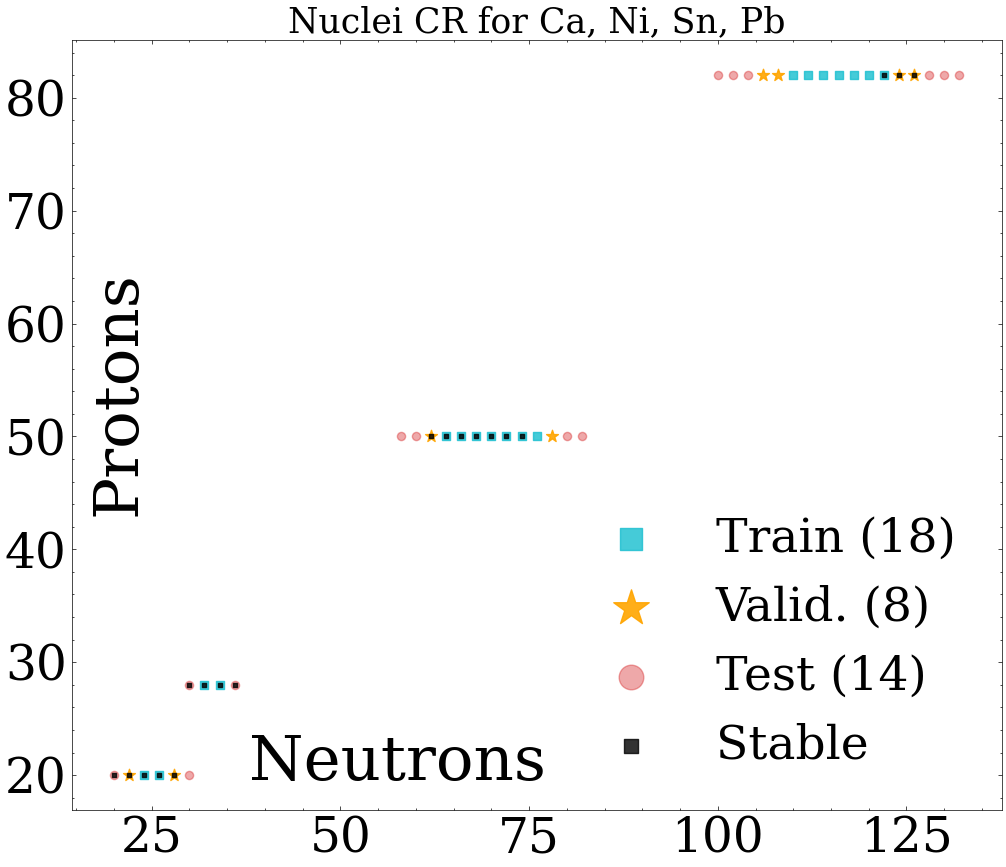

In [34]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(12,10), dpi=100)

# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

color_train=colors_sets[9]
color_validation='orange'
color_test=colors_sets[3]

marker_train='s'
marker_validation='*'
marker_test='o'



size_train=30
size_validation=80
size_test=35

alpha_train=0.8
alpha_validation=0.9
alpha_test=0.4



ax.scatter(x = training_set_radius.T[0], y = training_set_radius.T[1], label = "Train ("+ str(len(training_set_radius))+")", alpha = alpha_train,color=color_train,s=size_train,marker=marker_train)

ax.scatter(x = validation_set_radius.T[0], y = validation_set_radius.T[1], label = "Valid. (" + str(len(validation_set_radius))+")", alpha = alpha_validation,color=color_validation,s=size_validation,marker=marker_validation)

ax.scatter(x = test_set_radius.T[0], y = test_set_radius.T[1], label = "Test (" + str(len(test_set_radius))+")", alpha = alpha_test,color=color_test,s=size_test,marker=marker_test)


ax.scatter(x = stable_coordinates_radius.T[0], y = stable_coordinates_radius.T[1], label = "Stable", alpha = 0.8,color='black',s=11,marker="s")





# ax.scatter(x = np.array(AME2020New).T[0], y = np.array(AME2020New).T[1], label = "Valid. (" + str(len(validation_set))+")", alpha = alpha_validation,color=color_validation,s=size_validation,marker=marker_validation)


plt.xlabel('')

plt.annotate('Neutrons', xy=(0.35, 0.1), xycoords='axes fraction',
             ha='center', va='top', fontsize=45) 
plt.ylabel('')

plt.annotate('Protons', xy=(0.05,0.7), xycoords='axes fraction',
             ha='center', va='top', fontsize=45,rotation =90) 

plt.title('Nuclei CR for Ca, Ni, Sn, Pb', fontsize = 25)
# plt.ylabel("Protons",fontsize=45)
plt.legend(fontsize=34,markerscale=3 ,loc =(0.53,0.03))
plt.savefig('Plots/Radii data with 20, 28, 50, 82 - added models - new data splitting schemes/CR nuclei/Nuclei with real CR - Ca, Ni, Sn, Pb.png')
plt.show()

In [35]:
models_output_radius_list = models_output_extraction(selected_models_data_sets_radius_4_isotopic_chains, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
[models_output_radius, models_output_radius_train, models_output_radius_validation, models_output_radius_test] = models_output_radius_list

filtered_models_output_radius_list_20 = filtered_models_output_extraction(20, models_output_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
filtered_models_output_radius_stable_20 = filtered_models_output_stable_extraction(20, models_output_radius, stable_coordinates_radius)

filtered_models_output_radius_list_28 = filtered_models_output_extraction(28, models_output_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
filtered_models_output_radius_stable_28 = filtered_models_output_stable_extraction(28, models_output_radius, stable_coordinates_radius)

filtered_models_output_radius_list_50 = filtered_models_output_extraction(50, models_output_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
filtered_models_output_radius_stable_50 = filtered_models_output_stable_extraction(50, models_output_radius, stable_coordinates_radius)

filtered_models_output_radius_list_82 = filtered_models_output_extraction(82, models_output_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
filtered_models_output_radius_stable_82 = filtered_models_output_stable_extraction(82, models_output_radius, stable_coordinates_radius)

model_predictions_radius=models_output_radius[key_list].values
model_predictions_radius_train=models_output_radius_train[key_list].values
model_predictions_radius_validation=models_output_radius_validation[key_list].values
model_predictions_radius_test=models_output_radius_test[key_list].values
model_predictions_radius_list = [model_predictions_radius, model_predictions_radius_train, model_predictions_radius_validation, model_predictions_radius_test]

predictions_mean_radius= np.mean(model_predictions_radius, axis=1)
predictions_mean_radius_train= np.mean(model_predictions_radius_train, axis=1)
predictions_mean_radius_validation= np.mean(model_predictions_radius_validation, axis=1)
predictions_mean_radius_test= np.mean(model_predictions_radius_test, axis=1)

predictions_mean_radius_df = pd.DataFrame({'N' : filtered_NZ_radius.T[0], 'Z' : filtered_NZ_radius.T[1], 'PC_0' : predictions_mean_radius})

In [36]:
selected_models_data_sets_radius_4_isotopic_chains

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,...,UNEDF0,UNEDF1,collect.SV-min,collect.SV-min-HFBcut5,collect.UNEDF1-BCScut5-rho16,collect.UNEDF1.HFB-rho16,collect.Fystd,collect.FyDr,collect.FyDrHFB,collect.FyIVP-stab05
0,20,20,3.4776,3.465,3.425,3.457,3.470,3.508447,3.530085,3.508657,...,3.501457,3.483709,3.491765,3.489933,3.499238,3.494464,3.481121,3.456278,3.480780,3.479898
1,22,20,3.5081,3.469,3.435,3.463,3.468,3.513530,3.536751,3.515920,...,3.503420,3.487649,3.489670,3.487507,3.498409,3.495466,3.482421,3.515043,3.514082,3.508688
2,24,20,3.5179,3.474,3.447,3.472,3.469,3.517619,3.543701,3.522998,...,3.505047,3.494824,3.491783,3.489881,3.500371,3.499346,3.487125,3.500920,3.522877,3.517010
3,26,20,3.4953,3.479,3.459,3.481,3.472,3.523560,3.552996,3.531629,...,3.511087,3.505986,3.496894,3.494579,3.504425,3.504437,3.493322,3.502032,3.510142,3.493966
4,28,20,3.4771,3.481,3.468,3.490,3.474,3.533390,3.564701,3.543605,...,3.521495,3.520582,3.503516,3.500632,3.512822,3.512195,3.500746,3.451782,3.481027,3.480710
5,30,20,3.5168,3.512,3.496,3.511,3.498,3.547856,3.578512,3.559659,...,3.534937,3.536964,3.517770,3.517091,3.529348,3.528388,3.519997,3.519194,3.524258,3.520143
6,30,28,3.7757,3.758,3.817,3.777,3.740,3.796573,3.834224,3.813072,...,3.800082,3.787199,3.780500,3.779552,3.784227,3.783821,3.770102,3.741814,3.731653,3.737411
7,32,28,3.8118,3.804,3.838,3.827,3.768,3.812996,3.848746,3.829694,...,3.816437,3.816168,3.798124,3.793972,3.806146,3.805062,3.790042,3.773738,3.755224,3.756722
8,34,28,3.8399,3.833,3.845,3.826,3.794,3.835217,3.868574,3.861478,...,3.840018,3.843278,3.824261,3.823363,3.833020,3.833748,3.819184,3.818998,3.810162,3.817157
9,36,28,3.8572,3.838,3.829,3.846,3.818,3.860132,3.891267,3.880534,...,3.866367,3.863380,3.849553,3.849051,3.857569,3.858994,3.848699,3.855236,3.855190,3.860228


In [37]:
centering_data = True
if centering_data:
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,None]
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train.reshape(167,1)
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,np.newaxis]

In [38]:
model_predictions_radius_train.shape

(18, 18)

[1.90478403e-01 1.86401667e-01 1.12481452e-01 4.73425055e-02
 3.88823855e-02 2.71518420e-02 2.50899702e-02 2.11581826e-02
 1.24580484e-02 5.83052605e-03 3.51205084e-03 2.46260099e-03
 1.41853933e-03 8.77811143e-04 3.40241197e-04 3.06521503e-05
 1.33459883e-05 5.81644807e-15]


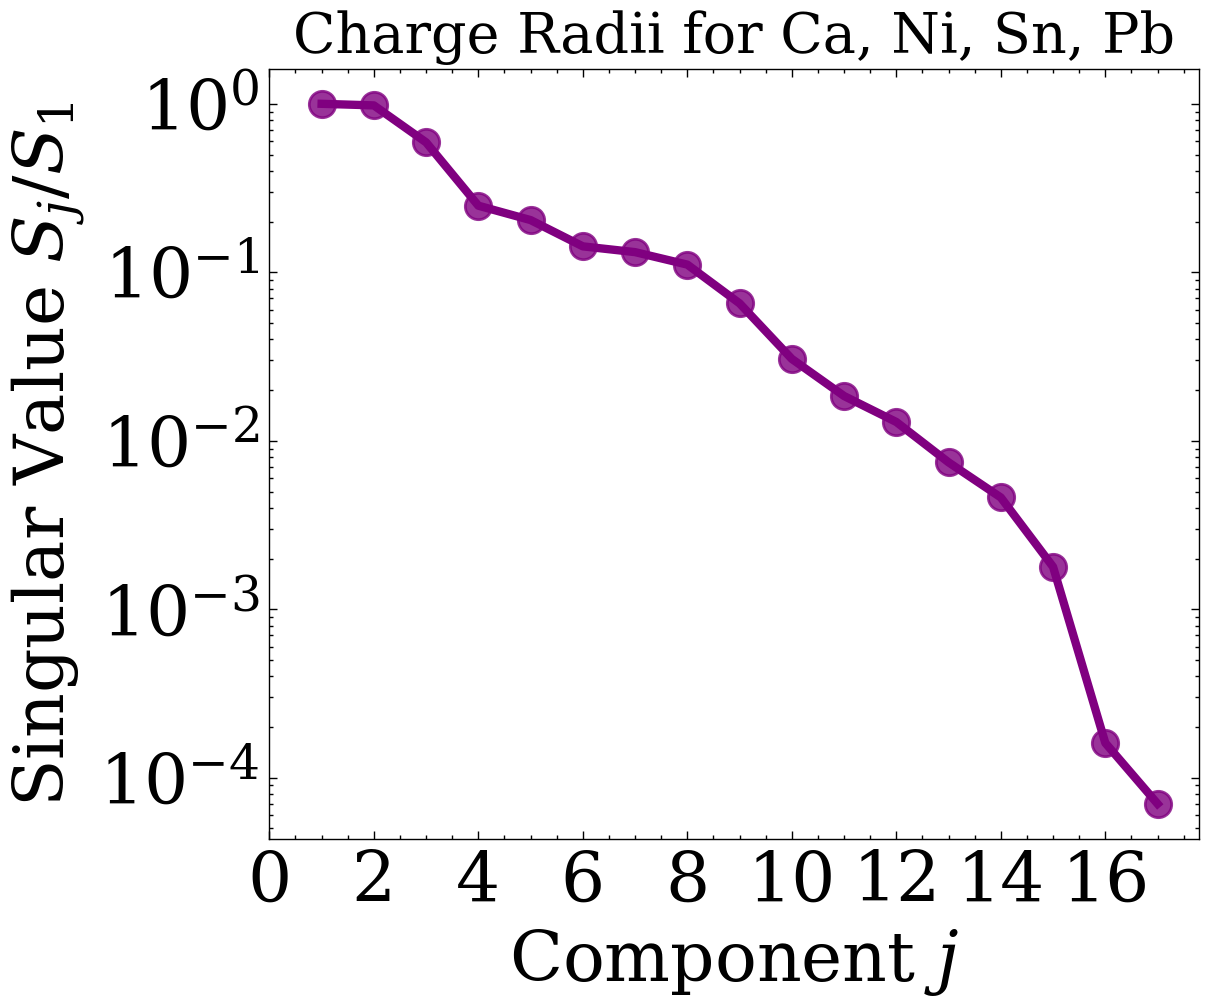

In [39]:
U, S, Vt = np.linalg.svd(model_predictions_radius_train_processed)

print(S)

plt.rc("xtick", labelsize = 25)
plt.rc("ytick", labelsize = 25)
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize = (6,5), dpi = 200)

ax.scatter(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", alpha = 0.8, s = 90, marker = 'o')
ax.plot(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", linewidth = 3)

ax.set_xticks([0,2,4,6,8,10,12,14,16])
plt.xlabel("Component $j$", fontsize = 25)
plt.ylabel("Singular Value $S_j/S_1$", fontsize = 25)
plt.yscale("log")
plt.title('Charge Radii for Ca, Ni, Sn, Pb', fontsize = 20)
plt.savefig('Plots/Radii data with 20, 28, 50, 82 - added models - new data splitting schemes/Singular values/Singular Values decay.png')
plt.show()

### With such singular values decays, we see that our models space can be effectively represented by about 11 models only. This means that with the new data splitting scheme, we do not need to use all of the models together

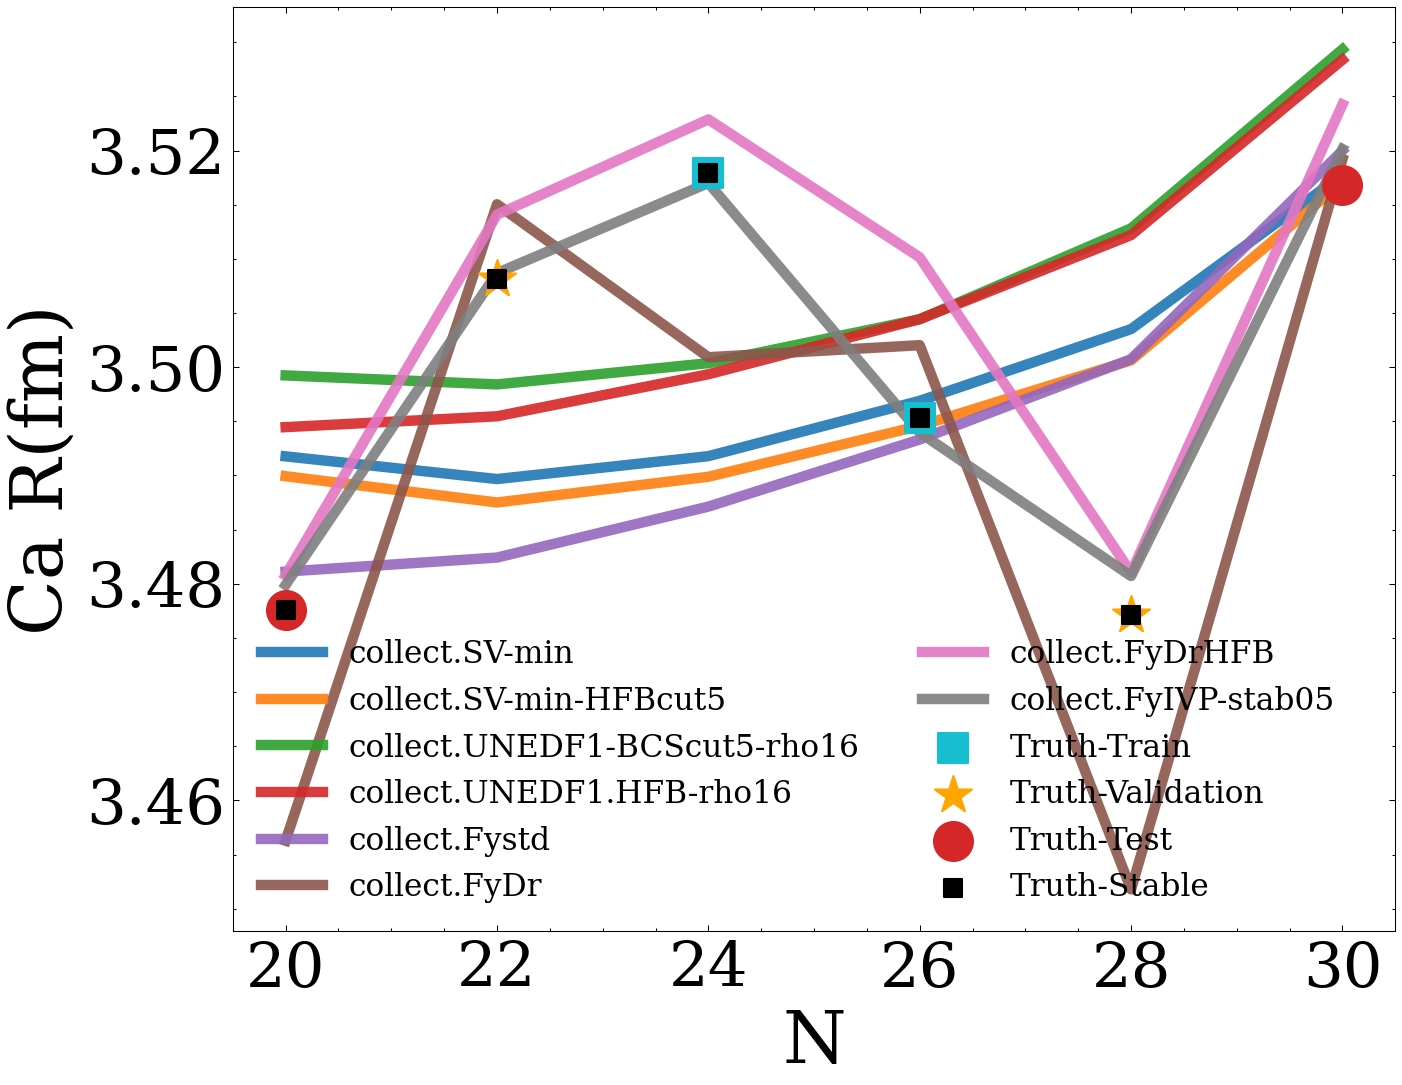

In [122]:
# I will graph the new models predictions for each isotope with all the models together
plot_model_predictions(filtered_models_output_radius_list_20, filtered_models_output_radius_stable_20, new_models, 'Ca')
plt.savefig('Plots/Radii data with 20, 28, 50, 82 - added models - new data splitting schemes/New models predictions/Ca predictions.png')
plt.show()

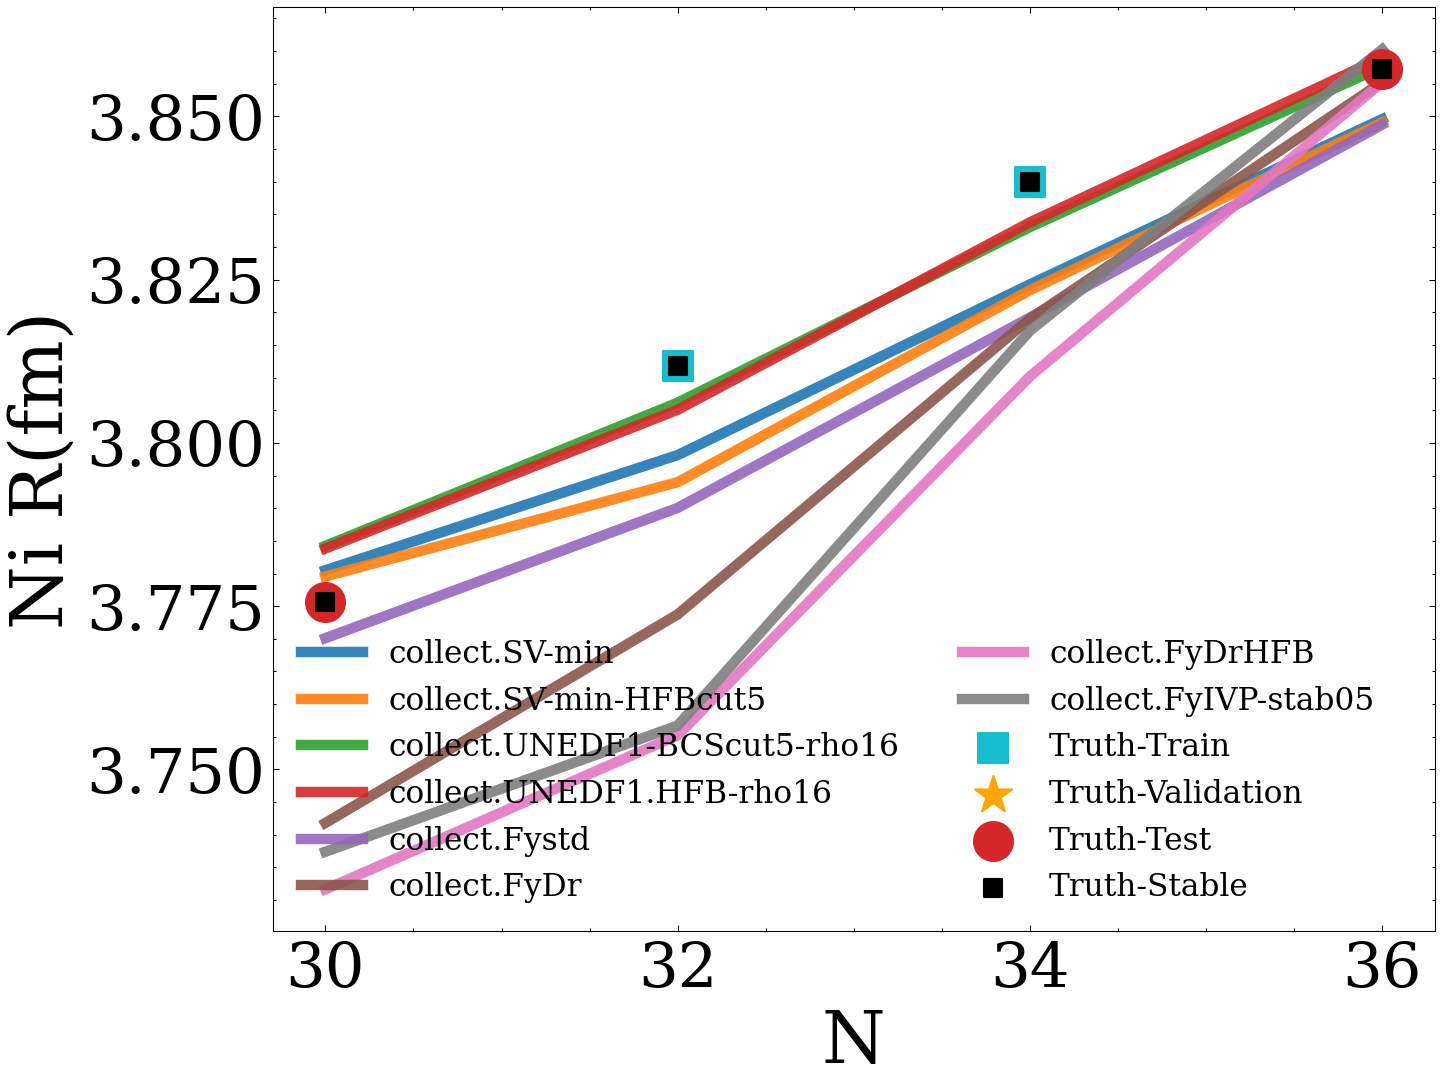

In [123]:
plot_model_predictions(filtered_models_output_radius_list_28, filtered_models_output_radius_stable_28, new_models, 'Ni')
plt.savefig('Plots/Radii data with 20, 28, 50, 82 - added models - new data splitting schemes/New models predictions/Ni predictions.png')
plt.show()

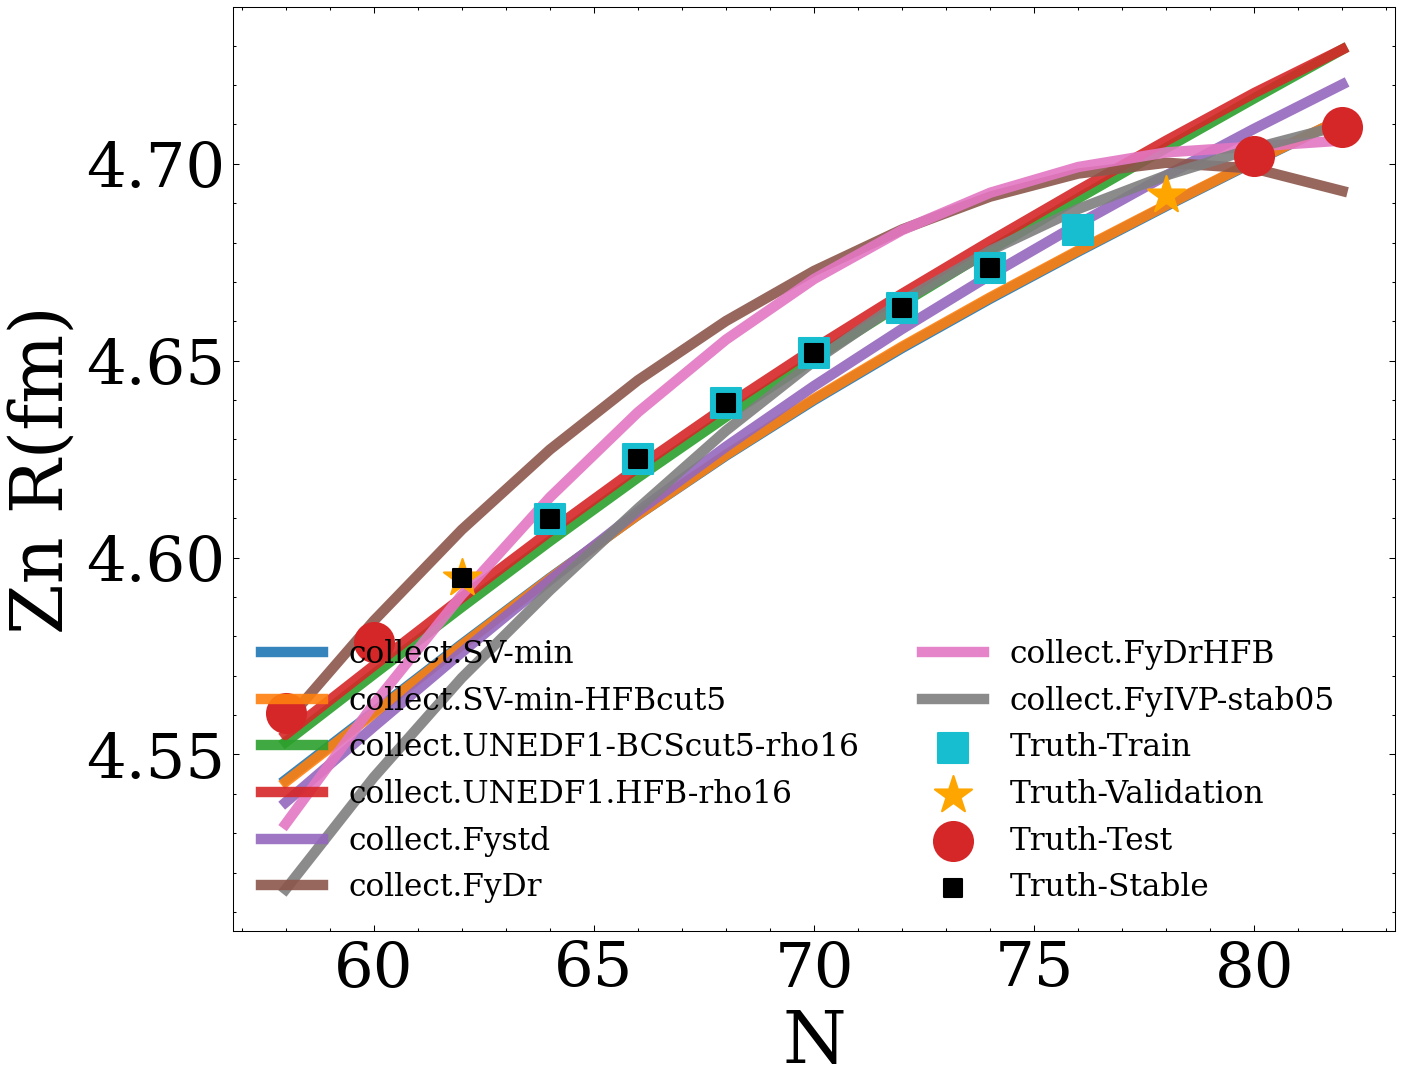

In [ ]:
plot_model_predictions(filtered_models_output_radius_list_50, filtered_models_output_radius_stable_50, new_models, 'Zn')
plt.savefig('Plots/Radii data with 20, 28, 50, 82 - added models - new data splitting schemes/New models predictions/Zn predictions.png')
plt.show()

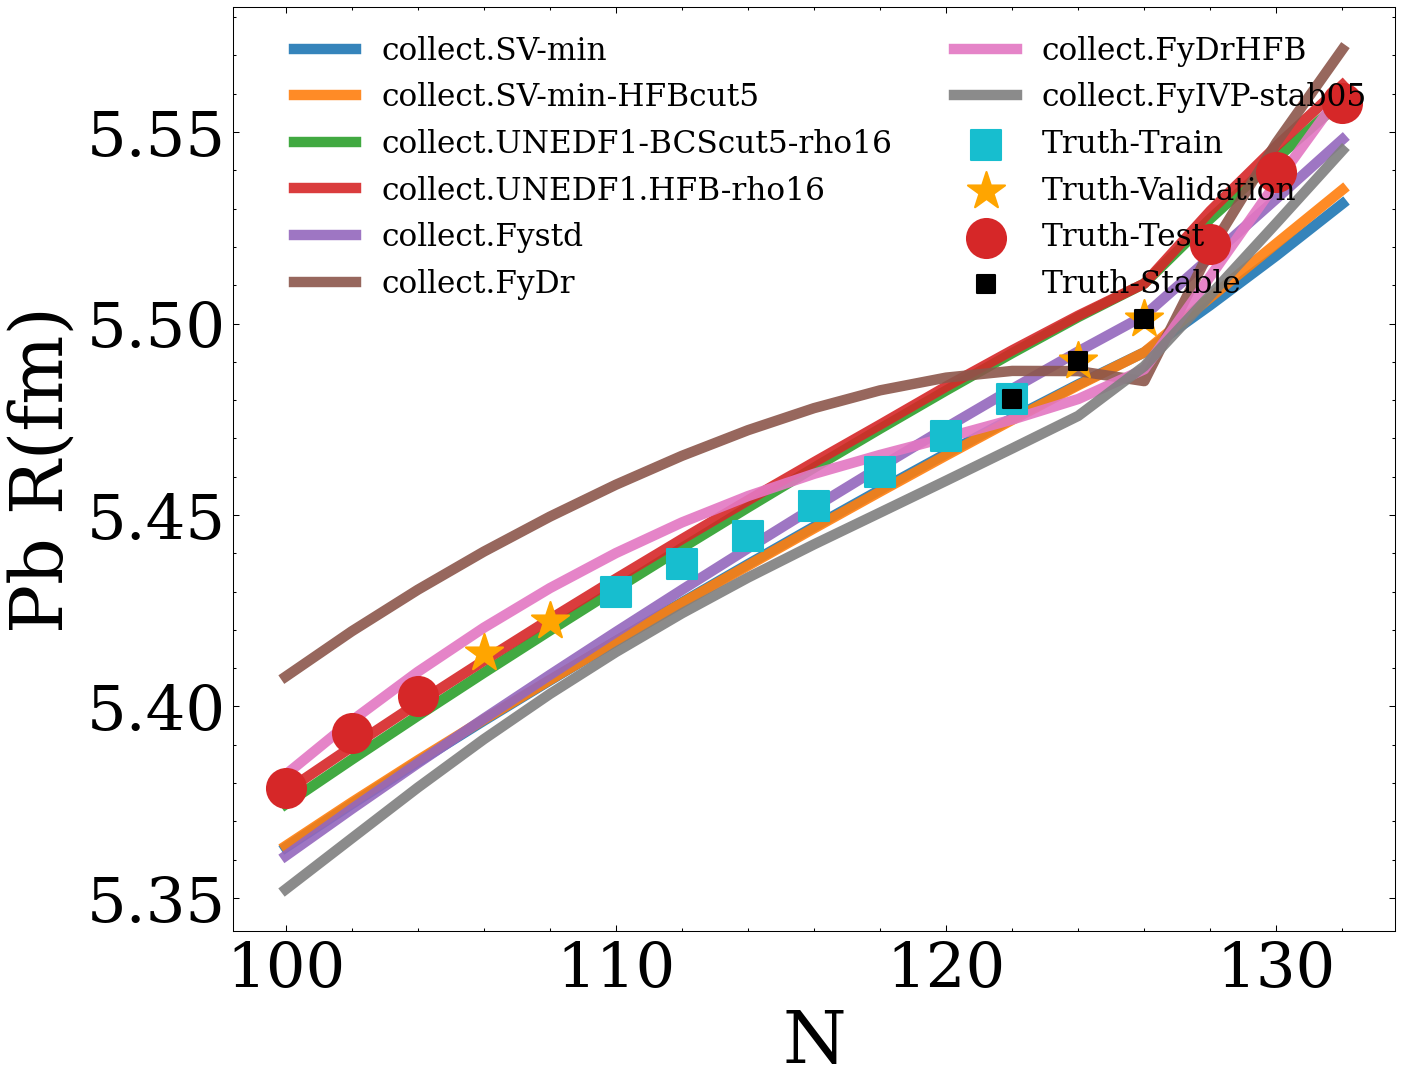

In [124]:
plot_model_predictions(filtered_models_output_radius_list_82, filtered_models_output_radius_stable_82, new_models, 'Pb')
plt.savefig('Plots/Radii data with 20, 28, 50, 82 - added models - new data splitting schemes/New models predictions/Pb predictions.png')
plt.show()

In [116]:
components_kept = 17
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized=np.array([Vt[i] for i in range(components_kept)])
# Vt_hat = np.array([Vt[i] for i in range(components_kept)])

models_PC_radius = models_PC_output(Vt_hat, model_predictions_radius, predictions_mean_radius, models_output_radius)
models_PC_radius_train = models_PC_output(Vt_hat, model_predictions_radius_train, predictions_mean_radius_train, models_output_radius_train)
models_PC_radius_validation = models_PC_output(Vt_hat, model_predictions_radius_validation, predictions_mean_radius_validation, models_output_radius_validation)
models_PC_radius_test = models_PC_output(Vt_hat, model_predictions_radius_test, predictions_mean_radius_test, models_output_radius_test)

In [117]:
super_params_train = super_params(model_predictions_radius_train, models_output_radius_train['truth'])
supermodel_radius_train = super_params_train.dot(model_predictions_radius_train.T)
supermodel_radius_validation = super_params_train.dot(model_predictions_radius_validation.T)
supermodel_radius_test = super_params_train.dot(model_predictions_radius_test.T)
supermodel_radius_full = super_params_train.dot(model_predictions_radius.T)

supermodel_residuals_radius_train=supermodel_radius_train-models_output_radius_train['truth'].tolist()
supermodel_residuals_radius_validation= supermodel_radius_validation-models_output_radius_validation['truth'].tolist()
supermodel_residuals_radius_test = supermodel_radius_test-models_output_radius_test['truth'].tolist()
supermodel_residuals_radius_full = supermodel_radius_full-models_output_radius['truth'].tolist()

supermodel_sigma_radius_train=np.sqrt(np.sum(supermodel_residuals_radius_train**2) / len(supermodel_residuals_radius_train) )
supermodel_sigma_radius_validation=np.sqrt(np.sum(supermodel_residuals_radius_validation**2) / len(supermodel_residuals_radius_validation) )
supermodel_sigma_radius_test=np.sqrt(np.sum(supermodel_residuals_radius_test**2) / len(supermodel_residuals_radius_test) )
supermodel_sigma_radius_full=np.sqrt(np.sum(supermodel_residuals_radius_full**2) / len(supermodel_residuals_radius_full) )

In [118]:
if centering_data:
    s_radius_validation=[np.linalg.norm(np.array(models_output_radius_validation["truth"].tolist())-predictions_mean_radius_validation)/np.sqrt(len(predictions_mean_radius_validation))]
    s_radius_test=[np.linalg.norm(np.array(models_output_radius_test["truth"].tolist())-predictions_mean_radius_test)/np.sqrt(len(predictions_mean_radius_test))]
    s_radius_train=[np.linalg.norm(np.array(models_output_radius_train["truth"].tolist())-predictions_mean_radius_train)/np.sqrt(len(predictions_mean_radius_train))]
    s_radius_all=[np.linalg.norm(np.array(models_output_radius["truth"].tolist())-predictions_mean_radius)/np.sqrt(len(predictions_mean_radius))]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator(i, model_predictions_radius_train, predictions_mean_radius_train, models_output_radius_train, models_output_radius_list, model_predictions_radius_list, U, S, Vt)
        s_radius_all.append(res[0])
        s_radius_train.append(res[1])
        s_radius_validation.append(res[2])
        
        s_radius_test.append(res[3])

[-0.00089879 -0.02956877 -0.00184097  0.00207084  0.078863    0.0716439
  0.05505015  0.08412402  0.07690354  0.04788312  0.07961058  0.07960511
  0.06701425  0.06544068  0.0740728   0.05472291  0.09095706  0.10434657]
0.007044983092021729
[-0.00137391 -0.02750702 -0.00268477  0.01158574  0.07547106  0.05285735
  0.04191756  0.08436641  0.0753809   0.04533253  0.08769255  0.08822711
  0.0675206   0.06508346  0.08152653  0.0502406   0.09080727  0.11355605]
0.00691472079969384
[-0.02109209  0.01309788 -0.00346109 -0.03079127  0.08498225  0.06629497
  0.04168883  0.1226371   0.09726006  0.06191005  0.11571815  0.11230034
  0.08073788  0.07266752  0.09459371 -0.01886135  0.01831941  0.09199765]
0.005894892774772745
[-0.0181946  -0.00486304  0.00215099 -0.01787954  0.08709866  0.0626375
  0.05510244  0.1255229   0.09231541  0.07701938  0.11715636  0.11309024
  0.07607279  0.06677487  0.09079264 -0.03225226  0.01386285  0.09359241]
0.005881534326511583
[-0.01713232 -0.0074642   0.00457066 -0

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
C:\Users\congn\AppData\Local\Temp\ipykernel_15012\1402970936.py:14: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(np.arange(0,len(s_radius_train[:-8])), s_radius_train[:-8],color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')
C:\Users\congn\AppData\Local\Temp\ipykernel_15012\1402970936.py:17: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(np.arange(0,len(s_radius_validation[:-8])), s_radius_validation[:-8],color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")
C:\Users\congn\AppData\Local\Temp\ipykernel_15012\1402970936.py:21: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(np.arange(0,len(s_radius_test[:-8])), s_radius_test[:

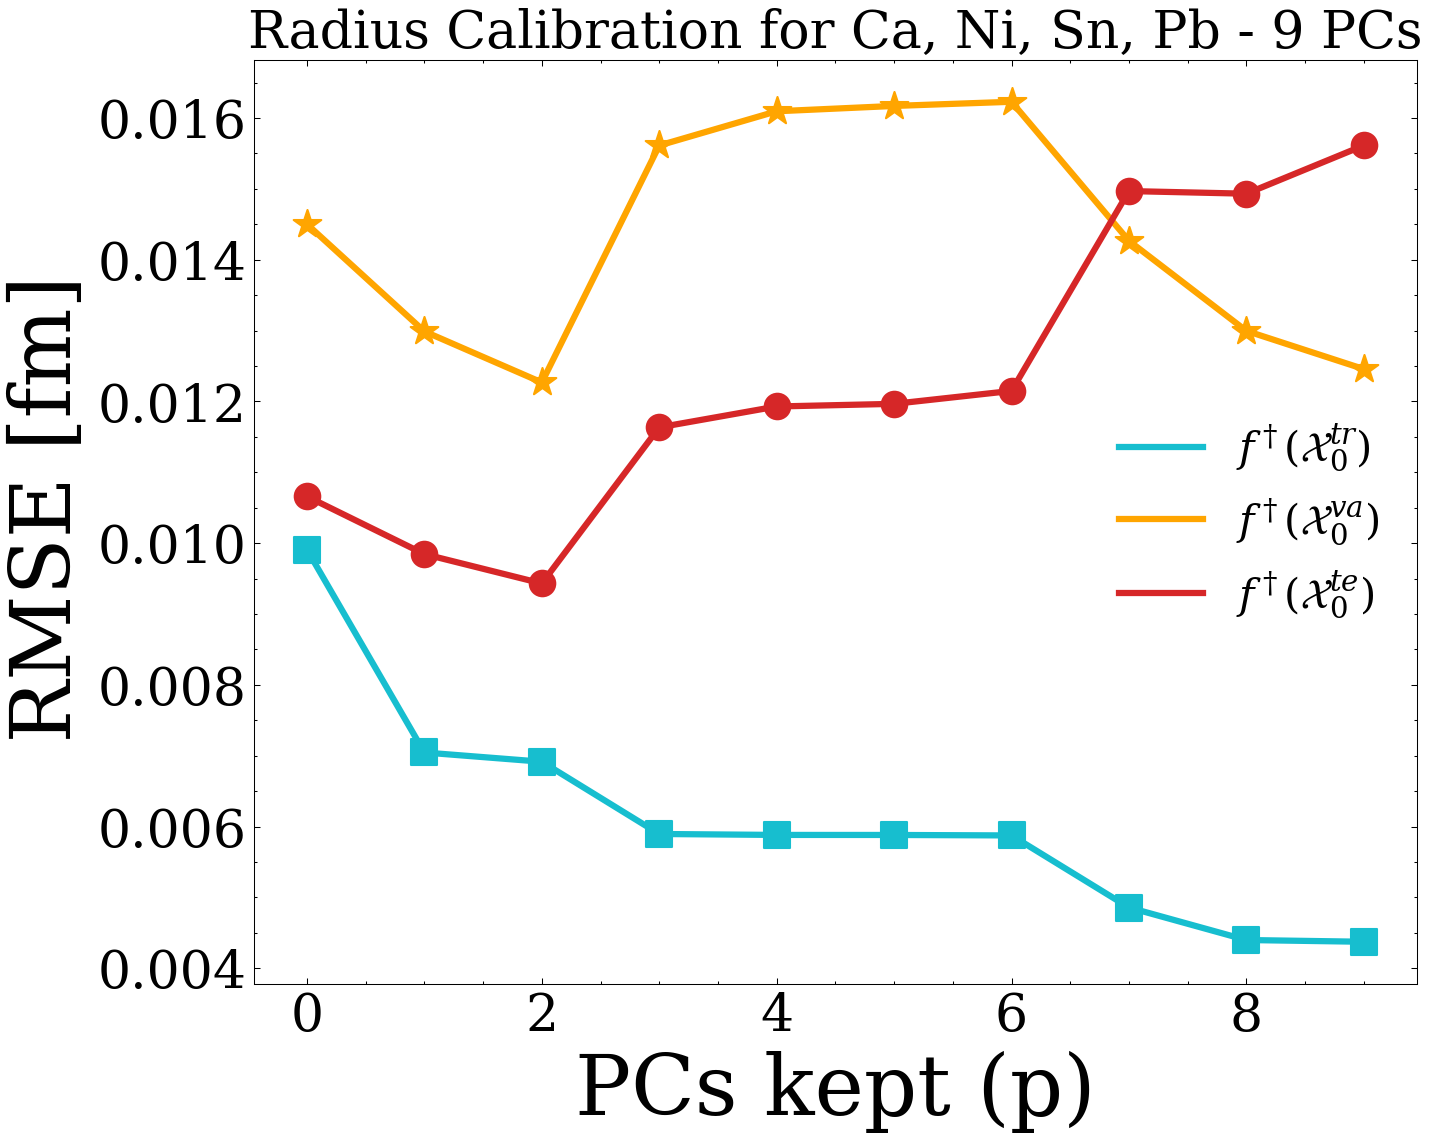

In [126]:
plt.rc("xtick", labelsize=25)
plt.rc("ytick", labelsize=25)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_radius_train[:-8])), s_radius_train[:-8],color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_radius_train[:-8])), s_radius_train[:-8],color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_radius_validation[:-8])), s_radius_validation[:-8],color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_radius_validation[:-8])), s_radius_validation[:-8],color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_radius_test[:-8])), s_radius_test[:-8],color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_radius_test[:-8])), s_radius_test[:-8],color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=supermodel_sigma_radius_train,color=color_train,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)
# ax.axhline(y=supermodel_sigma_radius_validation,color=color_validation,label="BMC$(\mathcal{X}_0^{va})$",linestyle='dashed',linewidth=3)
# ax.axhline(y=supermodel_sigma_radius_test,color=color_test,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'PCs kept (p)',fontsize=40)
ax.set_ylabel(r' RMSE [fm]',fontsize=40);
ax.set_xticks([0,2,4,6,8])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=20)
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.title('Radius Calibration for Ca, Ni, Sn, Pb - 9 PCs', fontsize = 25)
plt.savefig('Plots/Radii data with 20, 28, 50, 82 - added models - new data splitting schemes/RMSE decays/Radius RMSE decays with 9 PCs.png')
# plt.legend(fontsize=30)
plt.show()

In [127]:
models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
new_models = [
    "collect.SV-min",
    "collect.SV-min-HFBcut5",
    "collect.UNEDF1-BCScut5-rho16",
    "collect.UNEDF1.HFB-rho16",
    "collect.Fystd",
    "collect.FyDr",
    "collect.FyDrHFB",
    "collect.FyIVP-stab05",
]

# models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0','UNEDF1', "collect.SV-min","collect.SV-min-HFBcut5",
#     "collect.UNEDF1-BCScut5-rho16", "collect.UNEDF1.HFB-rho16", "collect.Fystd","collect.FyDr", "collect.FyDrHFB", "collect.FyIVP-stab05"]

In [128]:
def models_RMSE_radius_calculator(models_selected):
    models_RMSE_train = []
    models_RMSE_validation = []
    models_RMSE_test = []
    models_RMSE_full = []

    for model in models_selected:
        residuals_train=models_output_radius_train[model]-models_output_radius_train['truth'].tolist()
        residuals_validation= models_output_radius_validation[model]-models_output_radius_validation['truth'].tolist()
        residuals_test = models_output_radius_test[model]-models_output_radius_test['truth'].tolist()
        residuals_full = models_output_radius[model]-models_output_radius['truth'].tolist()
    
        sigma_train=np.sqrt(np.sum(residuals_train**2) / len(residuals_train) )
        sigma_validation=np.sqrt(np.sum(residuals_validation**2) / len(residuals_validation) )
        sigma_test=np.sqrt(np.sum(residuals_test**2) / len(residuals_test) )
        sigma_full=np.sqrt(np.sum(residuals_full**2) / len(residuals_full) )

        models_RMSE_train.append(sigma_train)
        models_RMSE_validation.append(sigma_validation)
        models_RMSE_test.append(sigma_test)
        models_RMSE_full.append(sigma_full)
        
    return models_RMSE_train, models_RMSE_validation, models_RMSE_test, models_RMSE_full

In [133]:
models_RMSE_radius_train, models_RMSE_radius_validation, models_RMSE_radius_test, models_RMSE_radius_full = models_RMSE_radius_calculator(models_selected + new_models)

20

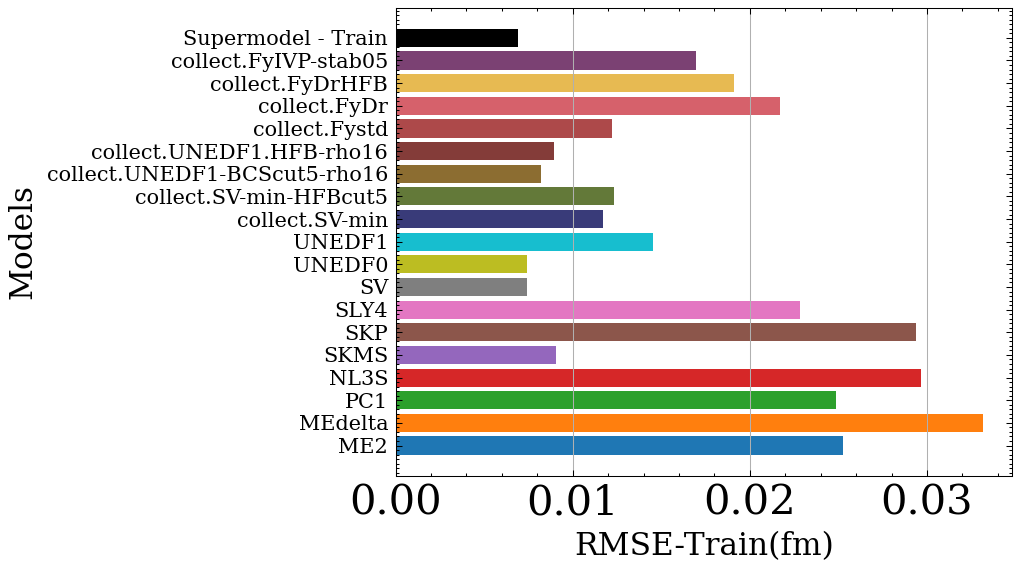

In [137]:
y_max = 0.05

# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# Train region
plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
plt.figure(figsize=(7, 4), dpi=150)
i = 0
for model in (models_selected + new_models):
    plt.barh(model, models_RMSE_radius_train[i], color=colors[i])
    i += 1
plt.barh('Supermodel - Train', s_radius_train[2], color='k')

plt.xlabel('RMSE-Train(fm)', fontsize=15)
plt.ylabel('Models', fontsize=15)
plt.yticks(fontsize=10)
plt.grid(axis='x')
plt.tight_layout()
plt.savefig('Plots/Radii data with 20, 28, 50, 82 - added models - new data splitting schemes/Models RMSE/Models RMSE - train - Ca, Ni, Sn, Pb - added models.png')
plt.show()

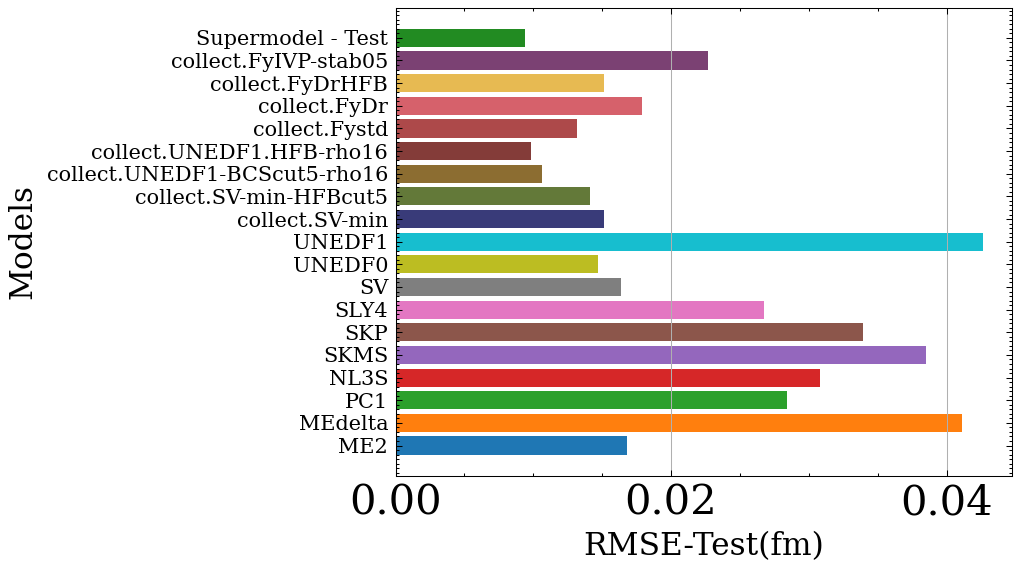

In [139]:
y_max = 0.05

# Test region
plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
plt.figure(figsize=(7, 4), dpi=150)
i = 0
for model in (models_selected + new_models):
    plt.barh(model, models_RMSE_radius_test[i], color=colors[i])
    i += 1
plt.barh('Supermodel - Test', s_radius_test[2], color='forestgreen')

plt.xlabel('RMSE-Test(fm)', fontsize=15)
plt.ylabel('Models', fontsize=15)
plt.yticks(fontsize=10)
plt.grid(axis='x')
plt.tight_layout()
plt.savefig('Plots/Radii data with 20, 28, 50, 82 - added models - new data splitting schemes/Models RMSE/Models RMSE - test - Ca, Ni, Sn, Pb - added models.png')
plt.show()

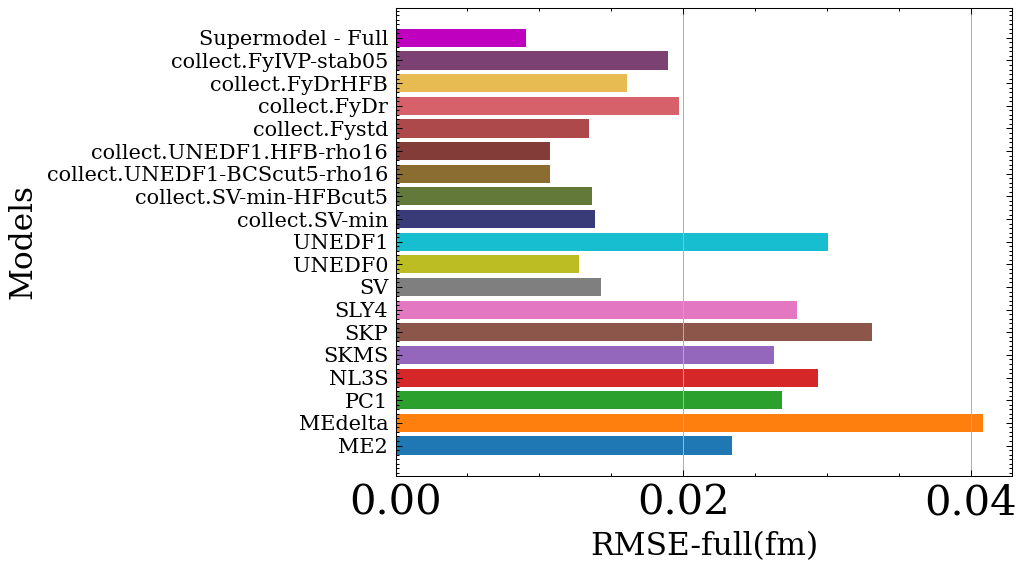

In [140]:
y_max = 0.05

# Full region
plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
plt.figure(figsize=(7, 4), dpi=150)
i = 0
for model in (models_selected + new_models):
    plt.barh(model, models_RMSE_radius_full[i], color=colors[i])
    i += 1
plt.barh('Supermodel - Full', s_radius_all[2], color='m')

plt.xlabel('RMSE-full(fm)', fontsize=15)
plt.ylabel('Models', fontsize=15)
plt.yticks(fontsize=10)
plt.grid(axis='x')
plt.tight_layout()
plt.savefig('Plots/Radii data with 20, 28, 50, 82 - added models - new data splitting schemes/Models RMSE/Models RMSE - full - Ca, Ni, Sn, Pb - added models.png')
plt.show()

In [137]:
# y_max = 0.05

# plt.rc("xtick", labelsize=20)
# plt.rc("ytick", labelsize=20)
# plt.figure(figsize=(7, 4),dpi=150)
# i = 0
# for model in models_selected:
#     plt.bar(model, models_RMSE_radius_train[i], color = colors[i])
#     i+=1
# # plt.bar('Supermodel - Full', supermodel_sigma_radius_train, color = 'm')
# plt.bar('Supermodel - Train', s_radius_train[4], color = 'k')
# # plt.bar('Supermodel - Test', supermodel_sigma_radius_train_test, color = 'forestgreen')

# plt.xlabel('Models',fontsize=15)
# plt.ylabel('RMSE-Train(fm)',fontsize=15)
# # plt.ylim(0,y_max)
# plt.xticks(fontsize=10,rotation='vertical')
# plt.grid(axis='y')
# plt.tight_layout()
# # plt.savefig('Plots/Radii data with 20, 28, 50, 82/Models RMSE/Models RMSE - train - Ca, Ni, Sn, Pb - original models space.png')
# plt.show()

# #############################
# # test region ###############

# plt.rc("xtick", labelsize=20)
# plt.rc("ytick", labelsize=20)
# plt.figure(figsize=(7, 4),dpi=150)
# i = 0
# for model in models_selected:
#     plt.bar(model, models_RMSE_radius_test[i], color = colors[i])
#     i+=1
# # plt.bar('Supermodel - Full', supermodel_sigma_radius_test, color = 'm')
# # plt.bar('Supermodel - Train', supermodel_sigma_radius_test_train, color = 'k')
# plt.bar('Supermodel - Test', s_radius_test[4], color = 'forestgreen')

# plt.xlabel('Models',fontsize=15)
# plt.ylabel('RMSE-Test(fm)',fontsize=15)
# # plt.ylim(0,y_max)
# plt.xticks(fontsize=10,rotation='vertical')
# plt.grid(axis='y')
# plt.tight_layout()
# # plt.savefig('Plots/Radii data with 20, 28, 50, 82/Models RMSE/Models RMSE - test - Ca, Ni, Sn, Pb - original models space.png')
# plt.show()

# ##############################
# # full region ################

# plt.rc("xtick", labelsize=20)
# plt.rc("ytick", labelsize=20)
# plt.figure(figsize=(7, 4),dpi=150)
# i = 0
# for model in models_selected:
#     plt.bar(model, models_RMSE_radius_full[i], color = colors[i])
#     i+=1
# plt.bar('Supermodel - Full', s_radius_all[4], color = 'm')
# # plt.bar('Supermodel - Train', supermodel_sigma_radius_test_train, color = 'k')
# # plt.bar('Supermodel - Test', supermodel_sigma_radius_test_test, color = 'forestgreen')

# plt.xlabel('Models',fontsize=15)
# plt.ylabel('RMSE-full(fm)',fontsize=15)
# # plt.ylim(0,y_max)
# plt.xticks(fontsize=10,rotation='vertical')
# plt.grid(axis='y')
# plt.tight_layout()
# # plt.savefig('Plots/Radii data with 20, 28, 50, 82/Models RMSE/Models RMSE - full - Ca, Ni, Sn, Pb - original models space.png')
# plt.show()


In [141]:
predictions_mean_radius_df

,N,Z,PC_0
0,20,20,3.484699
1,22,20,3.493846
2,24,20,3.498131
3,26,20,3.501972
4,28,20,3.503982
5,30,20,3.527620
6,30,28,3.779574
7,32,28,3.803186
8,34,28,3.831753
9,36,28,3.855148


In [142]:
x = [20,28,50,82]

filtered_predictions_mean_radius_dict= filtered_models_output_dict_extraction(x, 'filtered_predictions_mean_radius_list_' , predictions_mean_radius_df,\
                                    train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius, stable_coordinates_radius)
filtered_predictions_mean_radius_dict.keys()

dict_keys(['filtered_predictions_mean_radius_list_20', 'filtered_predictions_mean_radius_list_28', 'filtered_predictions_mean_radius_list_50', 'filtered_predictions_mean_radius_list_82'])

In [143]:
filtered_models_output_radius_dict = filtered_models_output_dict_extraction(x, 'filtered_models_output_radius_list_' , models_output_radius,\
                                    train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius, stable_coordinates_radius)
filtered_models_output_radius_dict.keys()

dict_keys(['filtered_models_output_radius_list_20', 'filtered_models_output_radius_list_28', 'filtered_models_output_radius_list_50', 'filtered_models_output_radius_list_82'])

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
C:\Users\congn\AppData\Local\Temp\ipykernel_15012\3017001144.py:21: SyntaxWarning: invalid escape sequence '\m'
  ax.scatter(x = filtered_models_output_radius_dict[dict_keys[i]][1]["N"], y = filtered_models_output_radius_dict[dict_keys[i]][1]['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
C:\Users\congn\AppData\Local\Temp\ipykernel_15012\3017001144.py:23: SyntaxWarning: invalid escape sequence '\m'
  ax.scatter(x = filtered_models_output_radius_dict[dict_keys[i]][2]["N"], y = filtered_models_output_radius_dict[dict_keys[i]][2]['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=

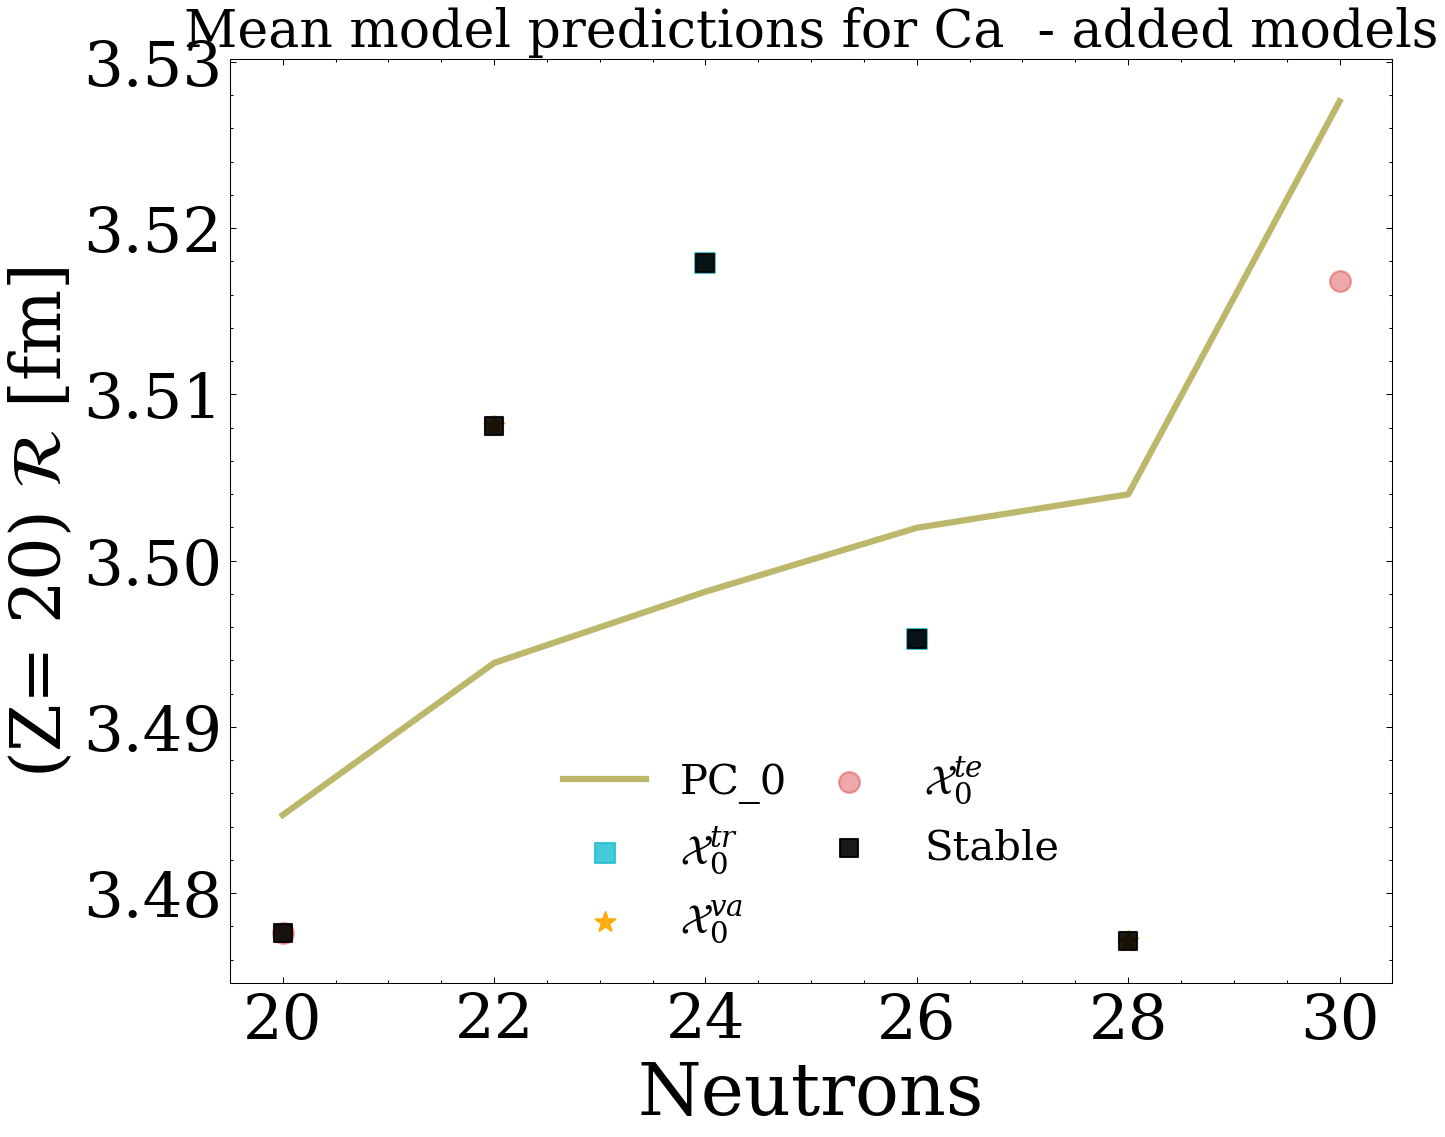

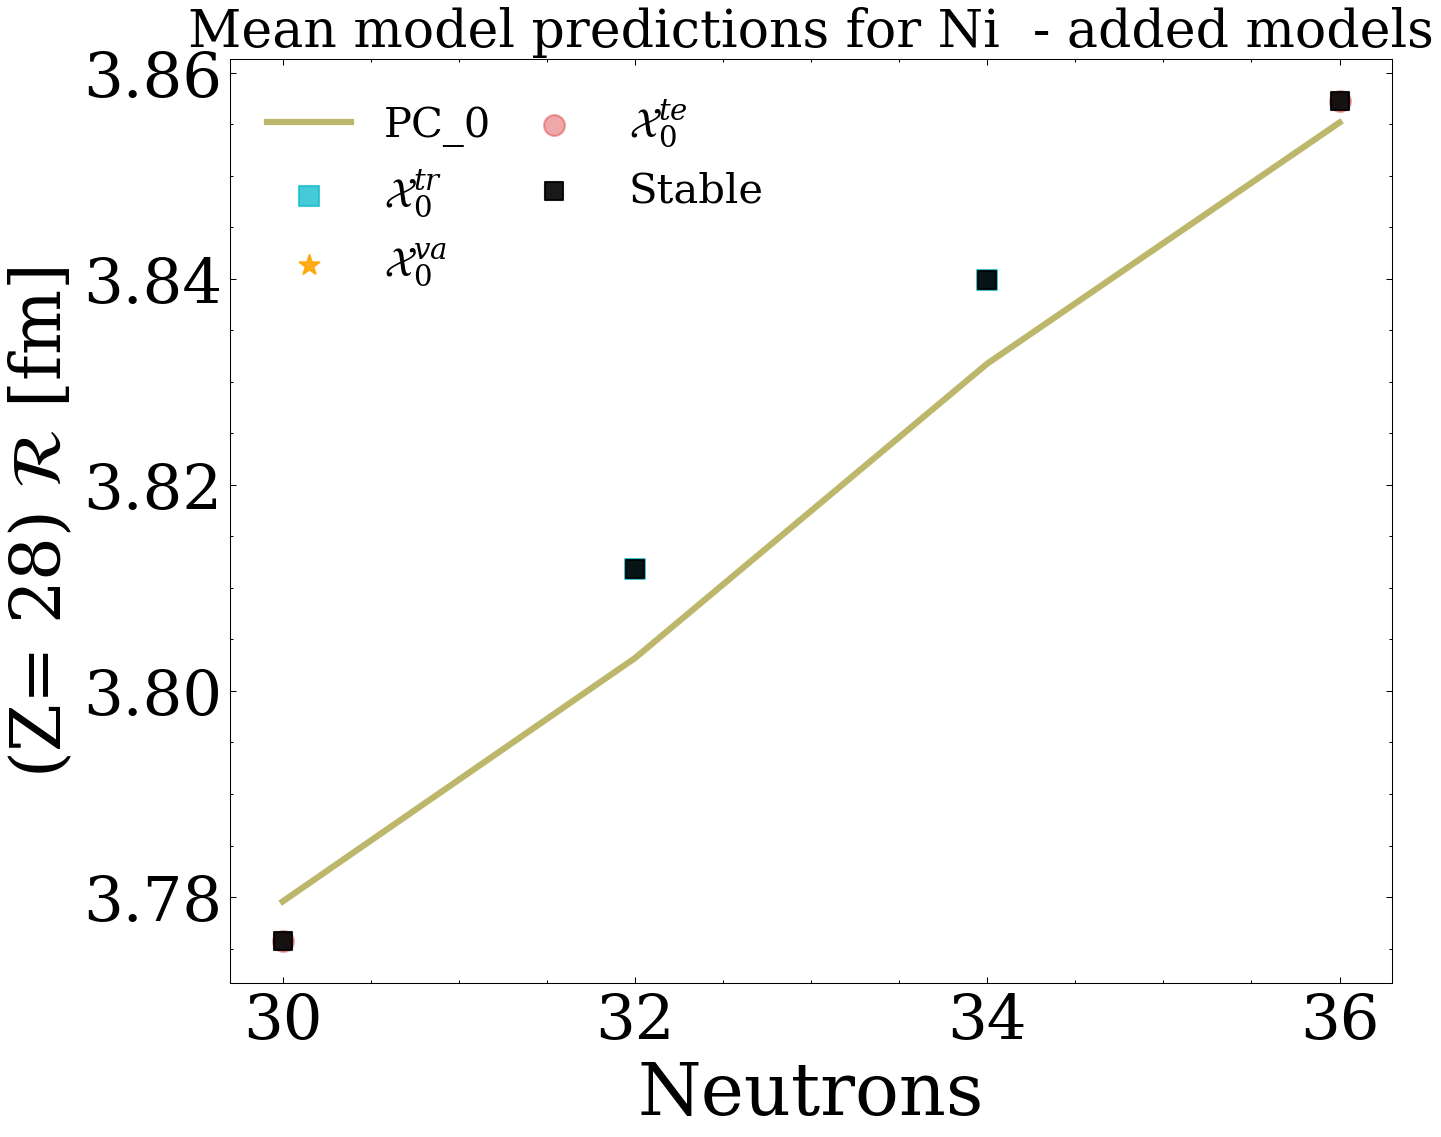

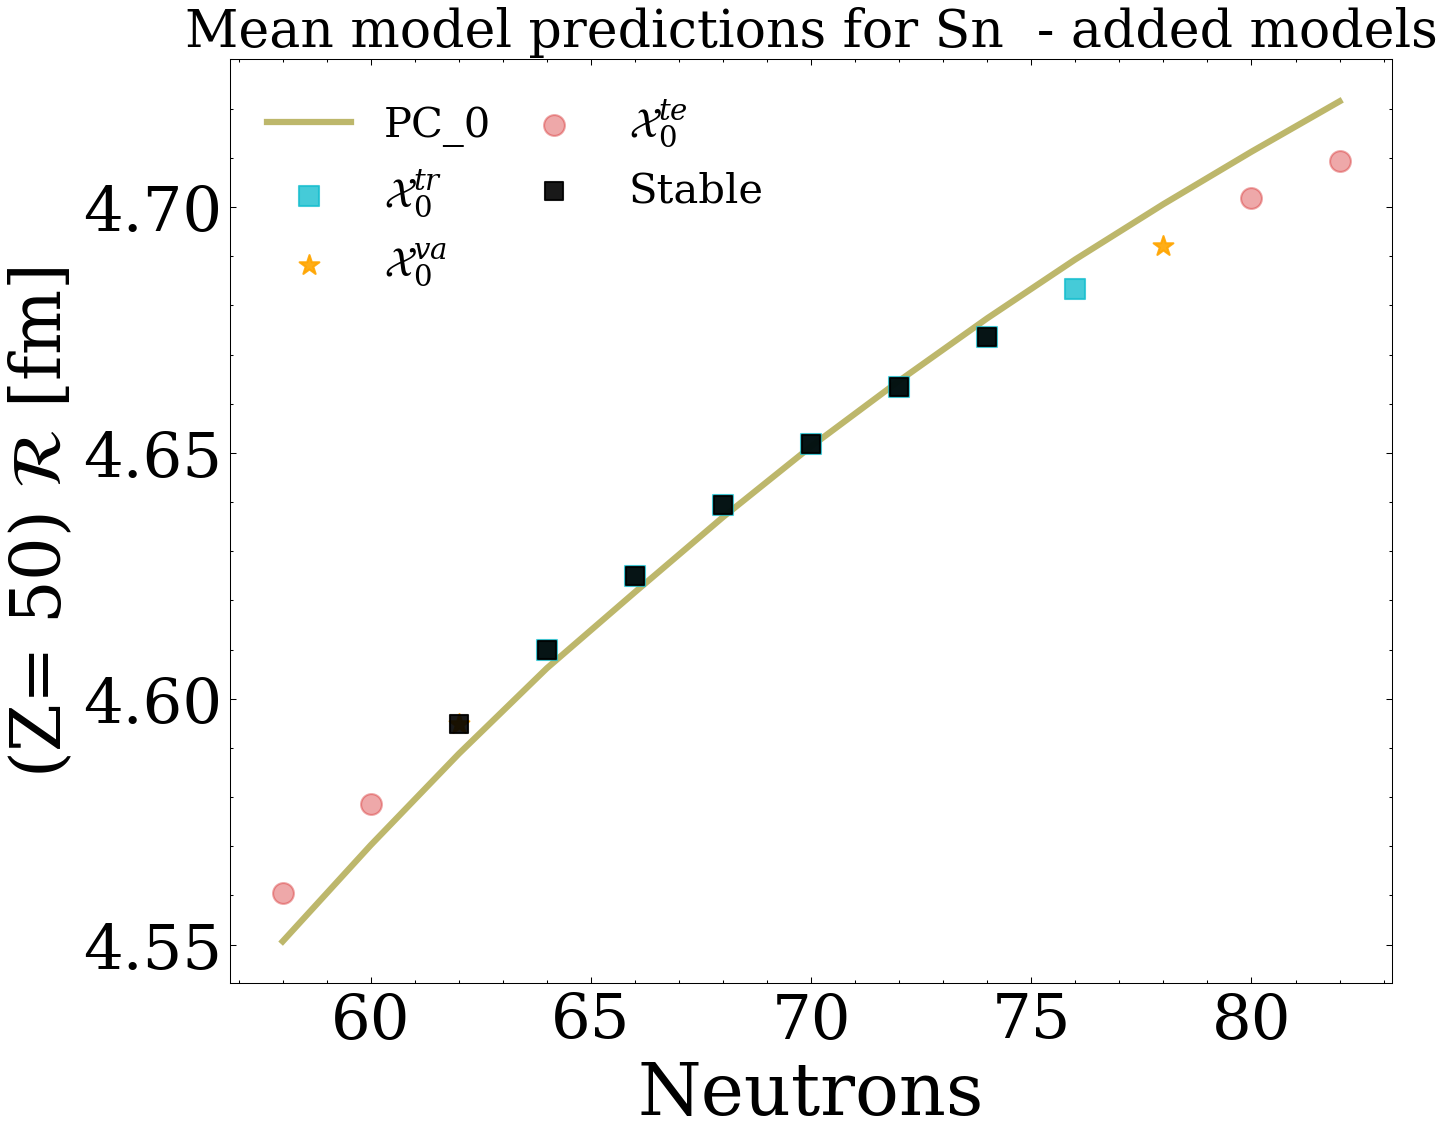

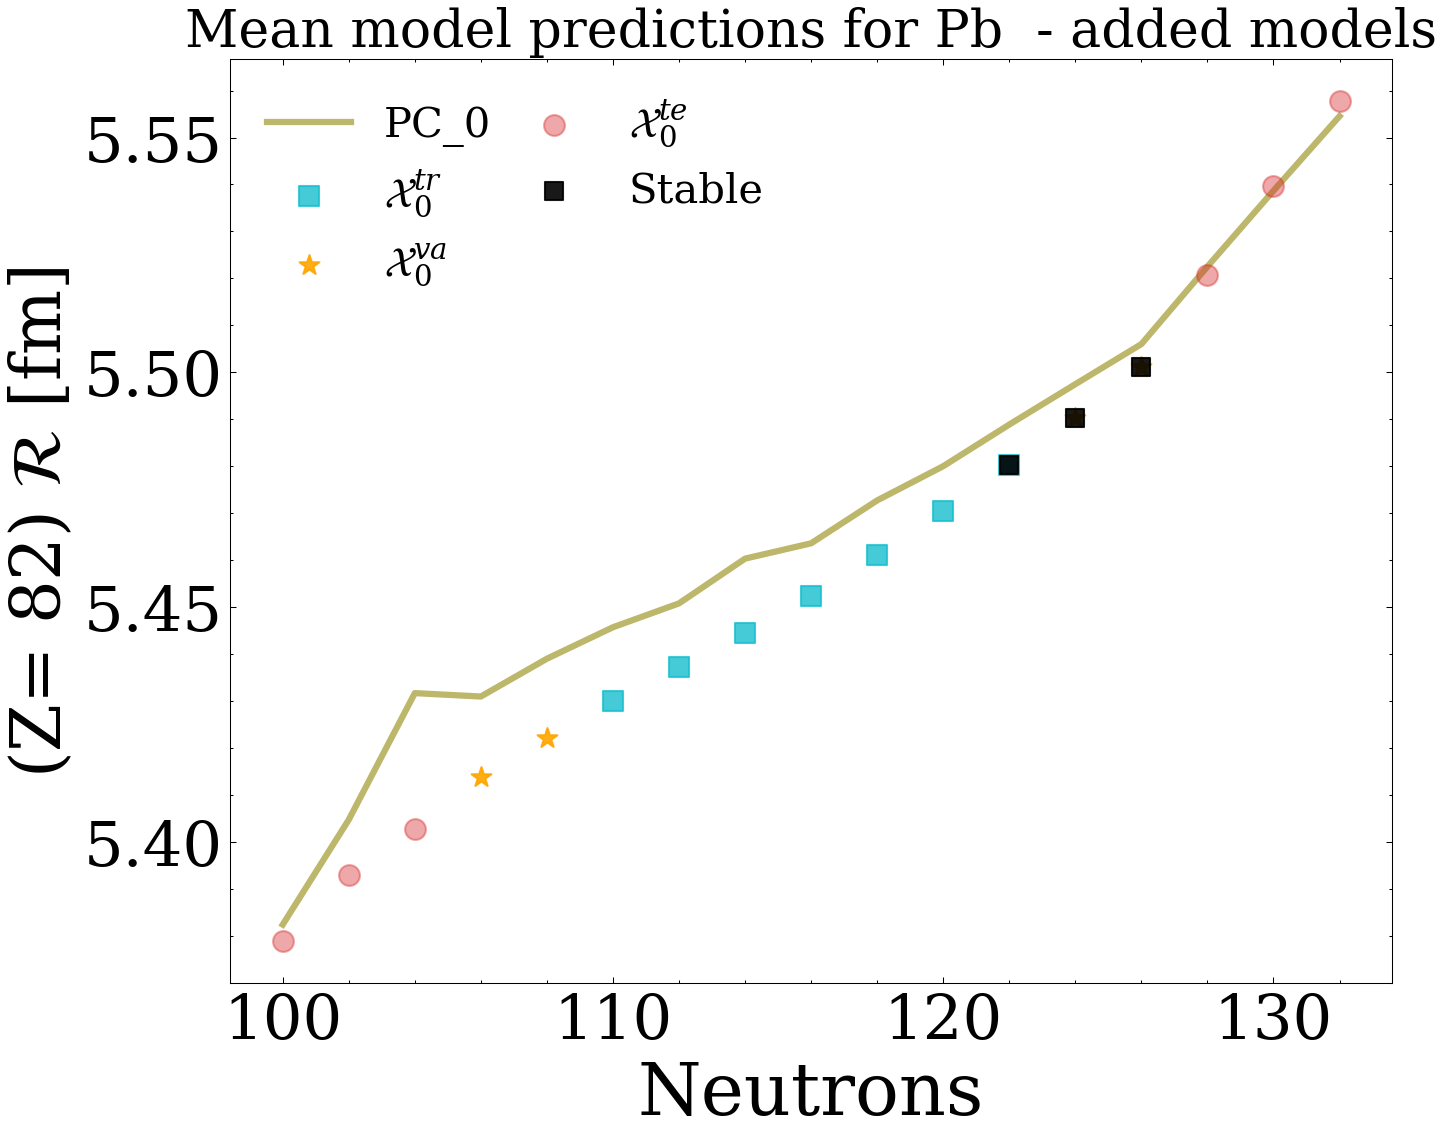

In [144]:
x = [20,28,50,82]
Selected_elements_list = ['Ca', 'Ni', 'Sn', 'Pb']
dict_keys_mean = list(filtered_predictions_mean_radius_dict.keys())
dict_keys = list(filtered_models_output_radius_dict.keys())

i = 0
for key in dict_keys_mean:
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)
    
    # plt.rcParams['text.usetex'] = False
    # plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    # This gives you the mean predictions of the isotope that we choose
    plt.plot(filtered_predictions_mean_radius_dict[key][0]["N"], filtered_predictions_mean_radius_dict[key][0]['PC_0'] , color="darkkhaki", label='PC_0',linewidth=3)

    color_local= "khaki"

    # This gives you training predictions for these isotope
    ax.scatter(x = filtered_models_output_radius_dict[dict_keys[i]][1]["N"], y = filtered_models_output_radius_dict[dict_keys[i]][1]['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    # This gives you validation predictions for these isotope
    ax.scatter(x = filtered_models_output_radius_dict[dict_keys[i]][2]["N"], y = filtered_models_output_radius_dict[dict_keys[i]][2]['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)
    # This gives you testing predictions for these isotope
    ax.scatter(x = filtered_models_output_radius_dict[dict_keys[i]][3]["N"], y = filtered_models_output_radius_dict[dict_keys[i]][3]['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    # This gives you stable predictions for these isotope
    ax.scatter(x = filtered_models_output_radius_dict[dict_keys[i]][4]["N"], y = filtered_models_output_radius_dict[dict_keys[i]][4]['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {x[i]}) $ {{\\cal R}}$ [fm]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
         
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    
    plt.title(f'Mean model predictions for {Selected_elements_list[i]}  - added models', fontsize = 25)
    plt.savefig(f'Plots/Radii data with 20, 28, 50, 82 - added models - new data splitting schemes/Mean model predictions/{Selected_elements_list[i]} - {x[i]}')
    plt.show()

    i = i+1

### Next we want to somehow visualize if we can have some improvements on the predictions of these nuclei. Let's graph them out for maybe 7PCs

In [145]:
components_kept = 2
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized=np.array([Vt[i] for i in range(components_kept)])

In [146]:
y_radius = models_output_radius_train['truth'] - predictions_mean_radius_train

models_PC_radius = models_PC_output(Vt_hat, model_predictions_radius, predictions_mean_radius, models_output_radius)
models_PC_radius_train = models_PC_output(Vt_hat, model_predictions_radius_train, predictions_mean_radius_train, models_output_radius_train)
models_PC_radius_validation = models_PC_output(Vt_hat, model_predictions_radius_validation, predictions_mean_radius_validation, models_output_radius_validation)
models_PC_radius_test = models_PC_output(Vt_hat, model_predictions_radius_test, predictions_mean_radius_test, models_output_radius_test)

In [147]:
models_PC_radius_train

,N,Z,A,PC_0,PC_1,PC_2
2,24,20,44,3.498131,-0.397878,0.287177
3,26,20,46,3.501972,-0.312056,0.354899
7,32,28,60,3.803186,0.183864,0.363022
8,34,28,62,3.831753,-0.007864,0.307788
13,64,50,114,4.606209,-0.071865,0.265101
14,66,50,116,4.621680,-0.098507,0.244751
15,68,50,118,4.636944,-0.115548,0.223316
16,70,50,120,4.651316,-0.125971,0.214877
17,72,50,122,4.664654,-0.127661,0.206463
18,74,50,124,4.677372,-0.114033,0.200075


In [148]:
super_PC_weights_radius = super_params(models_PC_radius_train.iloc[:,4:].values, y_radius)
print(np.dot(super_PC_weights_radius, Vt_hat))
model_weights_radius = np.dot(super_PC_weights_radius, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
model_weights_radius = np.array(model_weights_radius)
naive_supermodel_radius = model_predictions_radius.dot(model_weights_radius)
naive_supermodel_radius_dict = {'N' : models_output_radius['N'], 'Z': models_output_radius['Z'], 'naive supermodel' : naive_supermodel_radius}
naive_supermodel_radius_df = pd.DataFrame(naive_supermodel_radius_dict)
naive_supermodel_radius_df

[-0.05692946 -0.08306257 -0.05824032 -0.04396982  0.01991551 -0.00269821
 -0.013638    0.02881085  0.01982534 -0.01022303  0.03213699  0.03267155
  0.01196504  0.0095279   0.02597098 -0.00531496  0.03525171  0.0580005 ]


,N,Z,naive supermodel
0,20,20,3.494202
1,22,20,3.504543
2,24,20,3.508250
3,26,20,3.509167
4,28,20,3.509357
5,30,20,3.532477
6,30,28,3.776182
7,32,28,3.795674
8,34,28,3.830225
9,36,28,3.860368


In [149]:
filtered_naive_supermodel_output_radius_list_82 = filtered_models_output_extraction(82, naive_supermodel_radius_df, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
filtered_naive_supermodel_output_radius_list_20 = filtered_models_output_extraction(20, naive_supermodel_radius_df, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
filtered_naive_supermodel_output_radius_list_50 = filtered_models_output_extraction(50, naive_supermodel_radius_df, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
filtered_naive_supermodel_output_radius_list_28 = filtered_models_output_extraction(28, naive_supermodel_radius_df, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)


filtered_naive_supermodel_output_radius_stable_20 = filtered_models_output_stable_extraction(20, naive_supermodel_radius_df, stable_coordinates_radius)
filtered_naive_supermodel_output_radius_stable_82 = filtered_models_output_stable_extraction(82, naive_supermodel_radius_df, stable_coordinates_radius)
filtered_naive_supermodel_output_radius_stable_50 = filtered_models_output_stable_extraction(50, naive_supermodel_radius_df, stable_coordinates_radius)
filtered_naive_supermodel_output_radius_stable_28 = filtered_models_output_stable_extraction(28, naive_supermodel_radius_df, stable_coordinates_radius)


filtered_naive_supermodel_output_radius_20 = filtered_naive_supermodel_output_radius_list_20[0]
filtered_naive_supermodel_output_radius_train_20 = filtered_naive_supermodel_output_radius_list_20[1]
filtered_naive_supermodel_output_radius_validation_20 = filtered_naive_supermodel_output_radius_list_20[2]
filtered_naive_supermodel_output_radius_test_20 = filtered_naive_supermodel_output_radius_list_20[3]

filtered_naive_supermodel_output_radius_28 = filtered_naive_supermodel_output_radius_list_28[0]
filtered_naive_supermodel_output_radius_train_28 = filtered_naive_supermodel_output_radius_list_28[1]
filtered_naive_supermodel_output_radius_validation_28 = filtered_naive_supermodel_output_radius_list_28[2]
filtered_naive_supermodel_output_radius_test_28 = filtered_naive_supermodel_output_radius_list_28[3]

filtered_naive_supermodel_output_radius_50 = filtered_naive_supermodel_output_radius_list_50[0]
filtered_naive_supermodel_output_radius_train_50 = filtered_naive_supermodel_output_radius_list_50[1]
filtered_naive_supermodel_output_radius_validation_50 = filtered_naive_supermodel_output_radius_list_50[2]
filtered_naive_supermodel_output_radius_test_50 = filtered_naive_supermodel_output_radius_list_50[3]

filtered_naive_supermodel_output_radius_82 = filtered_naive_supermodel_output_radius_list_82[0]
filtered_naive_supermodel_output_radius_train_82 = filtered_naive_supermodel_output_radius_list_82[1]
filtered_naive_supermodel_output_radius_validation_82 = filtered_naive_supermodel_output_radius_list_82[2]
filtered_naive_supermodel_output_radius_test_82 = filtered_naive_supermodel_output_radius_list_82[3]

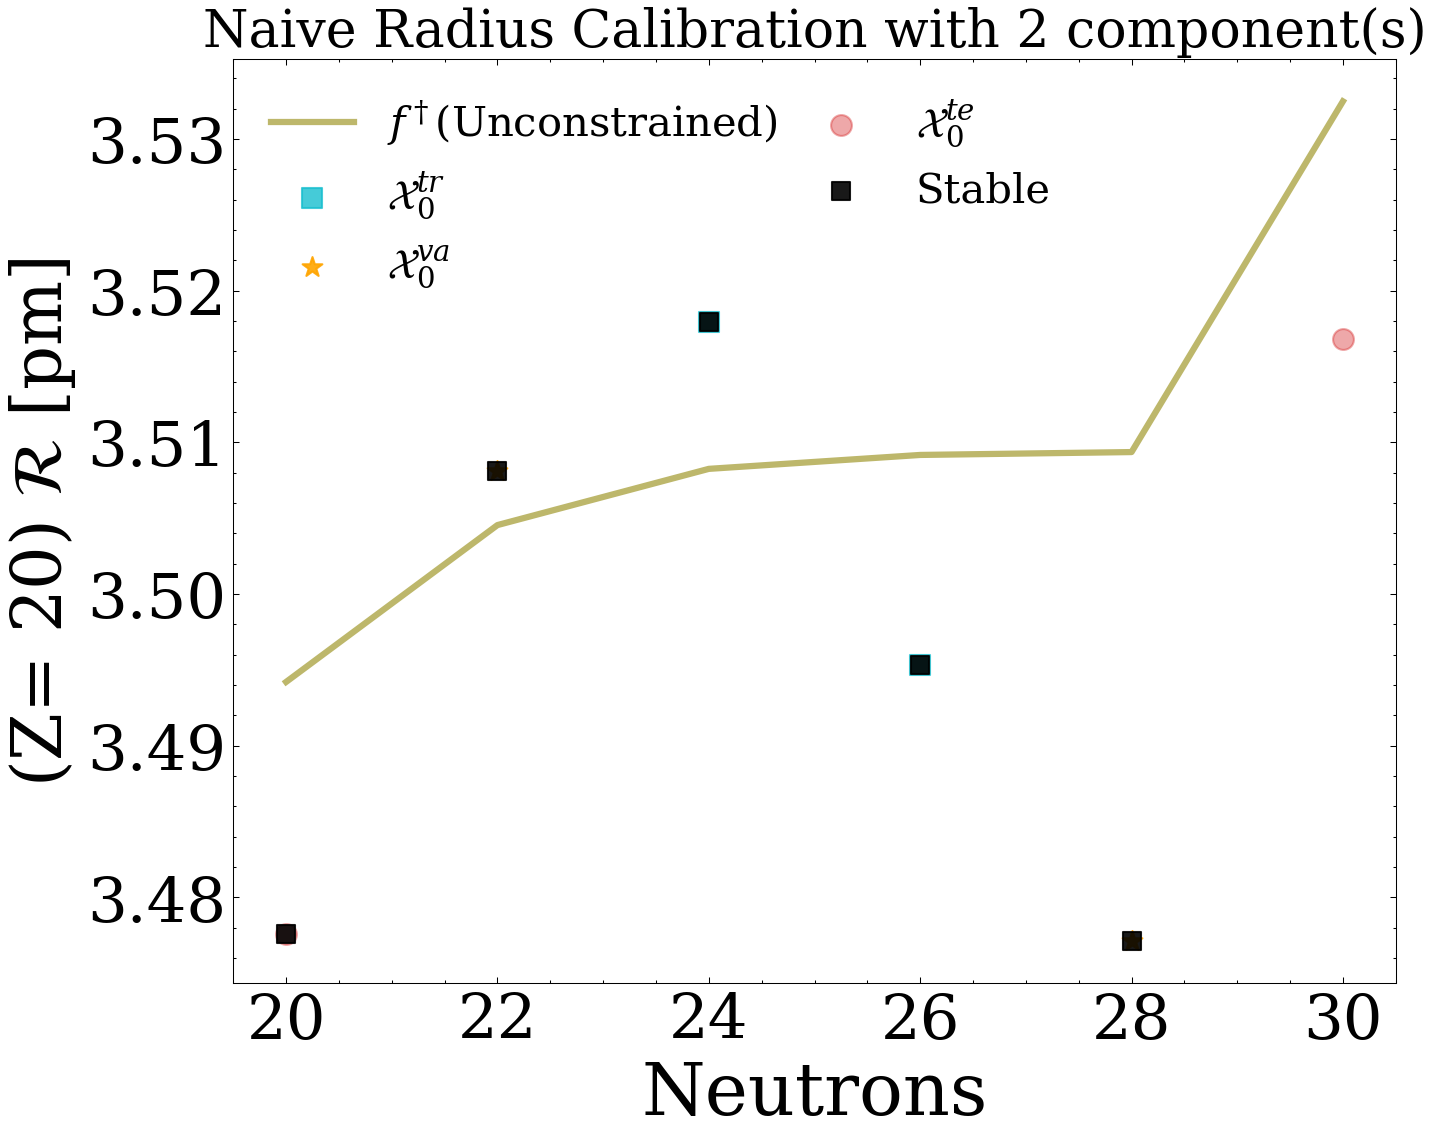

In [151]:
plot_filtered_naive_supermodel(filtered_naive_supermodel_output_radius_list_20, filtered_models_output_radius_list_20, filtered_models_output_radius_stable_20, 20, 'pm', 'R', 'Unconstrained', components_kept )
plt.savefig(f'Plots/Radii data with 20, 28, 50, 82 - added models - new data splitting schemes/BMM predictions/Ca 20 - Radii Naive BMM with {components_kept} components')
plt.show()

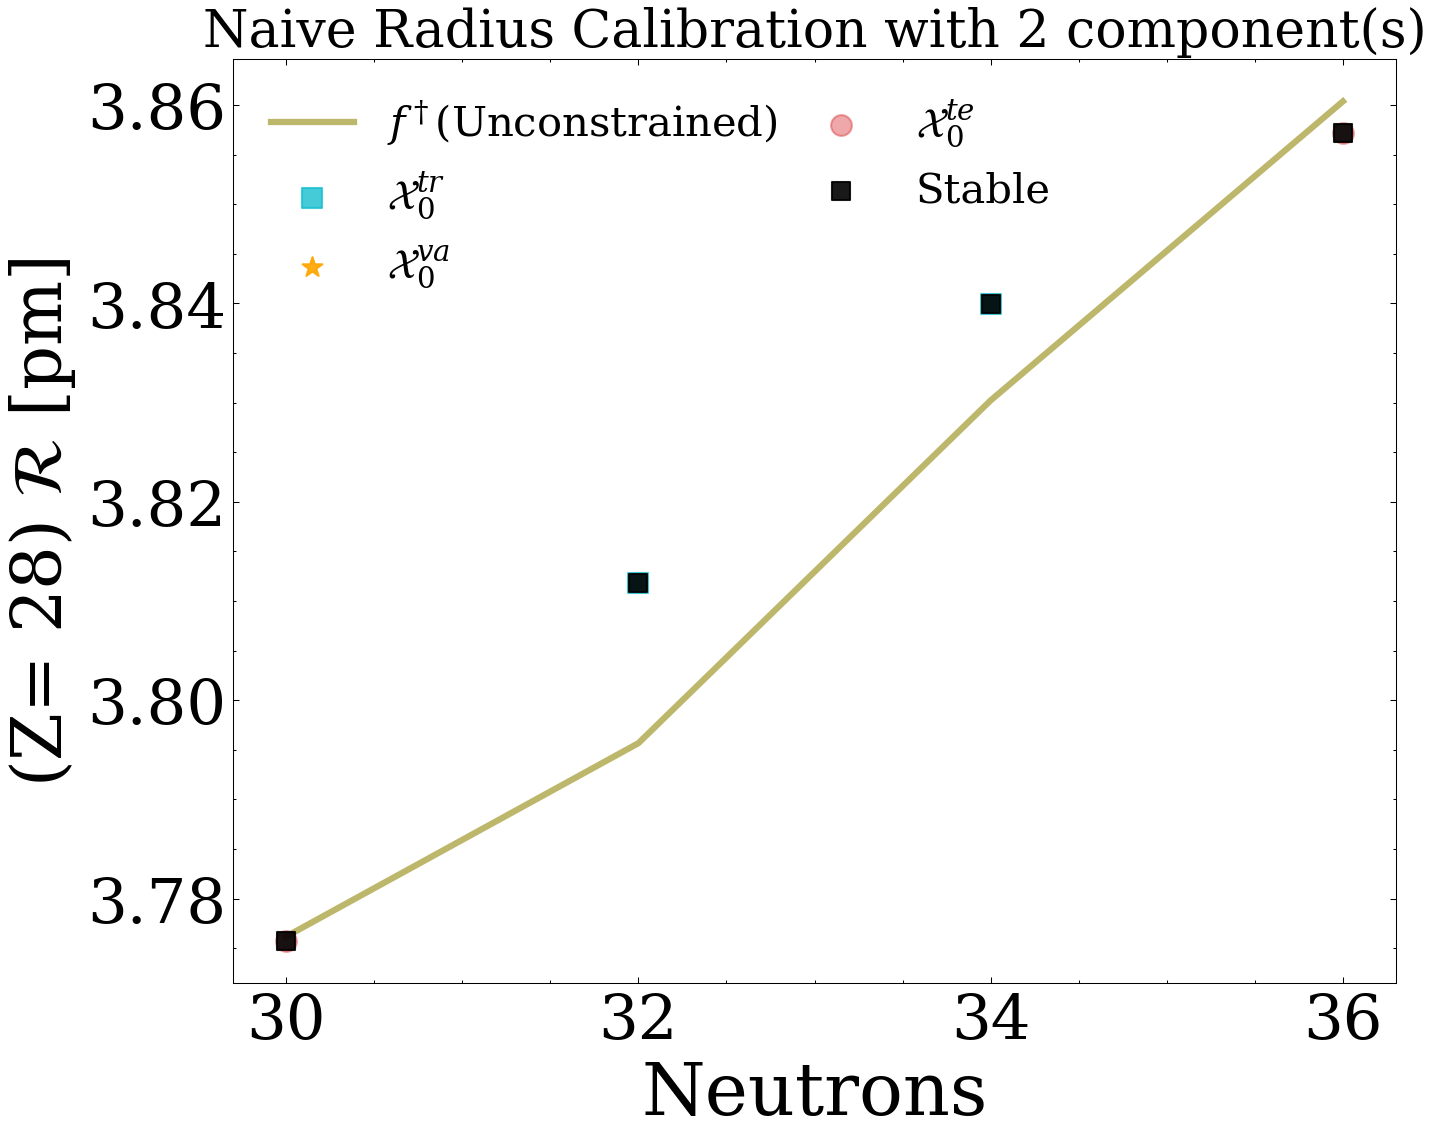

In [152]:
plot_filtered_naive_supermodel(filtered_naive_supermodel_output_radius_list_28, filtered_models_output_radius_list_28, filtered_models_output_radius_stable_28, 28, 'pm', 'R', 'Unconstrained', components_kept )
plt.savefig(f'Plots/Radii Data with 20, 28, 50, 82 - added models - new data splitting schemes/BMM predictions/Ni 28 - Radii Naive BMM with {components_kept} components')
plt.show()

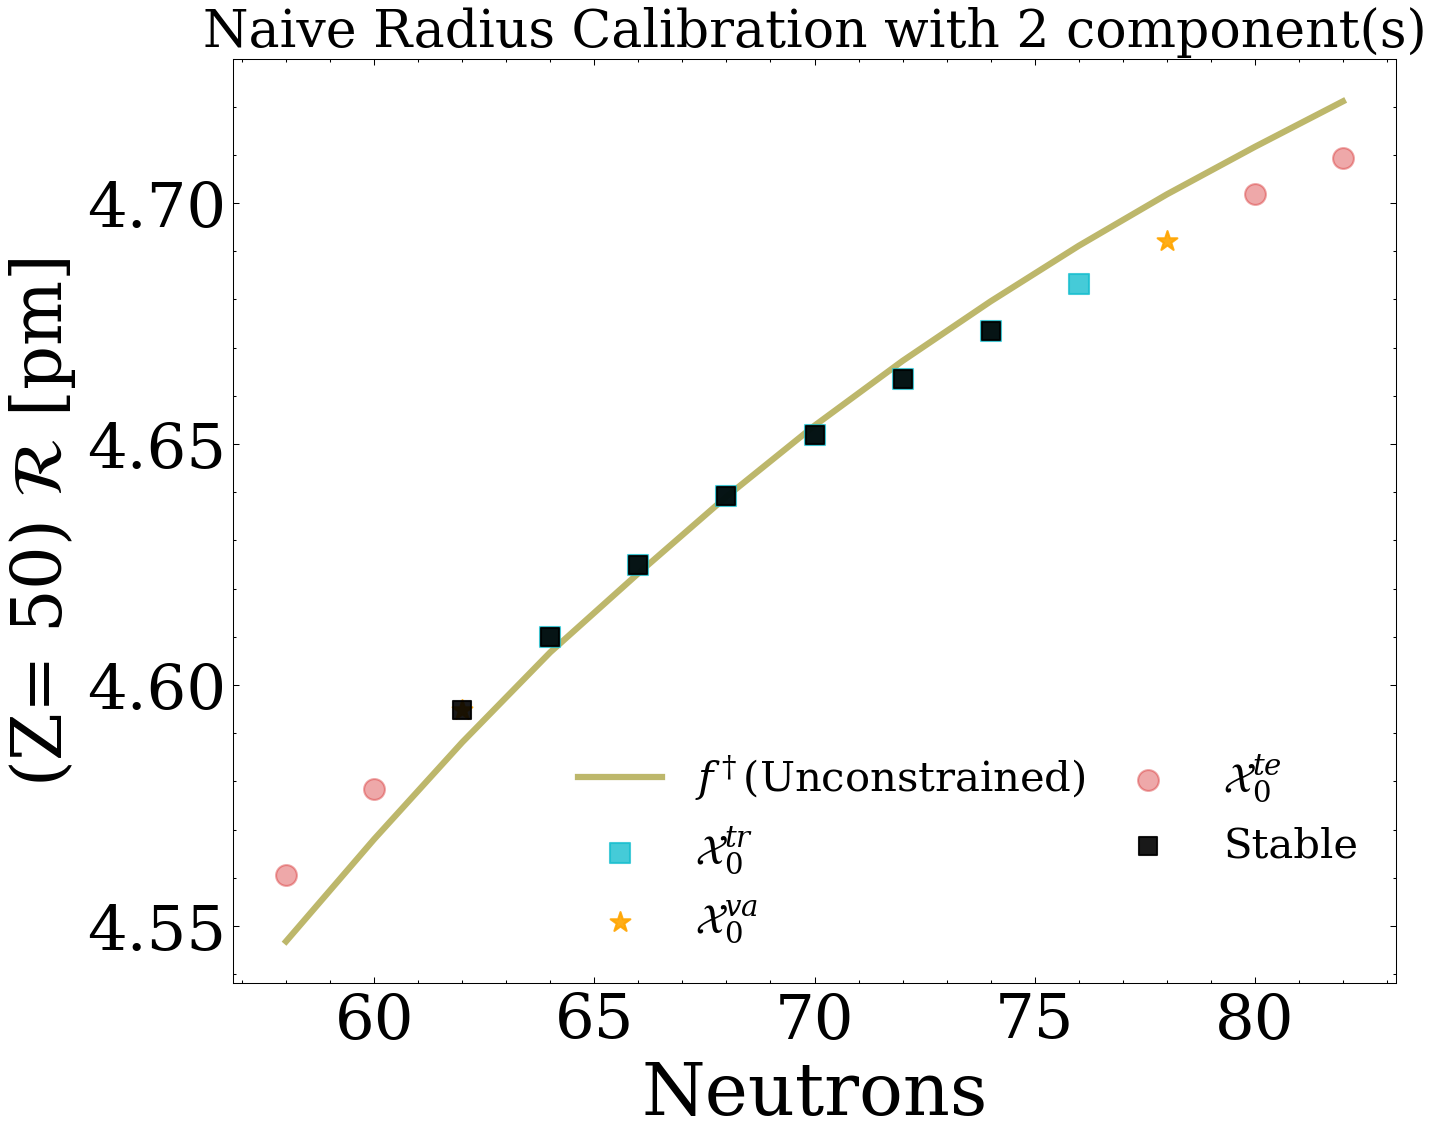

In [153]:
plot_filtered_naive_supermodel(filtered_naive_supermodel_output_radius_list_50, filtered_models_output_radius_list_50, filtered_models_output_radius_stable_50, 50, 'pm', 'R', 'Unconstrained', components_kept )
plt.savefig(f'Plots/Radii Data with 20, 28, 50, 82 - added models - new data splitting schemes/BMM predictions/Zn 50 - Radii Naive BMM with {components_kept} components')
plt.show()

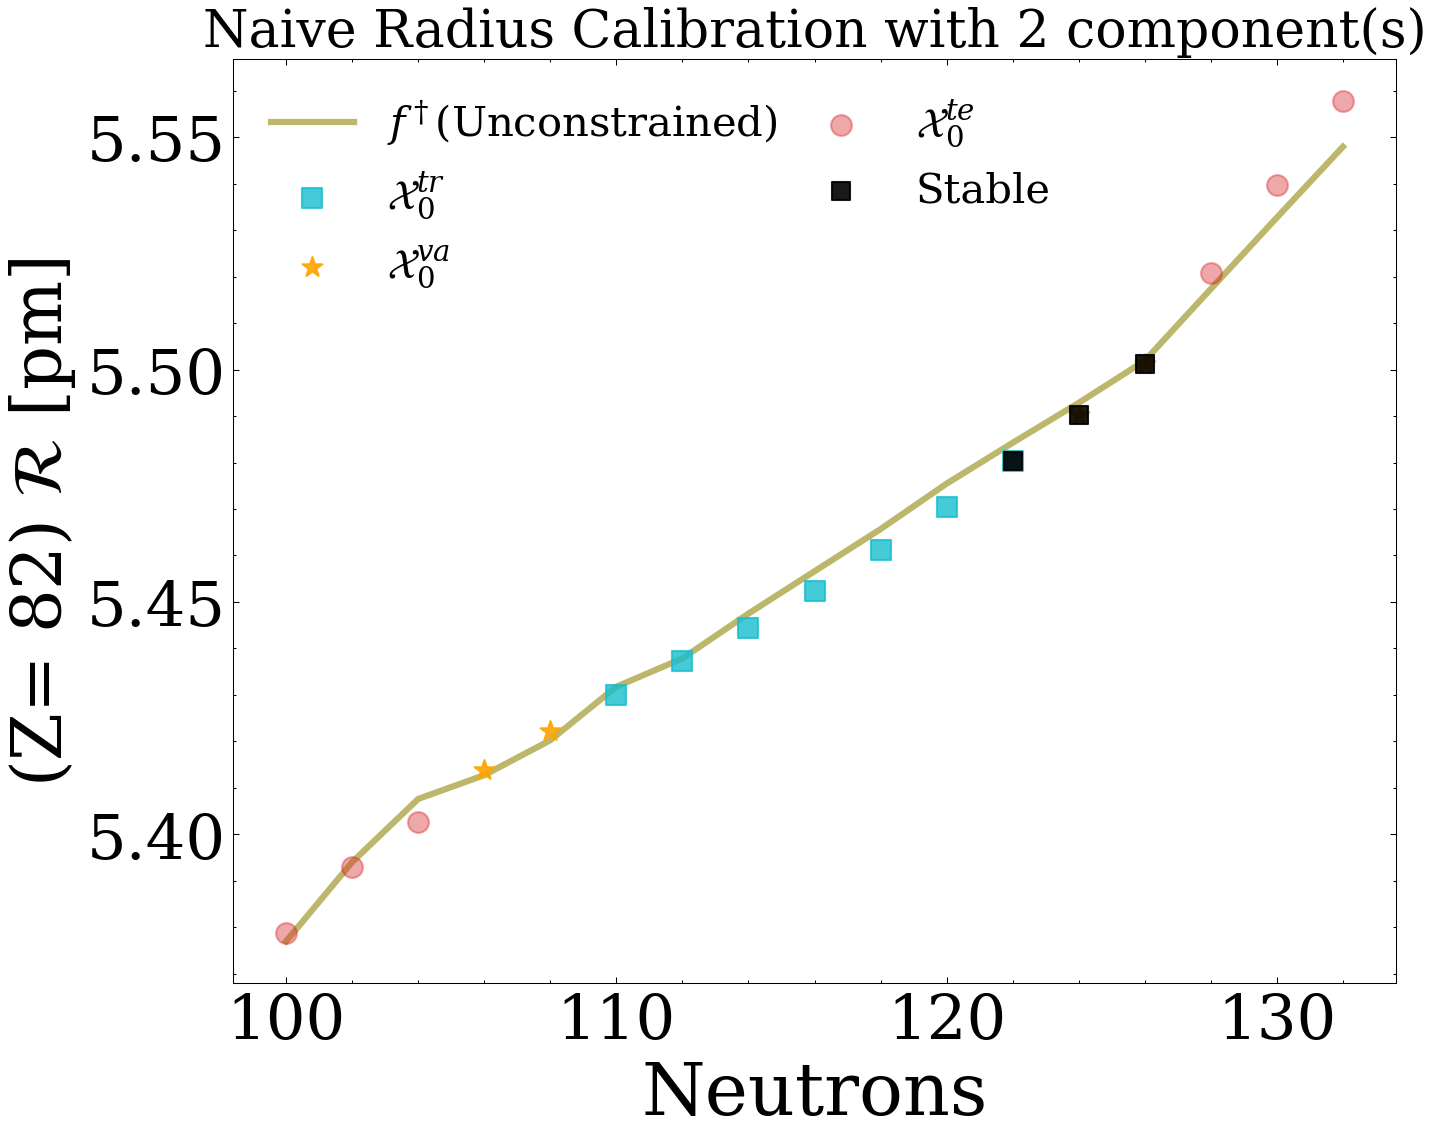

In [154]:
plot_filtered_naive_supermodel(filtered_naive_supermodel_output_radius_list_82, filtered_models_output_radius_list_82, filtered_models_output_radius_stable_82, 82, 'pm', 'R', 'Unconstrained', components_kept )
plt.savefig(f'Plots/Radii Data with 20, 28, 50, 82 - added models - new data splitting schemes/BMM predictions/Pb 82 - Radii Naive BMM with {components_kept} components')
plt.show()

## Let's now perform simple Bayesian Analysis to test the uncertainty band that we can achieve with these new models

In [155]:
X_train = U_hat.copy()

In [164]:
nu0_chosen=1
sigma20_chosen=0.002

In [165]:
def gibbs_sampler(y, X, iterations,prior_info):
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
    b_mean_prior, b_mean_cov, nu0, sigma20  =  prior_info
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), 
    #nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    b_mean_cov_inv=np.linalg.inv(b_mean_cov)
    n = len(y) # We are still taking mass and radius to be the same size
    
    X_T_X=X.T.dot(X)
    X_T_X_inv = np.linalg.inv(X_T_X)

    b_data = X_T_X_inv.dot(X.T).dot(y)

    
    
    supermodel=X.dot(b_data)
    

    residuals = y - supermodel 

    
    
    sigma2 = np.sum(residuals**2) / len(residuals) 
    cov_matrix = sigma2 * X_T_X_inv
    
    samples = []
    
    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data

        
        cov_matrix = np.linalg.inv(X_T_X/sigma2
                                   + b_mean_cov_inv)
        
        mean_vector = cov_matrix.dot(        b_mean_cov_inv.dot(b_mean_prior)+ X.T.dot(y)/sigma2  )
        
        
        b_current = np.random.multivariate_normal(mean_vector, cov_matrix)

        
        
        
        # Sample from the conditional posterior of sigma2 given bs and data
        supermodel=X.dot(b_current)
        
        residuals = y - supermodel 
        
        
        shape_post = (nu0 + n)/2.
        scale_post = (nu0*sigma20 + np.sum(residuals**2))/2.0
        # sigma2 = 1 / np.random.gamma(shape_post, 1/scale_post)
        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
        samples.append(np.append(b_current,np.sqrt(sigma2)))
    


    return np.array(samples)

In [166]:
samples = gibbs_sampler(y_radius,X_train, 50000,[np.full(components_kept,0),np.abs(np.diag(S[:components_kept]**2)), nu0_chosen, sigma20_chosen])

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\congn\AppData\Local\Temp\ipykernel_15012\4282783189.py:2: SyntaxWarning: invalid escape sequence '\s'
  label_global.append(f'$\sigma$')


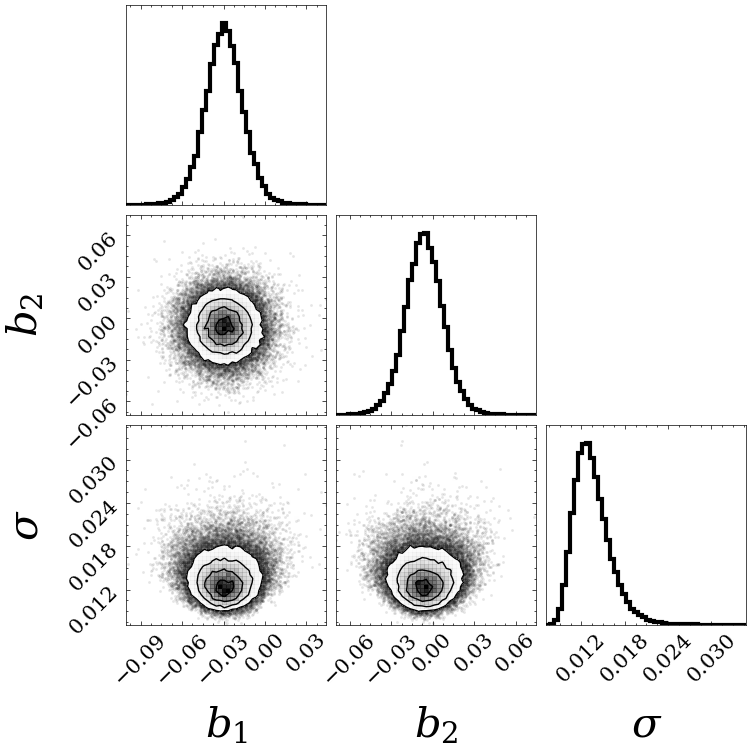

In [167]:
label_global = [f'$b_{i}$' for i in range(1, components_kept+1)]
label_global.append(f'$\sigma$')

plt.rcParams['text.usetex'] = False
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.rc("xtick", labelsize=15)
plt.rc("ytick", labelsize=15)

figure = corner.corner(samples,bins=50, dpi=300, hist_kwargs={"linewidth": 3},
                       labels=label_global, 
                    #    truths=np.append(beta,np.sqrt(sigma_squared)),
                    #    truth_color="r",
                       label_kwargs={"fontsize": 30},labelpad=0.1)
plt.show()

In [168]:
# This code will help us to calculate the weight of the individual models from the weight of the principal components
model_weights = []
for beta in samples:
    model_weights.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights= np.array(model_weights)

In [169]:
filtered_models_output_radius_20 = filtered_models_output_radius_list_20[0]
filtered_model_predictions_radius_20 = filtered_models_output_radius_20.iloc[:,3:-1].values

filtered_models_output_radius_28 = filtered_models_output_radius_list_28[0]
filtered_model_predictions_radius_28 = filtered_models_output_radius_28.iloc[:,3:-1].values

filtered_models_output_radius_50 = filtered_models_output_radius_list_50[0]
filtered_model_predictions_radius_50 = filtered_models_output_radius_50.iloc[:,3:-1].values

filtered_models_output_radius_82 = filtered_models_output_radius_list_82[0]
filtered_model_predictions_radius_82 = filtered_models_output_radius_82.iloc[:,3:-1].values

In [170]:
lower_radius_20, median_radius_20, upper_radius_20 = rndm_m_radius_calculator(model_weights, filtered_model_predictions_radius_20, samples)
lower_radius_82, median_radius_82, upper_radius_82 = rndm_m_radius_calculator(model_weights, filtered_model_predictions_radius_82, samples)
lower_radius_28, median_radius_28, upper_radius_28 = rndm_m_radius_calculator(model_weights, filtered_model_predictions_radius_28, samples)
lower_radius_50, median_radius_50, upper_radius_50 = rndm_m_radius_calculator(model_weights, filtered_model_predictions_radius_50, samples)

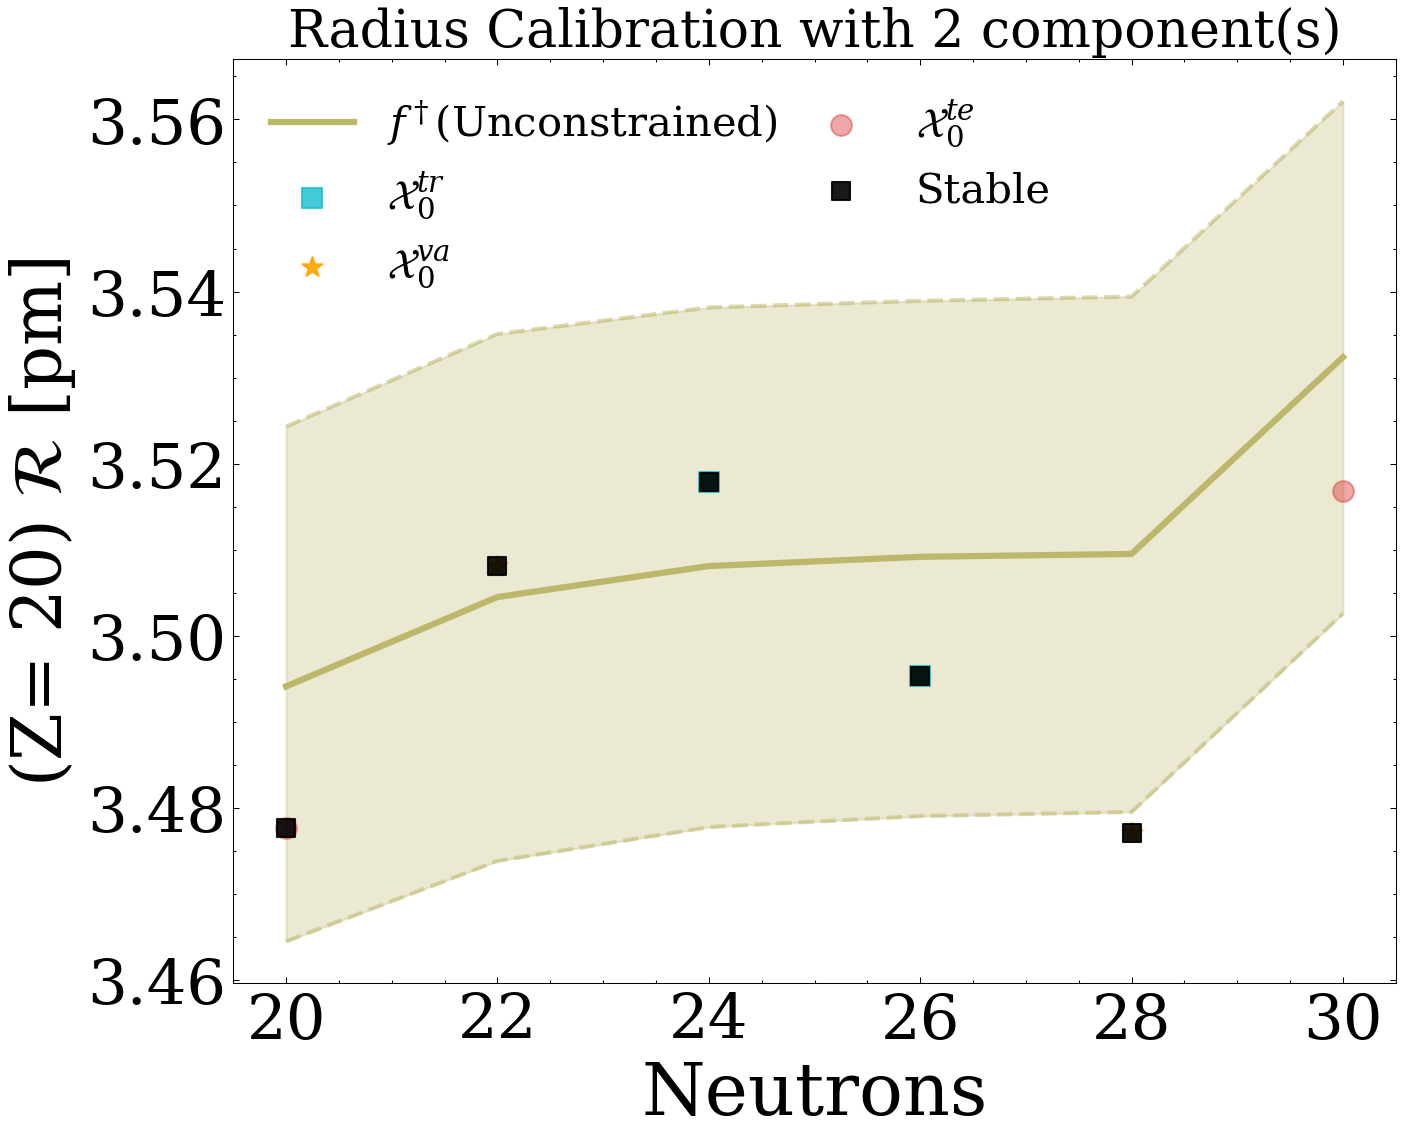

In [171]:
supermodel_predictions_radius_range_20 = [lower_radius_20, median_radius_20, upper_radius_20]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_20, filtered_models_output_radius_list_20, filtered_models_output_radius_stable_20, 20, 'pm', 'R', 'Unconstrained', components_kept )
plt.savefig(f'Plots/Radii Data with 20, 28, 50, 82 - added models - new data splitting schemes/BMM Radii/Ca 20 - Unconstrained BMM with {components_kept} components')
plt.show()

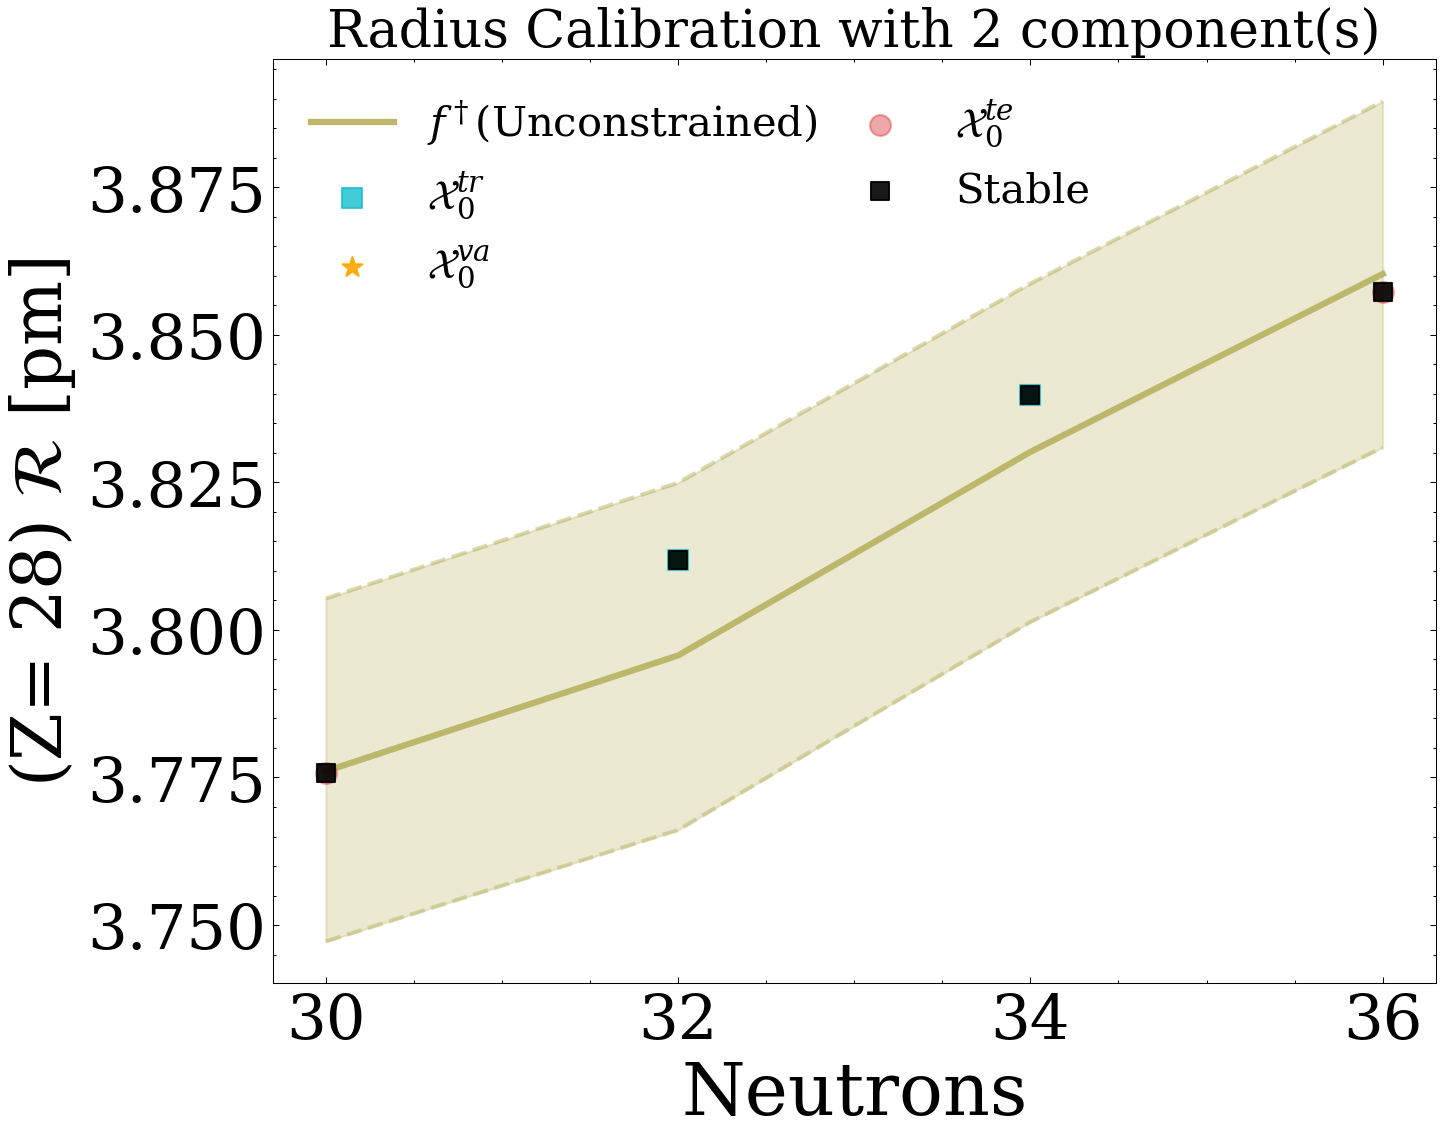

In [172]:
supermodel_predictions_radius_range_28 = [lower_radius_28, median_radius_28, upper_radius_28]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_28, filtered_models_output_radius_list_28, filtered_models_output_radius_stable_28, 28, 'pm', 'R', 'Unconstrained', components_kept )
plt.savefig(f'Plots/Radii Data with 20, 28, 50, 82 - added models - new data splitting schemes/BMM Radii/Ni 28 - Unconstrained BMM with {components_kept} components')
plt.show()

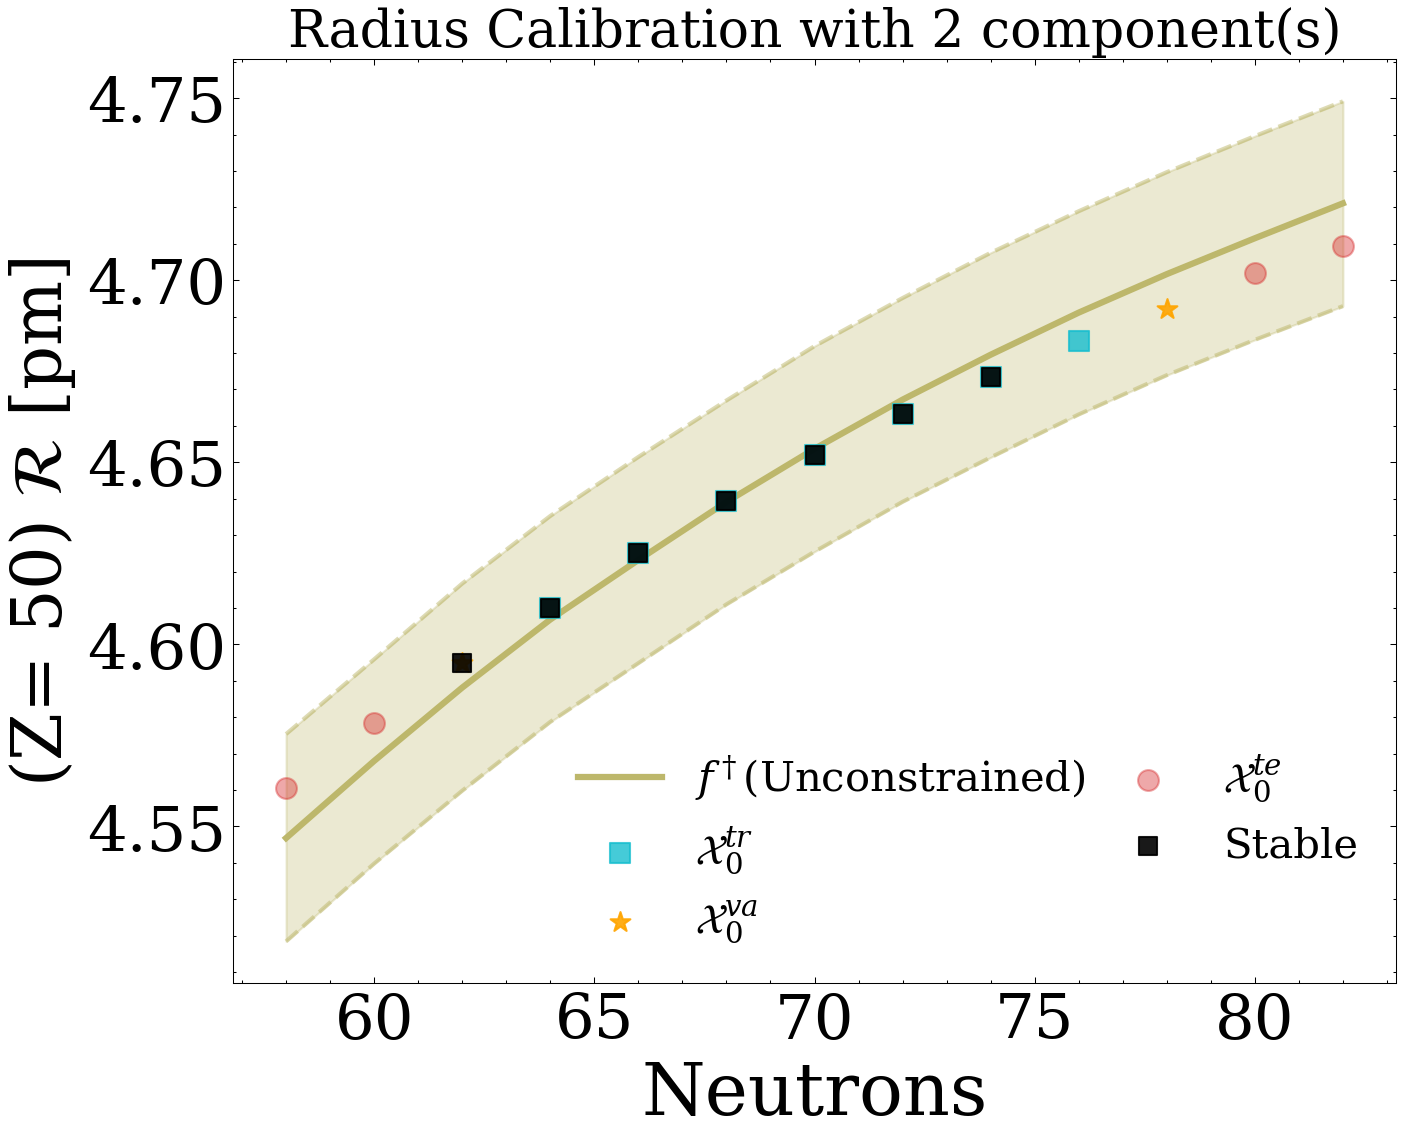

In [173]:
supermodel_predictions_radius_range_50 = [lower_radius_50, median_radius_50, upper_radius_50]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_50, filtered_models_output_radius_list_50, filtered_models_output_radius_stable_50, 50, 'pm', 'R', 'Unconstrained', components_kept )
plt.savefig(f'Plots/Radii Data with 20, 28, 50, 82 - added models - new data splitting schemes/BMM Radii/Zn 50 - Unconstrained BMM with {components_kept} components')
plt.show()

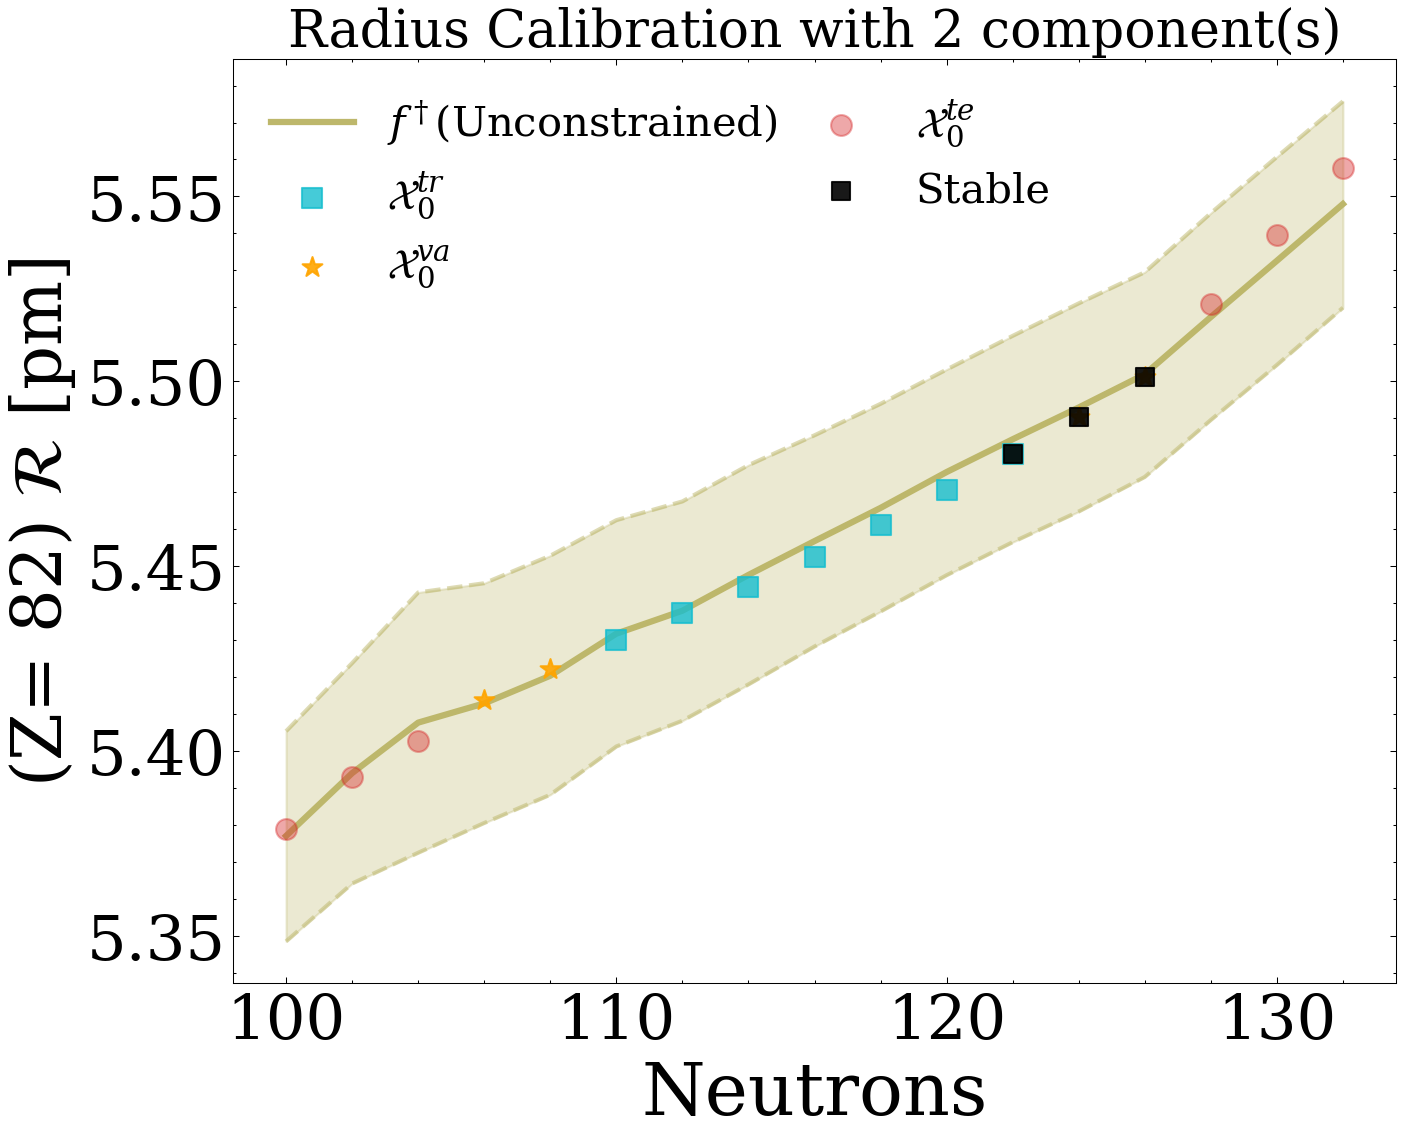

In [174]:
supermodel_predictions_radius_range_82 = [lower_radius_82, median_radius_82, upper_radius_82]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_82, filtered_models_output_radius_list_82, filtered_models_output_radius_stable_82, 82, 'pm', 'R', 'Unconstrained', components_kept )
plt.savefig(f'Plots/Radii Data with 20, 28, 50, 82 - added models - new data splitting schemes/BMM Radii/Pb 82 - Unconstrained BMM with {components_kept} components')
plt.show()

## Let's see what happened if we add an isospin model that accounts for some effect not yet captured in the previous models

In [155]:
# models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
#         'UNEDF1', ]#Here I am copying all the models with Charge Raidus and Masses
# key_list = models_selected

In [53]:
#Let's create a dataframe that contains all the model predictions
selected_models_data_sets_radius = selected_models_data_sets_extraction(models_data_sets, models_selected, filtered_NZ_df, 'ChRad')

# This is for the radius data
truth_CR_df = a
selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, truth_CR_df[['N', 'Z',  'radius_val']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius.rename(columns = {'radius_val' : 'truth'}, inplace = True)
cols_radius = list(selected_models_data_sets_radius.keys())
# The next 2 lines help you to transition the truth column to the start of the dataframe
cols_radius.remove('truth')
cols_radius.insert(2, 'truth')
selected_models_data_sets_radius = selected_models_data_sets_radius[cols_radius]
selected_models_data_sets_radius = selected_models_data_sets_radius.copy().dropna().reset_index(drop = True)

In [54]:
def isospin_radii_model(A, N, Z, r_a, b ,c):
    return r_a * A** (1/3) * (1 - b * (N - Z)/A + c/A)

In [55]:
isospin_radii_model_dataset = {}
A_radii = selected_models_data_sets_radius['N'] + selected_models_data_sets_radius['Z']
isospin_radii_model_dataset['A^(1/3)'] = A_radii**(1/3)
isospin_radii_model_dataset['(N-Z)/A'] = -A_radii**(1/3) * (selected_models_data_sets_radius['N'] - selected_models_data_sets_radius['Z'])/A_radii
isospin_radii_model_dataset['c/A'] = A_radii ** (1/3)/A_radii

In [56]:
isospin_radii_model_dataset = pd.DataFrame(isospin_radii_model_dataset)
isospin_radii_model_dataset

,A^(1/3),(N-Z)/A,c/A
0,2.519842,-0.000000,0.157490
1,2.620741,-0.291193,0.145597
2,2.620741,0.291193,0.145597
3,2.714418,-0.000000,0.135721
4,2.802039,-0.254731,0.127365
...,...,...,...
340,6.248800,-1.434151,0.025610
341,6.231680,-1.287537,0.025751
342,6.248800,-1.331711,0.025610
343,6.265827,-1.375425,0.025471


In [57]:
isospin_radii_model_params = super_params(isospin_radii_model_dataset.values, selected_models_data_sets_radius['truth'])

In [58]:
r_a = isospin_radii_model_params[0]
b = isospin_radii_model_params[1]/isospin_radii_model_params[0]
c = isospin_radii_model_params[2]/isospin_radii_model_params[0]

In [59]:
selected_models_data_sets_radius['isospin'] = isospin_radii_model(A_radii,\
                                                                  selected_models_data_sets_radius['N'], selected_models_data_sets_radius['Z'], r_a, b ,c)

### In this notebook we only want to perform our analysis on the only 4 isotopic chains: Z = 20, 28, 50, 82. Let's create a new dataframe that only contains these 4 istopic chains

In [60]:
selected_models_data_sets_radius_4_isotopic_chains = selected_models_data_sets_radius.copy()[selected_models_data_sets_radius.copy()['Z'].isin([20,28,50,82])]

In [61]:
selected_models_data_sets_radius_4_isotopic_chains

,N,Z,truth,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,isospin
23,20,20,3.4776,3.465,3.425,3.457,3.470,3.508447,3.530085,3.508657,3.501743,3.501457,3.483709,3.453726
24,22,20,3.5081,3.469,3.435,3.463,3.468,3.513530,3.536751,3.515920,3.505667,3.503420,3.487649,3.478089
25,24,20,3.5179,3.474,3.447,3.472,3.469,3.517619,3.543701,3.522998,3.510855,3.505047,3.494824,3.502652
26,26,20,3.4953,3.479,3.459,3.481,3.472,3.523560,3.552996,3.531629,3.519449,3.511087,3.505986,3.527332
27,28,20,3.4771,3.481,3.468,3.490,3.474,3.533390,3.564701,3.543605,3.531471,3.521495,3.520582,3.552062
28,30,20,3.5168,3.512,3.496,3.511,3.498,3.547856,3.578512,3.559659,3.546039,3.534937,3.536964,3.576789
39,30,28,3.7757,3.758,3.817,3.777,3.740,3.796573,3.834224,3.813072,3.800095,3.800082,3.787199,3.826607
40,32,28,3.8118,3.804,3.838,3.827,3.768,3.812996,3.848746,3.829694,3.817273,3.816437,3.816168,3.847439
41,34,28,3.8399,3.833,3.845,3.826,3.794,3.835217,3.868574,3.861478,3.845102,3.840018,3.843278,3.868294
42,36,28,3.8572,3.838,3.829,3.846,3.818,3.860132,3.891267,3.880534,3.865460,3.866367,3.863380,3.889147


In [62]:
# isospin_radii_model_dataset = {}
# A_radii = selected_models_data_sets_radius_4_isotopic_chains['N'] + selected_models_data_sets_radius_4_isotopic_chains['Z']
# isospin_radii_model_dataset['A^(1/3)'] = A_radii**(1/3)
# isospin_radii_model_dataset['(N-Z)/A'] = -A_radii**(1/3) * (selected_models_data_sets_radius_4_isotopic_chains['N'] - selected_models_data_sets_radius_4_isotopic_chains['Z'])/A_radii
# isospin_radii_model_dataset['c/A'] = A_radii ** (1/3)/A_radii

In [63]:
# isospin_radii_model_dataset = pd.DataFrame(isospin_radii_model_dataset)
# isospin_radii_model_dataset

In [64]:
# isospin_radii_model_params = super_params(isospin_radii_model_dataset.values, selected_models_data_sets_radius_4_isotopic_chains['truth'])

In [65]:
# r_a = isospin_radii_model_params[0]
# b = isospin_radii_model_params[1]/isospin_radii_model_params[0]
# c = isospin_radii_model_params[2]/isospin_radii_model_params[0]

In [66]:
# selected_models_data_sets_radius_4_isotopic_chains['isospin'] = isospin_radii_model(A_radii,\
#                                                                   selected_models_data_sets_radius_4_isotopic_chains['N'], selected_models_data_sets_radius_4_isotopic_chains['Z'], r_a, b ,c)

Since we now have the dataset that we want, let's see what happen if we perform the usual analysis

In [67]:
filtered_NZ_df_radius = selected_models_data_sets_radius_4_isotopic_chains[['N', 'Z']]
filtered_NZ_radius = np.array(filtered_NZ_df_radius)
Full_set_radius = filtered_NZ_radius.copy()

In [68]:
stable_coordinates_df = pd.DataFrame({'N' : stable_coordinates.T[0], 'Z' : stable_coordinates.T[1]})
stable_coordinates_radius_df = pd.merge(filtered_NZ_df_radius, stable_coordinates_df, how = 'inner')
stable_coordinates_radius = stable_coordinates_radius_df.values

In [69]:
#Traditional way with stable coordinates to seperate our data points for nuclei - radius data sets

distance1=1.75
distance2=2.5

training_set_radius, validation_set_radius, test_set_radius, train_coordinates_radius, validation_coordinates_radius,test_coordinates_radius=separate_points_distance_allSets(filtered_NZ_radius, stable_coordinates, distance1,distance2)

In [70]:
models_output_radius_list = models_output_extraction(selected_models_data_sets_radius_4_isotopic_chains, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
[models_output_radius, models_output_radius_train, models_output_radius_validation, models_output_radius_test] = models_output_radius_list

models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1', 'isospin']
key_list = models_selected

model_predictions_radius=models_output_radius[key_list].values
model_predictions_radius_train=models_output_radius_train[key_list].values
model_predictions_radius_validation=models_output_radius_validation[key_list].values
model_predictions_radius_test=models_output_radius_test[key_list].values
model_predictions_radius_list = [model_predictions_radius, model_predictions_radius_train, model_predictions_radius_validation, model_predictions_radius_test]

predictions_mean_radius= np.mean(model_predictions_radius, axis=1)
predictions_mean_radius_train= np.mean(model_predictions_radius_train, axis=1)
predictions_mean_radius_validation= np.mean(model_predictions_radius_validation, axis=1)
predictions_mean_radius_test= np.mean(model_predictions_radius_test, axis=1)

predictions_mean_radius_df = pd.DataFrame({'N' : filtered_NZ_radius.T[0], 'Z' : filtered_NZ_radius.T[1], 'PC_0' : predictions_mean_radius})

In [71]:
centering_data = True
if centering_data:
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,None]
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train.reshape(167,1)
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,np.newaxis]

[2.65047352e-01 1.33572144e-01 7.79736168e-02 2.37862279e-02
 2.13751270e-02 1.78258779e-02 1.60423285e-02 1.14181664e-02
 9.07228663e-03 3.23175148e-03 4.39835592e-15]


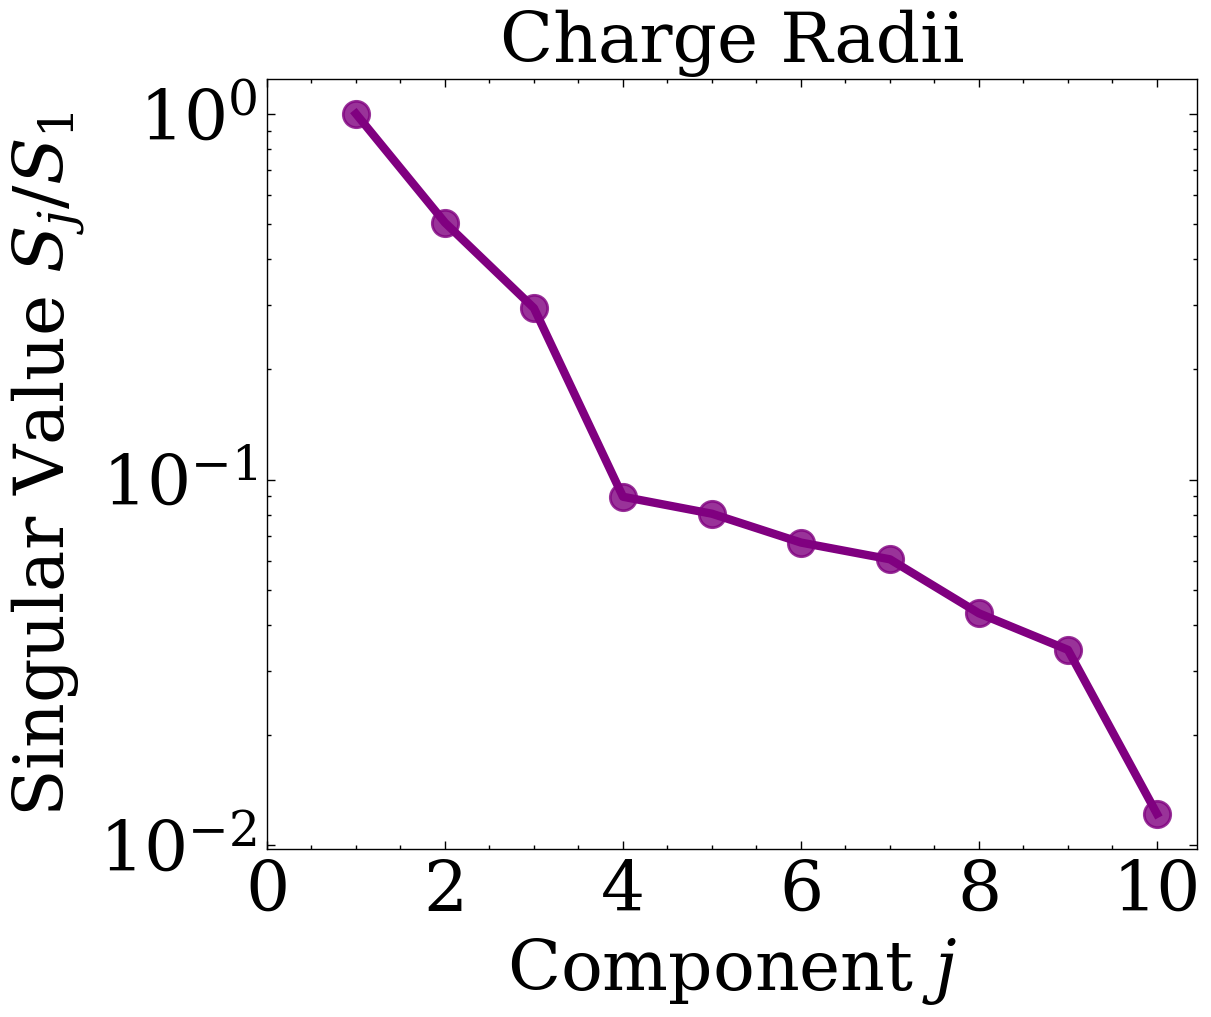

In [72]:
U, S, Vt = np.linalg.svd(model_predictions_radius_train_processed)

print(S)

plt.rc("xtick", labelsize = 25)
plt.rc("ytick", labelsize = 25)
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize = (6,5), dpi = 200)

ax.scatter(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", alpha = 0.8, s = 90, marker = 'o')
ax.plot(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", linewidth = 3)

ax.set_xticks([0,2,4,6,8,10])
plt.xlabel("Component $j$", fontsize = 25)
plt.ylabel("Singular Value $S_j/S_1$", fontsize = 25)
plt.yscale("log")
plt.title('Charge Radii', fontsize = 25)
# plt.savefig('Plots/Radii data with 20, 28, 50, 82/Singular values/Singular Values - locally fitted isospin model included.png')
plt.show()

In [73]:
components_kept = 9
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized=np.array([Vt[i] for i in range(components_kept)])
# Vt_hat = np.array([Vt[i] for i in range(components_kept)])

models_PC_radius = models_PC_output(Vt_hat, model_predictions_radius, predictions_mean_radius, models_output_radius)
models_PC_radius_train = models_PC_output(Vt_hat, model_predictions_radius_train, predictions_mean_radius_train, models_output_radius_train)
models_PC_radius_validation = models_PC_output(Vt_hat, model_predictions_radius_validation, predictions_mean_radius_validation, models_output_radius_validation)
models_PC_radius_test = models_PC_output(Vt_hat, model_predictions_radius_test, predictions_mean_radius_test, models_output_radius_test)

In [74]:
super_params_train = super_params(model_predictions_radius_train, models_output_radius_train['truth'])
supermodel_radius_train = super_params_train.dot(model_predictions_radius_train.T)
supermodel_radius_validation = super_params_train.dot(model_predictions_radius_validation.T)
supermodel_radius_test = super_params_train.dot(model_predictions_radius_test.T)
supermodel_radius_full = super_params_train.dot(model_predictions_radius.T)

supermodel_residuals_radius_train=supermodel_radius_train-models_output_radius_train['truth'].tolist()
supermodel_residuals_radius_validation= supermodel_radius_validation-models_output_radius_validation['truth'].tolist()
supermodel_residuals_radius_test = supermodel_radius_test-models_output_radius_test['truth'].tolist()
supermodel_residuals_radius_full = supermodel_radius_full-models_output_radius['truth'].tolist()

supermodel_sigma_radius_train=np.sqrt(np.sum(supermodel_residuals_radius_train**2) / len(supermodel_residuals_radius_train) )
supermodel_sigma_radius_validation=np.sqrt(np.sum(supermodel_residuals_radius_validation**2) / len(supermodel_residuals_radius_validation) )
supermodel_sigma_radius_test=np.sqrt(np.sum(supermodel_residuals_radius_test**2) / len(supermodel_residuals_radius_test) )
supermodel_sigma_radius_full=np.sqrt(np.sum(supermodel_residuals_radius_full**2) / len(supermodel_residuals_radius_full) )

In [75]:
if centering_data:
    s_radius_validation=[np.linalg.norm(np.array(models_output_radius_validation["truth"].tolist())-predictions_mean_radius_validation)/np.sqrt(len(predictions_mean_radius_validation))]
    s_radius_test=[np.linalg.norm(np.array(models_output_radius_test["truth"].tolist())-predictions_mean_radius_test)/np.sqrt(len(predictions_mean_radius_test))]
    s_radius_train=[np.linalg.norm(np.array(models_output_radius_train["truth"].tolist())-predictions_mean_radius_train)/np.sqrt(len(predictions_mean_radius_train))]
    s_radius_all=[np.linalg.norm(np.array(models_output_radius["truth"].tolist())-predictions_mean_radius)/np.sqrt(len(predictions_mean_radius))]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator(i, model_predictions_radius_train, predictions_mean_radius_train, models_output_radius_train, models_output_radius_list, model_predictions_radius_list, U, S, Vt)
        s_radius_all.append(res[0])
        s_radius_train.append(res[1])
        s_radius_validation.append(res[2])
        
        s_radius_test.append(res[3])

[0.11360346 0.12616615 0.11108182 0.13004293 0.0808649  0.04747411
 0.06609566 0.08593495 0.08591058 0.09291236 0.05991309]
0.013481528803018455
[ 0.10657919  0.02936939  0.08125606  0.1904501   0.14415015  0.07197632
  0.08495117  0.14551161  0.12480431  0.10445358 -0.08350187]
0.011823466564076056
[ 0.10652993  0.02947368  0.08125347  0.19037233  0.14415061  0.07200261
  0.08495943  0.14555755  0.12482062  0.10445261 -0.08357285]
0.011823466191504884
[ 0.81801161 -0.12108577  0.41312587 -0.21853497 -0.12798642  0.32178414
  0.30298935 -0.13564606  0.12250778  0.05320296 -0.42836851]
0.010214433211585494
[ 0.80884731 -0.03995807  0.37606288 -0.1219708  -0.04439443  0.45466288
  0.31033291 -0.28310016  0.11630926 -0.12571738 -0.45107439]
0.010100355706769594
[ 0.58462744 -0.18975632  0.96290075 -0.27615096  0.24102704  0.1269775
  0.47497349 -0.26613426  0.27186634 -0.51396015 -0.41637088]
0.009385194600333624
[ 0.9398304  -0.03467876  0.29247202 -0.35117814  0.28102135 -0.45420494
  1

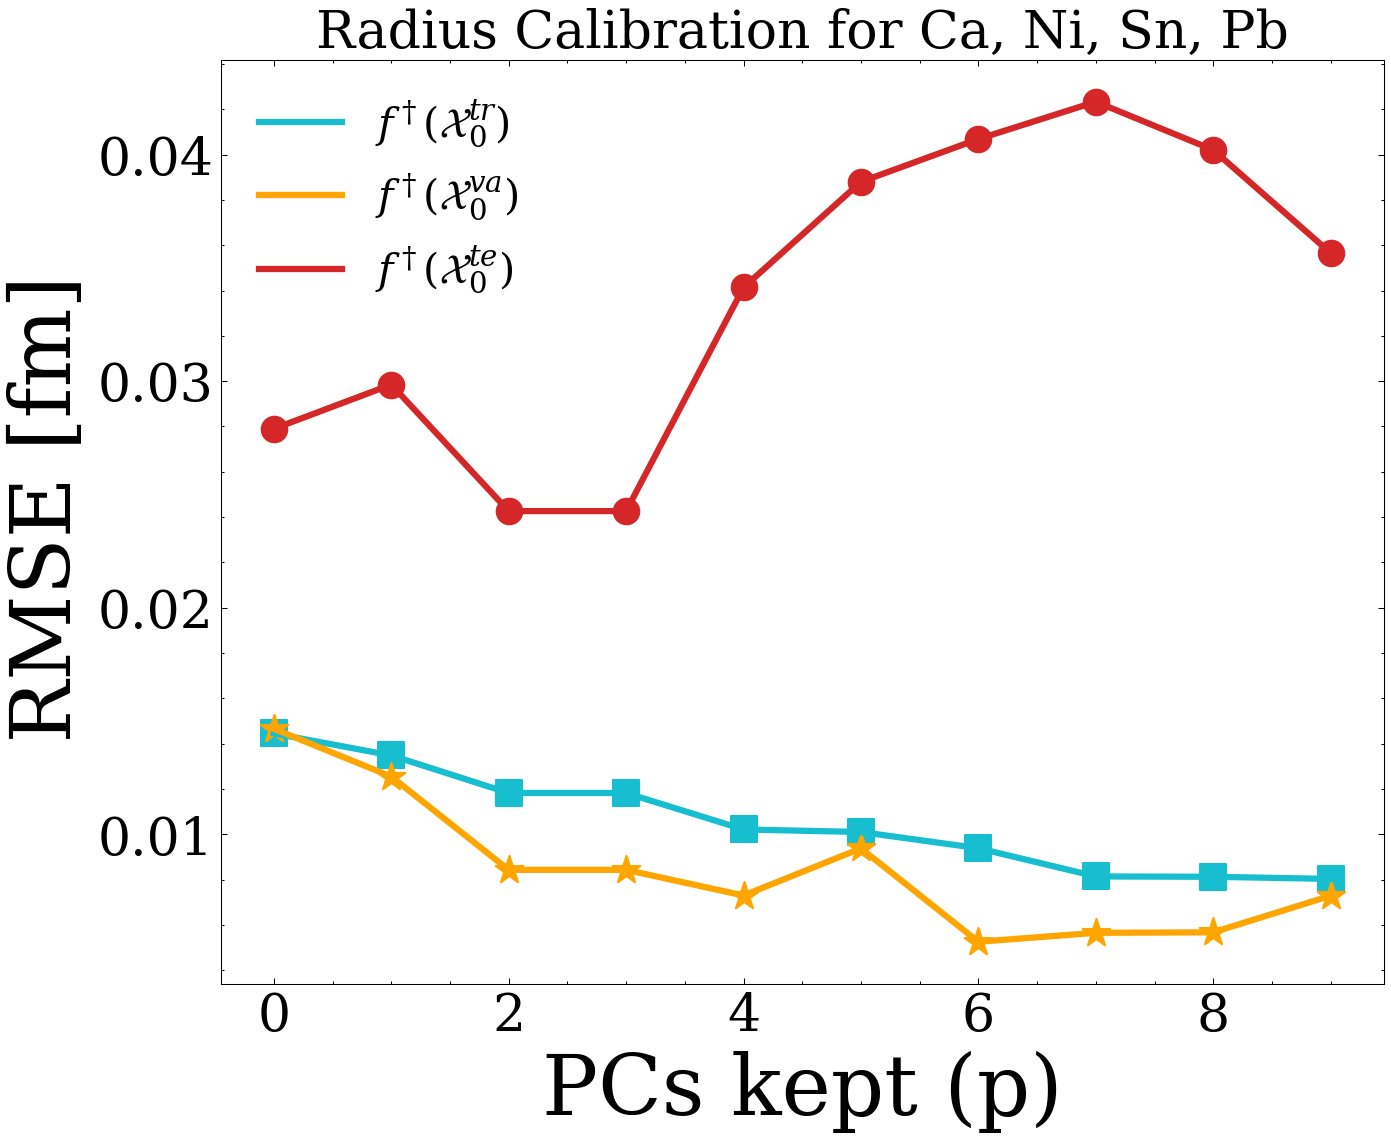

In [76]:
plt.rc("xtick", labelsize=25)
plt.rc("ytick", labelsize=25)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_radius_train[:-1])), s_radius_train[:-1],color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_radius_train[:-1])), s_radius_train[:-1],color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_radius_validation[:-1])), s_radius_validation[:-1],color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_radius_validation[:-1])), s_radius_validation[:-1],color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_radius_test[:-1])), s_radius_test[:-1],color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_radius_test[:-1])), s_radius_test[:-1],color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=supermodel_sigma_radius_train,color=color_train,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)
# ax.axhline(y=supermodel_sigma_radius_validation,color=color_validation,label="BMC$(\mathcal{X}_0^{va})$",linestyle='dashed',linewidth=3)
# ax.axhline(y=supermodel_sigma_radius_test,color=color_test,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'PCs kept (p)',fontsize=40)
ax.set_ylabel(r' RMSE [fm]',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=20)
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.title('Radius Calibration for Ca, Ni, Sn, Pb', fontsize = 25)
# plt.savefig('Plots/Radii data with 20, 28, 50, 82/RMSE decays/Radius RMSE decays - locally fitted isospin model included.png')
# plt.legend(fontsize=30)
plt.show()

In [77]:
models_RMSE_radius_train, models_RMSE_radius_validation, models_RMSE_radius_test, models_RMSE_radius_full = models_RMSE_radius_calculator(models_selected)

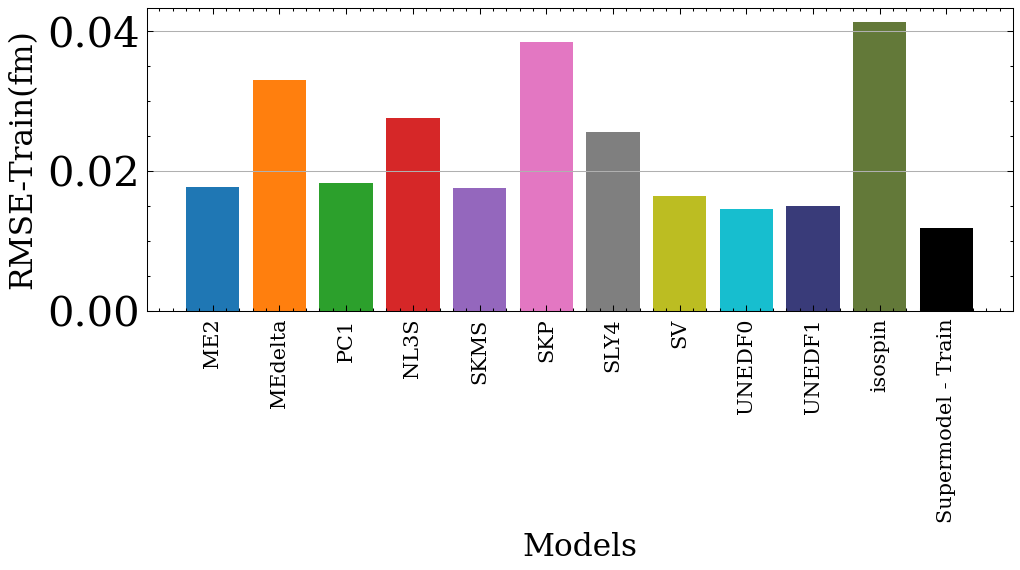

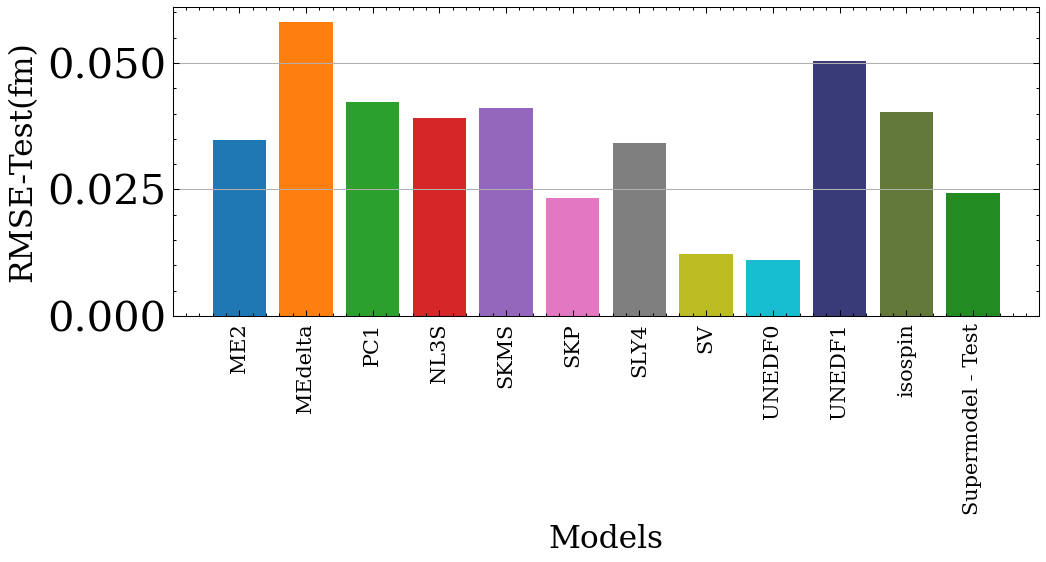

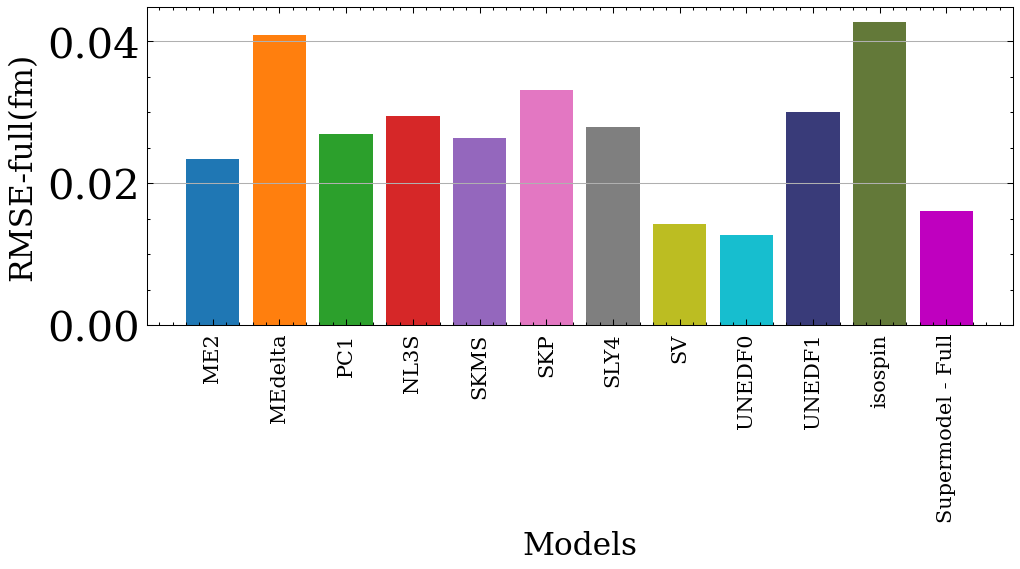

In [79]:
y_max = 0.05

plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
plt.figure(figsize=(7, 4),dpi=150)
i = 0
for model in models_selected:
    plt.bar(model, models_RMSE_radius_train[i], color = colors[i])
    i+=1
# plt.bar('Supermodel - Full', supermodel_sigma_radius_train, color = 'm')
plt.bar('Supermodel - Train', s_radius_train[3], color = 'k')
# plt.bar('Supermodel - Test', supermodel_sigma_radius_train_test, color = 'forestgreen')

plt.xlabel('Models',fontsize=15)
plt.ylabel('RMSE-Train(fm)',fontsize=15)
# plt.ylim(0,y_max)
plt.xticks(fontsize=10,rotation='vertical')
plt.grid(axis='y')
plt.tight_layout()
# plt.savefig('Plots/Radii data with 20, 28, 50, 82/Models RMSE/Models RMSE - train - Ca, Ni, Sn, Pb - locally fitted isospin model included.png')
plt.show()

#############################
# test region ###############

plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
plt.figure(figsize=(7, 4),dpi=150)
i = 0
for model in models_selected:
    plt.bar(model, models_RMSE_radius_test[i], color = colors[i])
    i+=1
# plt.bar('Supermodel - Full', supermodel_sigma_radius_test, color = 'm')
# plt.bar('Supermodel - Train', supermodel_sigma_radius_test_train, color = 'k')
plt.bar('Supermodel - Test', s_radius_test[3], color = 'forestgreen')

plt.xlabel('Models',fontsize=15)
plt.ylabel('RMSE-Test(fm)',fontsize=15)
# plt.ylim(0,y_max)
plt.xticks(fontsize=10,rotation='vertical')
plt.grid(axis='y')
plt.tight_layout()
# plt.savefig('Plots/Radii data with 20, 28, 50, 82/Models RMSE/Models RMSE - test - Ca, Ni, Sn, Pb - locally fitted isospin model included.png')
plt.show()

##############################
# full region ################

plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
plt.figure(figsize=(7, 4),dpi=150)
i = 0
for model in models_selected:
    plt.bar(model, models_RMSE_radius_full[i], color = colors[i])
    i+=1
plt.bar('Supermodel - Full', s_radius_all[3], color = 'm')
# plt.bar('Supermodel - Train', supermodel_sigma_radius_test_train, color = 'k')
# plt.bar('Supermodel - Test', supermodel_sigma_radius_test_test, color = 'forestgreen')

plt.xlabel('Models',fontsize=15)
plt.ylabel('RMSE-full(fm)',fontsize=15)
# plt.ylim(0,y_max)
plt.xticks(fontsize=10,rotation='vertical')
plt.grid(axis='y')
plt.tight_layout()
# plt.savefig('Plots/Radii data with 20, 28, 50, 82/Models RMSE/Models RMSE - full - Ca, Ni, Sn, Pb - locally fitted isospin model included.png')
plt.show()

### Next we want to somehow visualize if we can have some improvements on the predictions of these nuclei. Let's graph them out for maybe 4PCs

In [80]:
components_kept = 3
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized=np.array([Vt[i] for i in range(components_kept)])

In [81]:
y_radius = models_output_radius_train['truth'] - predictions_mean_radius_train

models_PC_radius = models_PC_output(Vt_hat, model_predictions_radius, predictions_mean_radius, models_output_radius)
models_PC_radius_train = models_PC_output(Vt_hat, model_predictions_radius_train, predictions_mean_radius_train, models_output_radius_train)
models_PC_radius_validation = models_PC_output(Vt_hat, model_predictions_radius_validation, predictions_mean_radius_validation, models_output_radius_validation)
models_PC_radius_test = models_PC_output(Vt_hat, model_predictions_radius_test, predictions_mean_radius_test, models_output_radius_test)

In [82]:
super_PC_weights_radius = super_params(models_PC_radius_train.iloc[:,4:].values, y_radius)
print(np.dot(super_PC_weights_radius, Vt_hat))
model_weights_radius = np.dot(super_PC_weights_radius, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
model_weights_radius = np.array(model_weights_radius)
naive_supermodel_radius = model_predictions_radius.dot(model_weights_radius)
naive_supermodel_radius_dict = {'N' : models_output_radius['N'], 'Z': models_output_radius['Z'], 'naive supermodel' : naive_supermodel_radius}
naive_supermodel_radius_df = pd.DataFrame(naive_supermodel_radius_dict)
naive_supermodel_radius_df

[ 0.01562084 -0.06143542 -0.00965562  0.09946324  0.05324152 -0.01890648
 -0.00594966  0.05464846  0.03391152  0.01354352 -0.17448194]


,N,Z,naive supermodel
23,20,20,3.491576
24,22,20,3.493425
25,24,20,3.496579
26,26,20,3.502135
27,28,20,3.509510
28,30,20,3.527799
39,30,28,3.782280
40,32,28,3.807844
41,34,28,3.831422
42,36,28,3.851131


In [83]:
filtered_naive_supermodel_output_radius_list_82 = filtered_models_output_extraction(82, naive_supermodel_radius_df, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
filtered_naive_supermodel_output_radius_list_20 = filtered_models_output_extraction(20, naive_supermodel_radius_df, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
filtered_naive_supermodel_output_radius_list_50 = filtered_models_output_extraction(50, naive_supermodel_radius_df, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
filtered_naive_supermodel_output_radius_list_28 = filtered_models_output_extraction(28, naive_supermodel_radius_df, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)


filtered_naive_supermodel_output_radius_stable_20 = filtered_models_output_stable_extraction(20, naive_supermodel_radius_df, stable_coordinates_radius)
filtered_naive_supermodel_output_radius_stable_82 = filtered_models_output_stable_extraction(82, naive_supermodel_radius_df, stable_coordinates_radius)
filtered_naive_supermodel_output_radius_stable_50 = filtered_models_output_stable_extraction(50, naive_supermodel_radius_df, stable_coordinates_radius)
filtered_naive_supermodel_output_radius_stable_28 = filtered_models_output_stable_extraction(28, naive_supermodel_radius_df, stable_coordinates_radius)


filtered_naive_supermodel_output_radius_20 = filtered_naive_supermodel_output_radius_list_20[0]
filtered_naive_supermodel_output_radius_train_20 = filtered_naive_supermodel_output_radius_list_20[1]
filtered_naive_supermodel_output_radius_validation_20 = filtered_naive_supermodel_output_radius_list_20[2]
filtered_naive_supermodel_output_radius_test_20 = filtered_naive_supermodel_output_radius_list_20[3]

filtered_naive_supermodel_output_radius_28 = filtered_naive_supermodel_output_radius_list_28[0]
filtered_naive_supermodel_output_radius_train_28 = filtered_naive_supermodel_output_radius_list_28[1]
filtered_naive_supermodel_output_radius_validation_28 = filtered_naive_supermodel_output_radius_list_28[2]
filtered_naive_supermodel_output_radius_test_28 = filtered_naive_supermodel_output_radius_list_28[3]

filtered_naive_supermodel_output_radius_50 = filtered_naive_supermodel_output_radius_list_50[0]
filtered_naive_supermodel_output_radius_train_50 = filtered_naive_supermodel_output_radius_list_50[1]
filtered_naive_supermodel_output_radius_validation_50 = filtered_naive_supermodel_output_radius_list_50[2]
filtered_naive_supermodel_output_radius_test_50 = filtered_naive_supermodel_output_radius_list_50[3]

filtered_naive_supermodel_output_radius_82 = filtered_naive_supermodel_output_radius_list_82[0]
filtered_naive_supermodel_output_radius_train_82 = filtered_naive_supermodel_output_radius_list_82[1]
filtered_naive_supermodel_output_radius_validation_82 = filtered_naive_supermodel_output_radius_list_82[2]
filtered_naive_supermodel_output_radius_test_82 = filtered_naive_supermodel_output_radius_list_82[3]

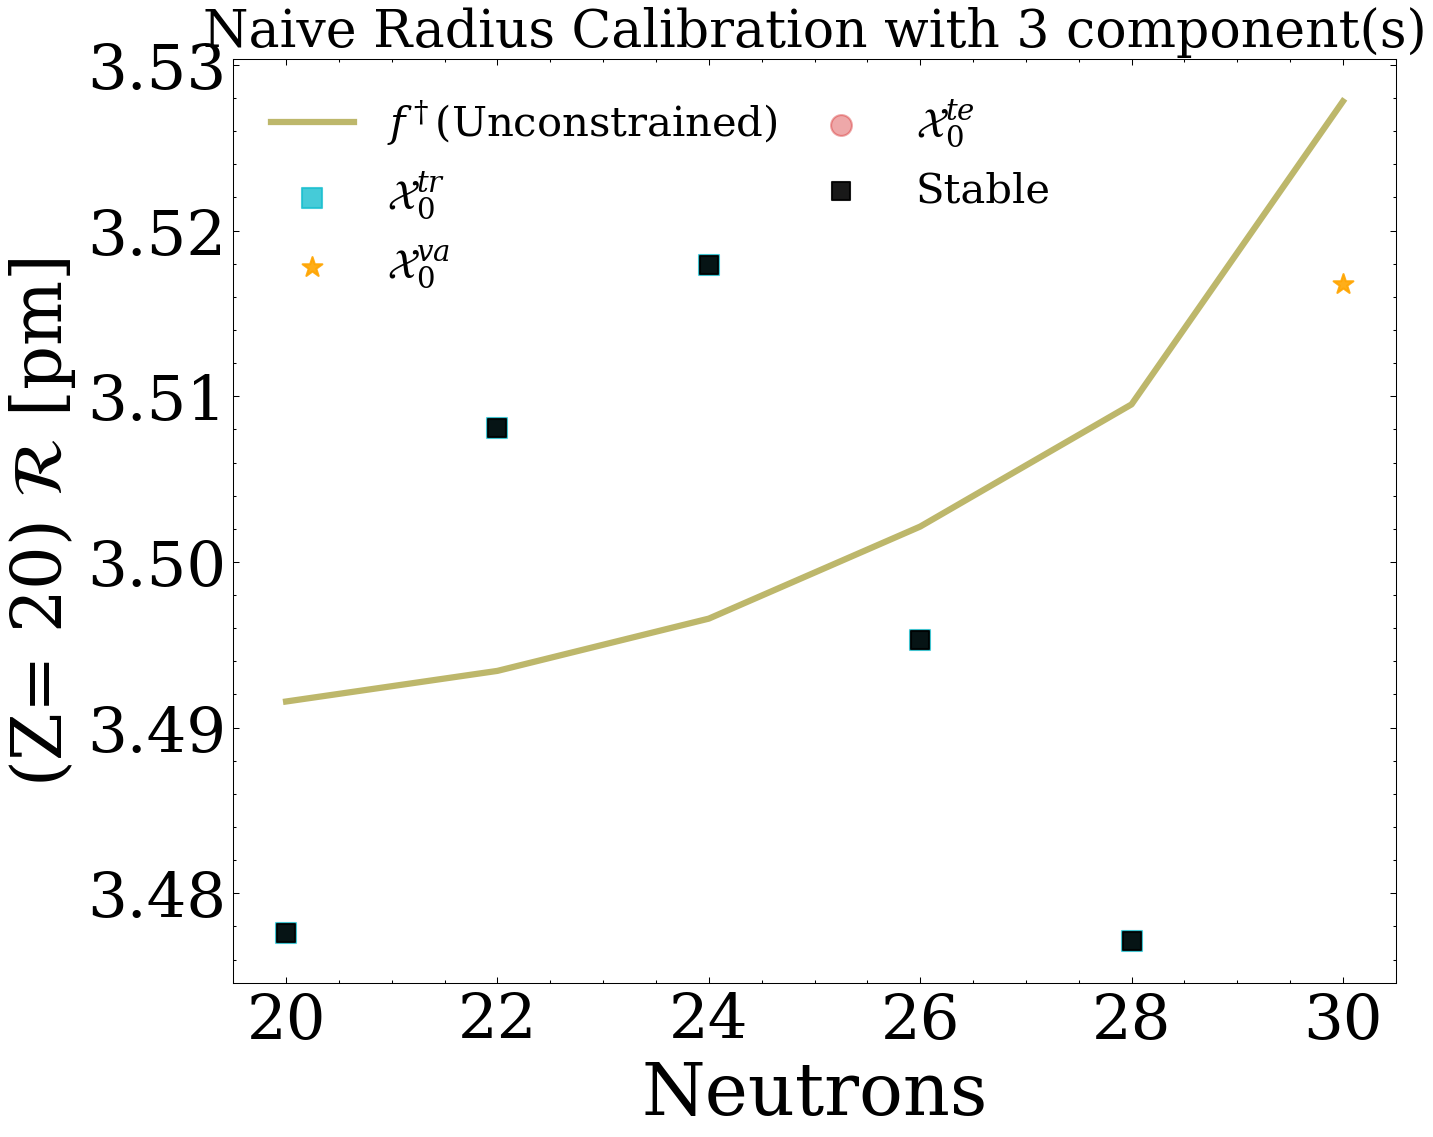

In [84]:
plot_filtered_naive_supermodel(filtered_naive_supermodel_output_radius_list_20, filtered_models_output_radius_list_20, filtered_models_output_radius_stable_20, 20, 'pm', 'R', 'Unconstrained', components_kept )
# plt.savefig(f'Plots/Radii Data with 20, 28, 50, 82/BMM predictions/Ca 20 - Radii Naive BMM with {components_kept} components - locally fitted isospin model included')
plt.show()

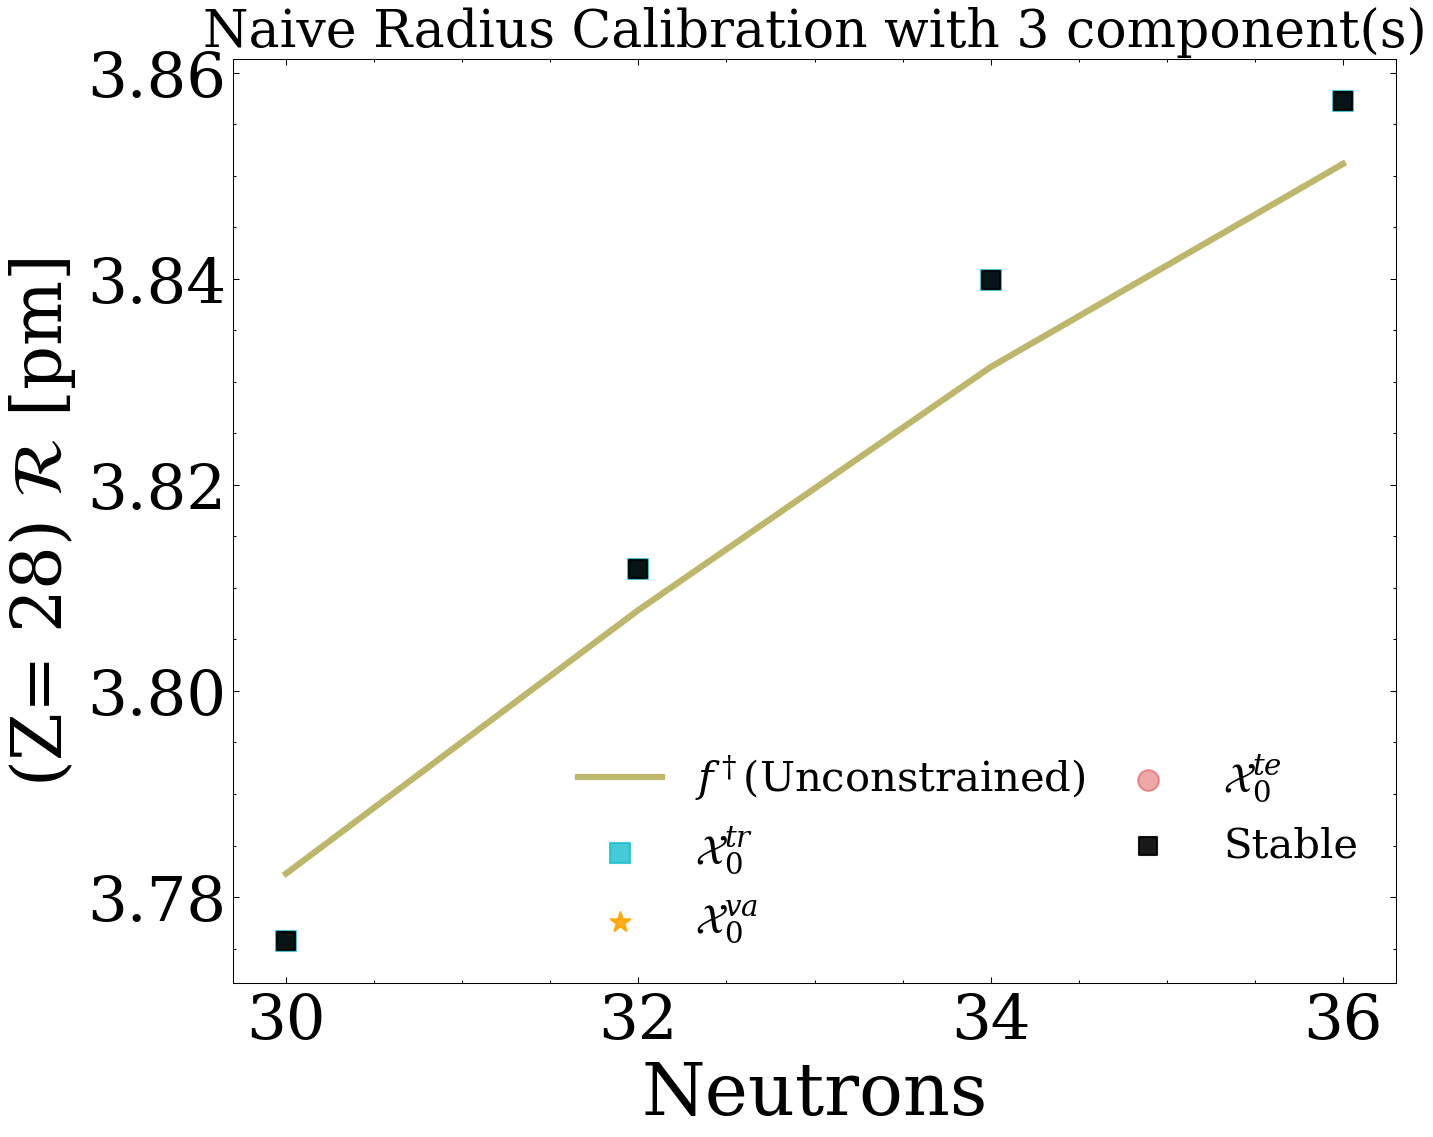

In [85]:
plot_filtered_naive_supermodel(filtered_naive_supermodel_output_radius_list_28, filtered_models_output_radius_list_28, filtered_models_output_radius_stable_28, 28, 'pm', 'R', 'Unconstrained', components_kept )
# plt.savefig(f'Plots/Radii Data with 20, 28, 50, 82/BMM predictions/Ni 28 - Radii Naive BMM with {components_kept} components - locally fitted isospin model included')
plt.show()

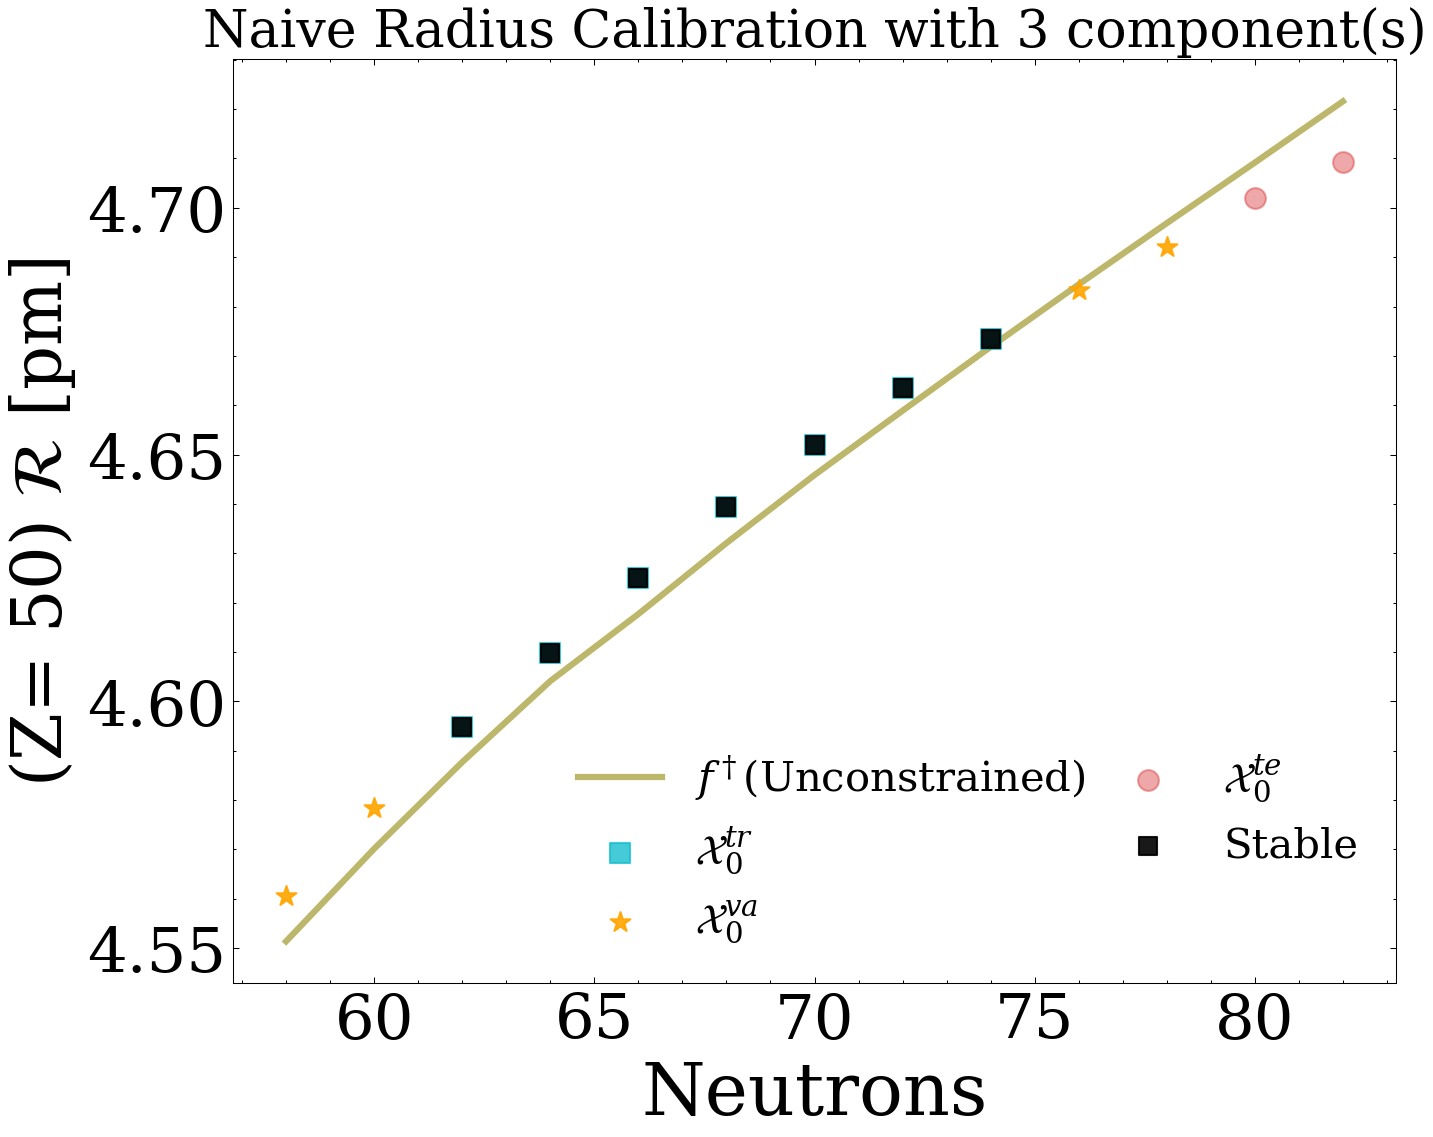

In [86]:
plot_filtered_naive_supermodel(filtered_naive_supermodel_output_radius_list_50, filtered_models_output_radius_list_50, filtered_models_output_radius_stable_50, 50, 'pm', 'R', 'Unconstrained', components_kept )
# plt.savefig(f'Plots/Radii Data with 20, 28, 50, 82/BMM predictions/Sn 50 - Radii Naive BMM with {components_kept} components - locally fitted isospin model included')
plt.show()

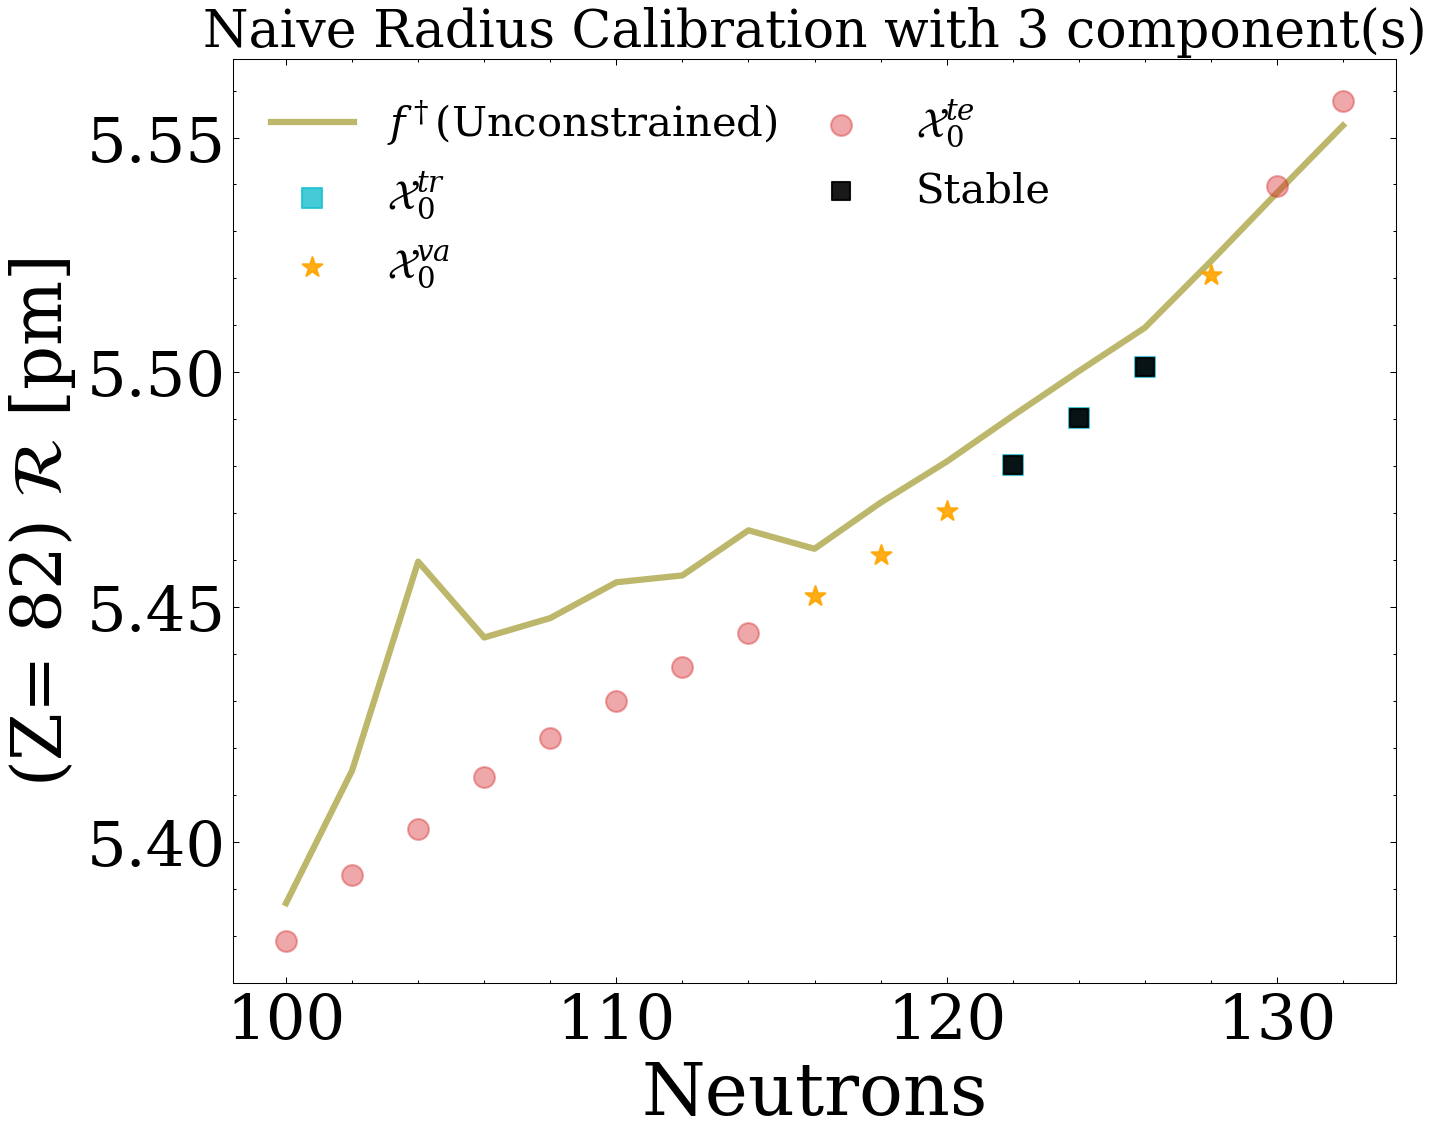

In [87]:
plot_filtered_naive_supermodel(filtered_naive_supermodel_output_radius_list_82, filtered_models_output_radius_list_82, filtered_models_output_radius_stable_82, 82, 'pm', 'R', 'Unconstrained', components_kept )
# plt.savefig(f'Plots/Radii Data with 20, 28, 50, 82/BMM predictions/Pb 82 - Radii Naive BMM with {components_kept} components - locally fitted isospin model included')
plt.show()